# MARCE — GeoTIFF, propagación de incendios y corrección de errores
## Versión 2 corregida para Google Colab

Este notebook corrige los problemas detectados en el piloto:

- orden espectral correcto para GeoTIFF EuroSAT de 13 bandas;
- perfiles de bandas explícitos y validación espectral;
- varias simulaciones independientes, separadas por corrida;
- propagación moderada y diagnóstico de saturación;
- predicción del **nuevo frente**, no del daño acumulado;
- comparación justa de CA, CNN, Transformer y GNN;
- GNN con grafo dirigido según el viento;
- corrección clásica evaluada por separado;
- benchmark real de código de superficie con Stim y MWPM/PyMatching.

> Las redes aprenden a aproximar el autómata celular, no un incendio real. Para validación externa se requieren perímetros observados, meteorología, pendiente y separación espacial/temporal.

In [1]:
# 1. Dependencias y configuración
import os,sys,time,random,warnings,subprocess,importlib.util
from dataclasses import dataclass
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter,convolve,median_filter
from sklearn.metrics import f1_score,jaccard_score,balanced_accuracy_score,precision_score,recall_score

for pkg in ['rasterio','stim','pymatching']:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable,'-m','pip','install','-q',pkg])
import rasterio,stim,pymatching
from rasterio.enums import Resampling
from affine import Affine
import torch,torch.nn as nn,torch.nn.functional as F
from torch.utils.data import DataLoader,TensorDataset

warnings.filterwarnings('ignore'); SEED=42
np.random.seed(SEED);random.seed(SEED);torch.manual_seed(SEED)
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

@dataclass
class CFG:
    grid:int=20
    steps:int=16
    n_runs:int=10
    train_runs:int=7
    epochs:int=20
    batch_size:int=8
    lr:float=2e-3
    wind_angle_deg:float=45.0
    base_spread:float=0.30
    spontaneous:float=0.00005
    error_rate:float=0.08
cfg=CFG()
print('Dispositivo:',DEVICE,'| rasterio:',rasterio.__version__,'| stim:',stim.__version__)
print(cfg)

Dispositivo: cpu | rasterio: 1.5.0 | stim: 1.16.0
CFG(grid=20, steps=16, n_runs=10, train_runs=7, epochs=20, batch_size=8, lr=0.002, wind_angle_deg=45.0, base_spread=0.3, spontaneous=5e-05, error_rate=0.08)


## 1.1 Escala ampliada del experimento — nueva versión

Esta copia aumenta las corridas sin modificar el notebook anterior. La separación sigue realizándose por corridas completas: 14 corridas para entrenamiento y 6 para prueba. Con 16 pasos por corrida se obtienen hasta 96 estados temporales de prueba.


In [2]:
# Escala robusta pero manejable en Google Colab
cfg.n_runs = 20
cfg.train_runs = 14

if not 0 < cfg.train_runs < cfg.n_runs:
    raise ValueError('train_runs debe estar entre 1 y n_runs-1')

print('Configuración ampliada activa')
print('Corridas totales:', cfg.n_runs)
print('Corridas de entrenamiento:', cfg.train_runs)
print('Corridas de prueba:', cfg.n_runs-cfg.train_runs)
print('Estados temporales máximos de prueba:', (cfg.n_runs-cfg.train_runs)*cfg.steps)


Configuración ampliada activa
Corridas totales: 20
Corridas de entrenamiento: 14
Corridas de prueba: 6
Estados temporales máximos de prueba: 96


## 2. Carga del GeoTIFF

El archivo debe contener al menos las bandas azul, verde, roja, NIR, SWIR1 y SWIR2. No se utilizará una escena sintética si la carga falla.

In [4]:
# 2. Cargar GeoTIFF y extraer todas sus bandas
from google.colab import files
uploaded=files.upload()
tifs=[n for n in uploaded if n.lower().endswith(('.tif','.tiff'))]
if not tifs: raise ValueError('Debe cargar un archivo .tif o .tiff.')
geotiff_name=tifs[0]
with rasterio.open(geotiff_name) as src:
    descriptions=list(src.descriptions);crs=src.crs;bounds=src.bounds
    original_shape=(src.height,src.width)
    transform_grid=src.transform*Affine.scale(src.width/cfg.grid,src.height/cfg.grid)
    cube_ma=src.read(out_shape=(src.count,cfg.grid,cfg.grid),resampling=Resampling.bilinear,masked=True).astype('float32')
cube=np.asarray(cube_ma.filled(np.nan),dtype='float32')
if cube.shape[0]<6: raise ValueError(f'Solo se encontraron {cube.shape[0]} bandas.')
rows=[]
for i,z in enumerate(cube):
    v=z[np.isfinite(z)]
    rows.append([i+1,descriptions[i] or '',*([np.nan]*5 if not len(v) else [v.min(),np.percentile(v,2),np.median(v),np.percentile(v,98),v.max()])])
band_table=pd.DataFrame(rows,columns=['banda','descripción','min','p02','mediana','p98','max'])
print('Archivo:',geotiff_name,'| bandas:',cube.shape[0],'| original:',original_shape,'| CRS:',crs)
print('Límites:',bounds);display(band_table)

Saving HerbaceousVegetation_723.tif to HerbaceousVegetation_723.tif
Archivo: HerbaceousVegetation_723.tif | bandas: 13 | original: (64, 64) | CRS: EPSG:32630
Límites: BoundingBox(left=478520.6395624135, bottom=6184931.639408483, right=479160.70143862074, top=6185571.692470759)


,banda,descripción,min,p02,mediana,p98,max
0,1,,1102.0,1119.979980,1159.0,1246.000000,1254.0
1,2,,826.0,841.960022,922.5,1070.200195,1126.0
2,3,,771.0,811.960022,923.0,1116.000000,1150.0
3,4,,484.0,559.979980,763.5,1045.440430,1166.0
4,5,,1047.0,1131.979980,1330.5,1639.040039,1689.0
5,6,,2282.0,2321.879883,2635.0,3511.100098,3670.0
6,7,,2699.0,2770.959961,3132.5,4336.100098,4585.0
7,8,,2742.0,2814.000000,3184.0,4392.080078,4654.0
8,9,,1341.0,1360.900024,1482.0,1946.020020,2004.0
9,10,,13.0,13.000000,16.0,18.000000,19.0


## 3. Perfil espectral

Seleccione el perfil correspondiente. Para archivos EuroSAT de 13 bandas, el orden usual es:

`B01, B02, B03, B04, B05, B06, B07, B08, B09, B10, B11, B12, B8A`.

Por ello, **B11=11, B12=12 y B8A=13**. La versión anterior interpretaba erróneamente la banda 13 como B12.

Perfil: EUROSAT_13 | mapeo: {'blue': 2, 'green': 3, 'red': 4, 'nir': 8, 'swir1': 11, 'swir2': 12, 'nir_narrow': 13}


,variable,media,min,max
0,NDVI,0.623292,0.456157,0.811600
1,NDMI,0.183784,0.063763,0.354630
2,NBR,0.483111,0.334645,0.658616
3,fuel,0.604262,0.000000,0.997097


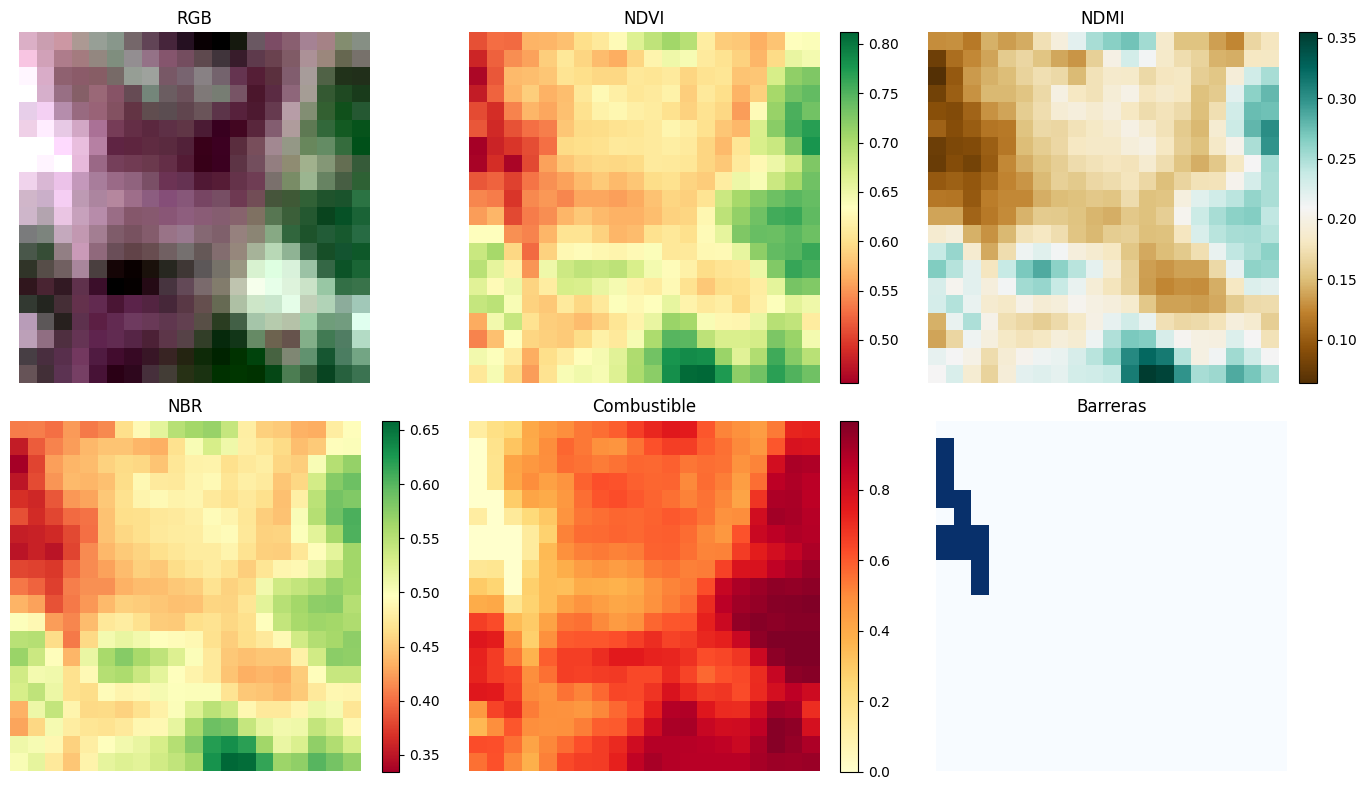

In [5]:
# 3. Selección explícita del perfil
PROFILE='EUROSAT_13'  # alternativas: 'S2_B1_B12_B8A', 'CUSTOM'
PROFILES={
 'EUROSAT_13':{'blue':2,'green':3,'red':4,'nir':8,'swir1':11,'swir2':12,'nir_narrow':13},
 'S2_B1_B12_B8A':{'blue':2,'green':3,'red':4,'nir':8,'swir1':11,'swir2':12,'nir_narrow':13},
 'CUSTOM':{'blue':2,'green':3,'red':4,'nir':8,'swir1':11,'swir2':12,'nir_narrow':13},
}
BAND_MAP=PROFILES[PROFILE].copy()
bad={k:v for k,v in BAND_MAP.items() if v<1 or v>cube.shape[0]}
if bad: raise ValueError(f'Bandas fuera de rango: {bad}. Edite el perfil CUSTOM.')
print('Perfil:',PROFILE,'| mapeo:',BAND_MAP)

def b(name): return cube[BAND_MAP[name]-1]
def idx(a,b):
    den=a+b;return np.divide(a-b,den,out=np.full_like(a,np.nan),where=np.isfinite(den)&(abs(den)>1e-8))
def norm01(a,valid=None):
    valid=np.isfinite(a) if valid is None else valid&np.isfinite(a);v=a[valid]
    if not len(v): raise ValueError('Variable sin datos válidos.')
    lo,hi=np.percentile(v,[2,98]);return np.where(valid,np.clip((a-lo)/(hi-lo+1e-8),0,1),0).astype('float32')

blue,green,red,nir,swir1,swir2=[b(x) for x in ['blue','green','red','nir','swir1','swir2']]
valid=np.all(np.isfinite(np.stack([blue,green,red,nir,swir1,swir2])),axis=0)
ndvi=idx(nir,red);ndmi=idx(nir,swir1);nbr=idx(nir,swir2);ndwi=idx(green,nir)
vegetation=norm01(ndvi,valid);dryness=1-norm01(ndmi,valid)
fuel=gaussian_filter(norm01(vegetation*(0.50+0.50*dryness),valid),.5)
barrier=(~valid)|(ndwi>0.15)|(fuel<0.10);fuel[barrier]=0
rgb=np.dstack([norm01(red,valid),norm01(green,valid),norm01(blue,valid)])

stats=pd.DataFrame({'variable':['NDVI','NDMI','NBR','fuel'],'media':[np.nanmean(ndvi[valid]),np.nanmean(ndmi[valid]),np.nanmean(nbr[valid]),np.mean(fuel[valid])],
 'min':[np.nanmin(ndvi[valid]),np.nanmin(ndmi[valid]),np.nanmin(nbr[valid]),np.min(fuel[valid])],
 'max':[np.nanmax(ndvi[valid]),np.nanmax(ndmi[valid]),np.nanmax(nbr[valid]),np.max(fuel[valid])]})
display(stats)
fig,ax=plt.subplots(2,3,figsize=(14,8))
for a,z,t,c in zip(ax.ravel(),[rgb,ndvi,ndmi,nbr,fuel,barrier],['RGB','NDVI','NDMI','NBR','Combustible','Barreras'],[None,'RdYlGn','BrBG','RdYlGn','YlOrRd','Blues']):
    im=a.imshow(z,cmap=c);a.set_title(t);a.axis('off')
    if z.ndim==2 and t!='Barreras':plt.colorbar(im,ax=a,fraction=.046)
plt.tight_layout();plt.show()
if valid.mean()<.2 or np.sum(~barrier)<30: raise ValueError('Cobertura válida/combustible insuficiente; revise BAND_MAP.')
if np.nanmean(nbr[valid])<-.2: print('ADVERTENCIA: NBR muy negativo; confirme el orden de SWIR2.')

## 4. Autómata celular y múltiples corridas

Cada corrida cambia semilla, ignición e intensidad del viento. El objetivo de aprendizaje será únicamente el conjunto de celdas que se encienden en el paso siguiente.

,run,split,wind_strength,ignition,final_burn_fraction
0,0,train,0.237776,"(3, 18)",0.2875
1,1,train,0.171498,"(0, 12)",0.2050
2,2,train,0.324336,"(16, 17)",0.2875
3,3,train,0.244422,"(17, 13)",0.2450
4,4,train,0.308591,"(13, 19)",0.2625
5,5,train,0.329151,"(19, 13)",0.0800
6,6,train,0.256676,"(8, 19)",0.0600
7,7,train,0.324960,"(13, 0)",0.0600
8,8,train,0.349394,"(12, 12)",0.2175
9,9,train,0.257768,"(19, 8)",0.1025


Cobertura mediana: 19.5%


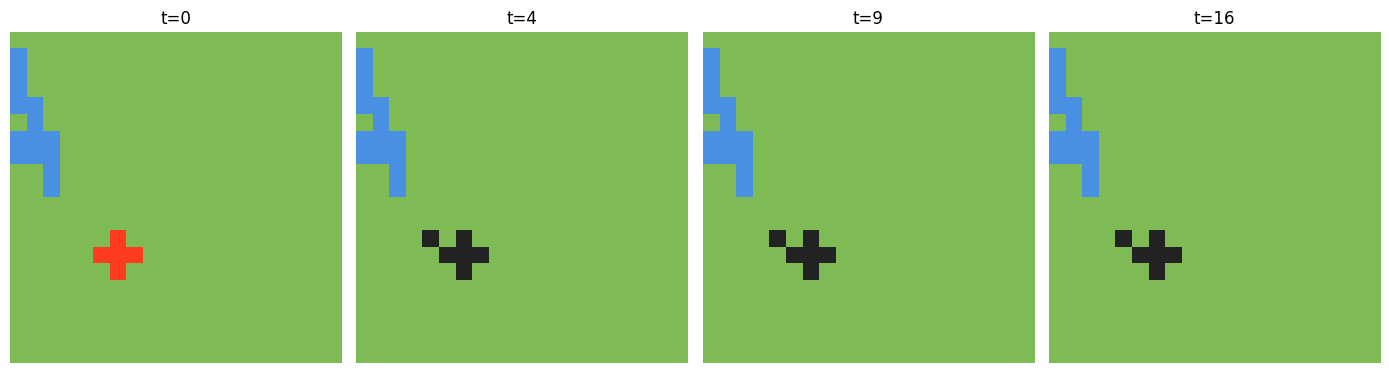

In [6]:
# 4. CA con viento explícito
OFFSETS=[(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]
K8=np.ones((3,3),dtype='float32');K8[1,1]=0
def ca_step(state,rng,wind_strength,spread):
    influence=np.zeros_like(fuel);th=np.deg2rad(cfg.wind_angle_deg);wind=np.array([np.sin(th),np.cos(th)])
    for di,dj in OFFSETS:
        src=np.roll(np.roll(state==1,-di,0),-dj,1)
        direction=np.array([di,dj],float);direction/=np.linalg.norm(direction)
        influence+=src*(1+wind_strength*max(0,float(direction@wind)))
    p=1-np.exp(-spread*fuel*influence)
    ignite=(state==0)&(rng.random(state.shape)<p)
    nxt=state.copy();nxt[state==1]=2;nxt[ignite]=1;nxt[barrier]=3
    return nxt

def simulate(run):
    rng=np.random.default_rng(SEED+100*run);state=np.zeros_like(fuel,dtype='int8');state[barrier]=3
    candidates=np.argwhere((fuel>np.quantile(fuel[~barrier],.60))&(~barrier))
    i,j=candidates[rng.integers(len(candidates))]
    for di,dj in [(0,0),(-1,0),(1,0),(0,-1),(0,1)]:
        ii,jj=i+di,j+dj
        if 0<=ii<cfg.grid and 0<=jj<cfg.grid and not barrier[ii,jj]:state[ii,jj]=1
    ws=float(rng.uniform(.15,.35));spread=float(rng.uniform(cfg.base_spread*.85,cfg.base_spread*1.15))
    seq=[state.copy()]
    for _ in range(cfg.steps):seq.append(ca_step(seq[-1],rng,ws,spread))
    return np.stack(seq),ws,(int(i),int(j))

runs=[simulate(r) for r in range(cfg.n_runs)]
coverage=[np.mean(np.isin(s[-1],[1,2])) for s,_,_ in runs]
run_summary=pd.DataFrame({'run':range(cfg.n_runs),'split':['train' if r<cfg.train_runs else 'test' for r in range(cfg.n_runs)],
 'wind_strength':[x[1] for x in runs],'ignition':[x[2] for x in runs],'final_burn_fraction':coverage})
display(run_summary);print('Cobertura mediana:',f'{np.median(coverage):.1%}')
if np.median(coverage)>.65:print('ADVERTENCIA: propagación saturada; reduzca base_spread o steps.')
if np.median(coverage)<.08:print('ADVERTENCIA: propagación escasa; aumente base_spread.')

cmap=plt.matplotlib.colors.ListedColormap(['#7fbb55','#ff3b20','#222222','#4a90e2'])
seq=runs[-1][0];fig,ax=plt.subplots(1,4,figsize=(14,4))
for a,t in zip(ax,[0,4,9,cfg.steps]):a.imshow(seq[t],cmap=cmap,vmin=0,vmax=3);a.set_title(f't={t}');a.axis('off')
plt.tight_layout();plt.show()

## 5. Dataset sin fuga entre corridas

Las primeras corridas forman entrenamiento y las restantes, prueba. Los canales incluyen combustible, índices espectrales, estados y viento. La etiqueta es el nuevo frente (F_{t+1}\setminus F_t).

In [7]:
# 5. Construir dataset por corrida
def features(s,ws):
    burning=(s==1).astype('float32');burned=(s==2).astype('float32');neigh=convolve(burning,K8,mode='constant')/8
    return np.stack([fuel,dryness,vegetation,burning,burned,neigh,np.full_like(fuel,ws),np.full_like(fuel,cfg.wind_angle_deg/360)]).astype('float32')
Xtr=[];Ytr=[];Xte=[];Yte=[];Cte=[]
for r,(seq,ws,_) in enumerate(runs):
    for t in range(cfg.steps):
        x=features(seq[t],ws);y=(seq[t+1]==1).astype('float32')
        if r<cfg.train_runs:Xtr.append(x);Ytr.append(y)
        else:Xte.append(x);Yte.append(y);Cte.append(np.isin(seq[t+1],[1,2]).astype('uint8'))
Xtr=np.stack(Xtr);Ytr=np.stack(Ytr);Xte=np.stack(Xte);Yte=np.stack(Yte);Cte=np.stack(Cte)
print('Train:',Xtr.shape,Ytr.shape,'| Test:',Xte.shape,Yte.shape)
print('Positivos frente train/test:',f'{Ytr.mean():.2%}',f'{Yte.mean():.2%}')
train_ds=TensorDataset(torch.tensor(Xtr),torch.tensor(Ytr[:,None]));train_loader=DataLoader(train_ds,batch_size=cfg.batch_size,shuffle=True)
Xte_t=torch.tensor(Xte,device=DEVICE)

Train: (224, 8, 20, 20) (224, 20, 20) | Test: (96, 8, 20, 20) (96, 20, 20)
Positivos frente train/test: 0.99% 0.83%


## 6. Modelos: CNN, Transformer y GNN dirigida

CNN 2.7 s
Transformer 81.73 s
GNN dirigida 2.71 s


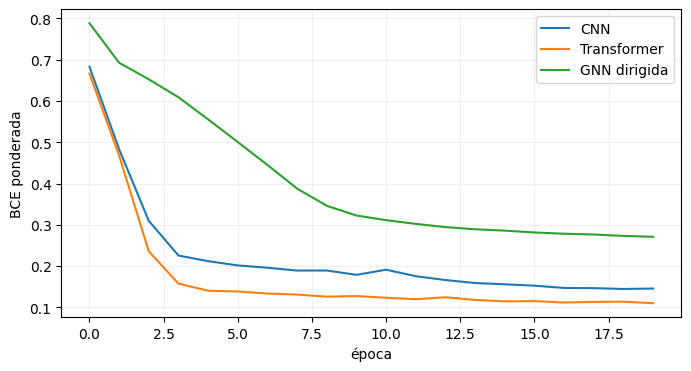

In [8]:
# 6. Arquitecturas
class FireCNN(nn.Module):
    def __init__(self):
        super().__init__();self.net=nn.Sequential(nn.Conv2d(8,24,3,padding=1),nn.ReLU(),nn.Conv2d(24,24,3,padding=1),nn.ReLU(),nn.Conv2d(24,1,1))
    def forward(self,x):return self.net(x)

class FireTransformer(nn.Module):
    def __init__(self,n=cfg.grid,d=24):
        super().__init__();self.n=n;self.proj=nn.Linear(8,d);self.pos=nn.Parameter(torch.randn(1,n*n,d)*.02)
        self.enc=nn.TransformerEncoder(nn.TransformerEncoderLayer(d,4,48,batch_first=True,dropout=.05),1);self.out=nn.Linear(d,1)
    def forward(self,x):
        b,c,h,w=x.shape;z=x.permute(0,2,3,1).reshape(b,h*w,c);z=self.enc(self.proj(z)+self.pos[:,:h*w])
        return self.out(z).reshape(b,1,h,w)

def directed_adjacency(n,angle):
    A=np.eye(n*n,dtype='float32');th=np.deg2rad(angle);wind=np.array([np.sin(th),np.cos(th)])
    for i in range(n):
      for j in range(n):
       u=i*n+j
       for di,dj in OFFSETS:
        ii,jj=i+di,j+dj
        if 0<=ii<n and 0<=jj<n:
         d=np.array([di,dj],float);d/=np.linalg.norm(d);A[u,ii*n+jj]=.35+max(0,float(d@wind))
    A=A/(A.sum(1,keepdims=True)+1e-8);return torch.tensor(A,device=DEVICE)
A=directed_adjacency(cfg.grid,cfg.wind_angle_deg)
class FireGNN(nn.Module):
    def __init__(self):super().__init__();self.l1=nn.Linear(8,32);self.l2=nn.Linear(32,24);self.l3=nn.Linear(24,1)
    def forward(self,x):
        b,c,h,w=x.shape;z=x.permute(0,2,3,1).reshape(b,h*w,c)
        z=F.relu(self.l1(torch.matmul(A,z)));z=F.relu(self.l2(torch.matmul(A,z)))
        return self.l3(z).reshape(b,1,h,w)

def train(model):
    model=model.to(DEVICE);opt=torch.optim.AdamW(model.parameters(),lr=cfg.lr,weight_decay=1e-4)
    pos=max(1,float((Ytr.size-Ytr.sum())/(Ytr.sum()+1e-8)));loss_fn=nn.BCEWithLogitsLoss(pos_weight=torch.tensor([min(pos,30)],device=DEVICE))
    hist=[];t0=time.perf_counter()
    for ep in range(cfg.epochs):
        model.train();total=0
        for xb,yb in train_loader:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE);opt.zero_grad();loss=loss_fn(model(xb),yb);loss.backward();opt.step();total+=loss.item()*len(xb)
        hist.append(total/len(train_ds))
    return model,hist,time.perf_counter()-t0

models={};histories={};train_times={}
for name,model in [('CNN',FireCNN()),('Transformer',FireTransformer()),('GNN dirigida',FireGNN())]:
    models[name],histories[name],train_times[name]=train(model);print(name,round(train_times[name],2),'s')
plt.figure(figsize=(8,4))
for n,h in histories.items():plt.plot(h,label=n)
plt.xlabel('época');plt.ylabel('BCE ponderada');plt.legend();plt.grid(alpha=.2);plt.show()

## 7. Umbral elegido únicamente con entrenamiento

Se evita fijar 0,5 arbitrariamente. Cada modelo selecciona el umbral que maximiza F1 en entrenamiento; luego ese umbral se aplica sin cambios a prueba.

,Modelo,Umbral,F1,IoU,Balanced_accuracy,Precision,Recall,Entrenamiento_s,Inferencia_s
0,Transformer,0.900,0.429,0.273,0.851,0.307,0.715,81.727239,0.415271
1,CNN,0.875,0.411,0.259,0.920,0.270,0.859,2.695564,0.014126
2,GNN dirigida,0.800,0.304,0.179,0.785,0.205,0.589,2.706485,0.043554
3,Regla CA,0.225,0.302,0.178,0.851,0.191,0.727,0.000000,nan


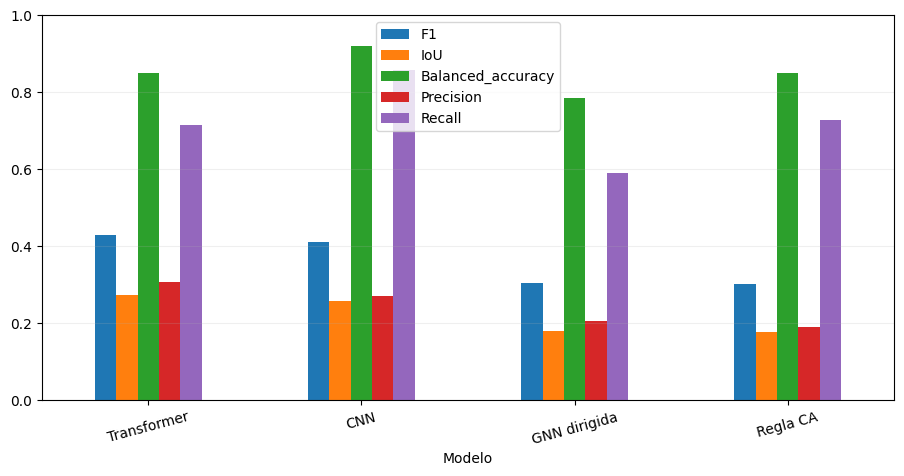

In [9]:
# 7. Calibrar umbrales y evaluar nuevo frente
def probabilities(model,x,batch=16):
    model.eval();out=[];t0=time.perf_counter()
    with torch.no_grad():
        for i in range(0,len(x),batch):out.append(torch.sigmoid(model(torch.tensor(x[i:i+batch],device=DEVICE))).cpu().numpy()[:,0])
    return np.concatenate(out),time.perf_counter()-t0

def best_threshold(y,p):
    candidates=np.linspace(.10,.90,33);scores=[f1_score(y.ravel(),(p.ravel()>=t),zero_division=0) for t in candidates]
    return float(candidates[int(np.argmax(scores))])
def met(y,p):
    y=y.ravel();p=p.ravel();return {'F1':f1_score(y,p,zero_division=0),'IoU':jaccard_score(y,p,zero_division=0),
      'Balanced_accuracy':balanced_accuracy_score(y,p),'Precision':precision_score(y,p,zero_division=0),'Recall':recall_score(y,p,zero_division=0)}

def ca_probability(x):
    # Baseline mecanístico: probabilidad usada por la regla CA, sin observar t+1
    out=[];th=np.deg2rad(cfg.wind_angle_deg);wind=np.array([np.sin(th),np.cos(th)])
    for sample in x:
        burning=sample[3]>0.5;ws=float(sample[6,0,0]);influence=np.zeros_like(fuel)
        for di,dj in OFFSETS:
            src=np.roll(np.roll(burning,-di,0),-dj,1);d=np.array([di,dj],float);d/=np.linalg.norm(d)
            influence+=src*(1+ws*max(0,float(d@wind)))
        out.append(1-np.exp(-cfg.base_spread*fuel*influence))
    return np.stack(out)

rows=[];preds={}
# La regla CA es una referencia mecanística, no una red aprendida
pca_tr=ca_probability(Xtr);pca_te=ca_probability(Xte);tca=best_threshold(Ytr,pca_tr);pred_ca=(pca_te>=tca).astype('uint8')
preds['Regla CA']=pred_ca
rows.append({'Modelo':'Regla CA','Umbral':tca,**met(Yte,pred_ca),'Entrenamiento_s':0.0,'Inferencia_s':np.nan})
for name,m in models.items():
    ptr,_=probabilities(m,Xtr);threshold=best_threshold(Ytr,ptr);pte,sec=probabilities(m,Xte)
    pred=(pte>=threshold).astype('uint8');preds[name]=pred
    rows.append({'Modelo':name,'Umbral':threshold,**met(Yte,pred),'Entrenamiento_s':train_times[name],'Inferencia_s':sec})
model_results=pd.DataFrame(rows).sort_values('F1',ascending=False).reset_index(drop=True)
display(model_results.style.format({c:'{:.3f}' for c in ['Umbral','F1','IoU','Balanced_accuracy','Precision','Recall']}))
model_results.set_index('Modelo')[['F1','IoU','Balanced_accuracy','Precision','Recall']].plot(kind='bar',figsize=(11,5),ylim=(0,1),rot=15);plt.grid(axis='y',alpha=.2);plt.show()

## 8. Inspección visual del nuevo frente

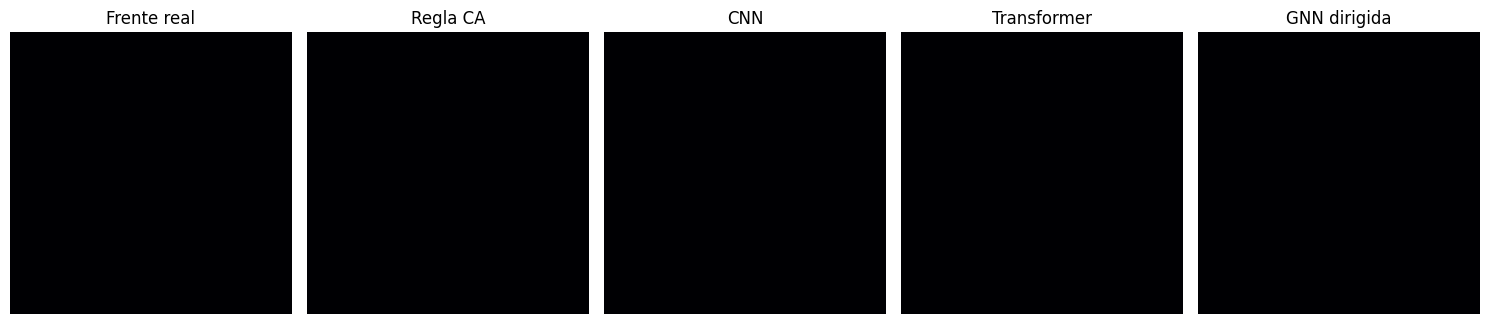

In [10]:
# 8. Último ejemplo de prueba
k=-1;items=[('Frente real',Yte[k])]+[(n,p[k]) for n,p in preds.items()]
fig,ax=plt.subplots(1,len(items),figsize=(15,4))
for a,(t,z) in zip(ax,items):a.imshow(z,cmap='inferno',vmin=0,vmax=1);a.set_title(t);a.axis('off')
plt.tight_layout();plt.show()

## 9. Corrección clásica de errores en grillas — experimento separado

Se corrompen tres réplicas de las máscaras acumuladas de prueba. La mayoría decodifica el código de repetición y una limpieza local elimina artefactos aislados. Esta tabla no se mezcla con la comparación predictiva.

In [11]:
# 9. Robustez clásica en todas las grillas test
rng=np.random.default_rng(SEED+999)
obs=np.stack([Cte^(rng.random(Cte.shape)<cfg.error_rate) for _ in range(3)])
decoded=(obs.sum(0)>=2).astype('uint8')
corrected=np.stack([median_filter(z,size=3,mode='nearest') for z in decoded])
# conservar mayoría cuando el filtro cambiaría zonas con soporte local moderado
support=np.stack([convolve(z.astype(float),K8,mode='constant') for z in decoded])
corrected=np.where(((decoded==1)&(support>=2))|((decoded==0)&(support<=6)),decoded,corrected).astype('uint8')
corr_results=pd.DataFrame([
 {'Tratamiento':'Una réplica ruidosa',**met(Cte,obs[0])},
 {'Tratamiento':'Mayoría 3 réplicas',**met(Cte,decoded)},
 {'Tratamiento':'Mayoría + topología local',**met(Cte,corrected)}])
display(corr_results.style.format({c:'{:.3f}' for c in corr_results.columns if c!='Tratamiento'}))

,Tratamiento,F1,IoU,Balanced_accuracy,Precision,Recall
0,Una réplica ruidosa,0.692,0.529,0.919,0.555,0.917
1,Mayoría 3 réplicas,0.909,0.833,0.982,0.845,0.983
2,Mayoría + topología local,0.941,0.888,0.962,0.954,0.928


## 10. Código de superficie real con MWPM

Este benchmark es independiente del incendio. Stim genera circuitos de memoria de código de superficie rotado; PyMatching decodifica los síndromes mediante MWPM. Se compara la tasa de error lógico (LER) para distancias 3 y 5.

,distance,p_físico,LER_MWPM,IC95_inf,IC95_sup,qubits_circuito,detectores
0,3,0.100%,0.050%,0.000%,0.148%,26,24
1,3,0.300%,0.600%,0.262%,0.938%,26,24
2,3,0.600%,2.550%,1.859%,3.241%,26,24
3,3,1.000%,7.150%,6.021%,8.279%,26,24
4,5,0.100%,0.100%,0.000%,0.239%,64,120
5,5,0.300%,0.550%,0.226%,0.874%,64,120
6,5,0.600%,2.100%,1.472%,2.728%,64,120
7,5,1.000%,9.800%,8.497%,11.103%,64,120


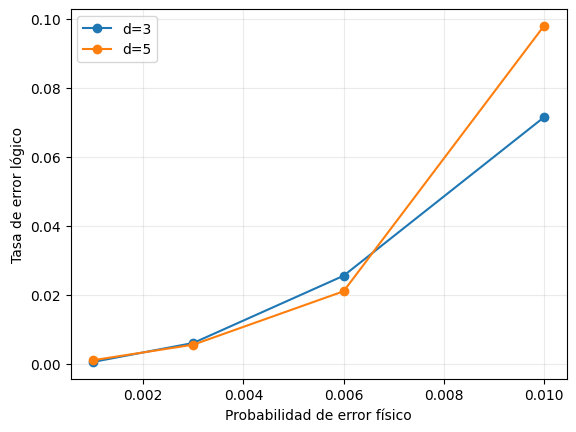

In [12]:
# 10. Benchmark QEC real: surface code + MWPM
def surface_trial(distance,p,shots=2000):
    circuit=stim.Circuit.generated('surface_code:rotated_memory_x',distance=distance,rounds=distance,
        after_clifford_depolarization=p,before_measure_flip_probability=p,
        after_reset_flip_probability=p,before_round_data_depolarization=p)
    sampler=circuit.compile_detector_sampler(seed=SEED+distance+int(p*1e6))
    dets,obs=sampler.sample(shots,separate_observables=True)
    dem=circuit.detector_error_model(decompose_errors=True)
    matching=pymatching.Matching.from_detector_error_model(dem)
    pred=matching.decode_batch(dets)
    failures=np.any(pred!=obs,axis=1)
    ler=float(failures.mean());se=float(np.sqrt(ler*(1-ler)/shots))
    return ler,se,circuit.num_qubits,circuit.num_detectors

qec=[]
for d in [3,5]:
 for p in [0.001,0.003,0.006,0.010]:
    ler,se,nq,nd=surface_trial(d,p)
    qec.append({'distance':d,'p_físico':p,'LER_MWPM':ler,'IC95_inf':max(0,ler-1.96*se),'IC95_sup':min(1,ler+1.96*se),'qubits_circuito':nq,'detectores':nd})
qec_results=pd.DataFrame(qec);display(qec_results.style.format({'p_físico':'{:.3%}','LER_MWPM':'{:.3%}','IC95_inf':'{:.3%}','IC95_sup':'{:.3%}'}))
for d,g in qec_results.groupby('distance'):plt.plot(g['p_físico'],g['LER_MWPM'],'o-',label=f'd={d}')
plt.xlabel('Probabilidad de error físico');plt.ylabel('Tasa de error lógico');plt.legend();plt.grid(alpha=.25);plt.show()

## 11. Integración real: predicción del incendio → canal ruidoso → código de superficie → MWPM

Esta sección conecta las dos ramas del experimento. Las probabilidades producidas por CNN, GNN y Transformer se cuantizan como palabras binarias. Esas palabras se transmiten en tres condiciones comparables:

1. **Ideal:** probabilidades originales, sin ruido.
2. **Ruido sin QEC:** cada bit se transmite físicamente y puede invertirse con probabilidad `P_FISICO`.
3. **Código de superficie + MWPM:** cada bit se trata como información lógica protegida por un código de superficie rotado. Stim genera síndromes y PyMatching los decodifica. Los fallos lógicos observados se aplican al flujo binario de probabilidades.

El código de superficie no mejora el modelo de propagación. Su función es **preservar la salida del modelo durante almacenamiento o transmisión cuántica simulada**. Por ello se compara cuánto se alejan las métricas ruidosas de la condición ideal.


In [13]:
# 11.1 Configuración del puente incendio–QEC
from sklearn.metrics import roc_auc_score

Q_BITS = 4                 # resolución: 16 niveles de probabilidad
P_FISICO = 0.006           # probabilidad física por bit (editable)
DISTANCIAS_QEC = [3, 5]
SHOTS_QEC = 20_000         # fallos lógicos muestreados por configuración
ROUNDS_FACTOR = 1          # rounds = distancia × factor
SEED_INTEGRACION = SEED + 2026

def quantize_probabilities(p, bits=Q_BITS):
    levels = 2**bits - 1
    q = np.rint(np.clip(p, 0, 1) * levels).astype(np.uint8)
    shifts = np.arange(bits - 1, -1, -1, dtype=np.uint8)
    return ((q[..., None] >> shifts) & 1).astype(np.uint8)

def dequantize_bits(bits):
    nbits = bits.shape[-1]
    weights = (2 ** np.arange(nbits - 1, -1, -1)).astype(np.uint8)
    q = np.sum(bits * weights, axis=-1)
    return q.astype(np.float32) / float(2**nbits - 1)

def surface_code_failure_stream(distance, p, shots, seed):
    circuit = stim.Circuit.generated(
        'surface_code:rotated_memory_x',
        distance=distance,
        rounds=distance * ROUNDS_FACTOR,
        after_clifford_depolarization=p,
        before_round_data_depolarization=p,
        before_measure_flip_probability=p,
        after_reset_flip_probability=p,
    )
    dem = circuit.detector_error_model(decompose_errors=True)
    matching = pymatching.Matching.from_detector_error_model(dem)
    sampler = circuit.compile_detector_sampler(seed=seed)
    dets, obs = sampler.sample(shots=shots, separate_observables=True)
    predicted = matching.decode_batch(dets)
    failures = np.any(predicted != obs, axis=1).astype(np.uint8)
    return failures, circuit

def repeat_to_length(values, n, rng):
    if len(values) == 0:
        return np.zeros(n, dtype=np.uint8)
    out = np.resize(rng.permutation(values), n)
    rng.shuffle(out)
    return out.astype(np.uint8)

print(f'Cuantización: {Q_BITS} bits | p físico: {P_FISICO:.3%} | shots QEC: {SHOTS_QEC:,}')


Cuantización: 4 bits | p físico: 0.600% | shots QEC: 20,000


In [14]:
# 11.2 Obtener las probabilidades de prueba de cada modelo una sola vez
model_probabilities = {}
model_thresholds = {}

for nombre, modelo in models.items():
    p_train, _ = probabilities(modelo, Xtr)
    p_test, _ = probabilities(modelo, Xte)
    model_probabilities[nombre] = p_test.astype(np.float32)
    model_thresholds[nombre] = best_threshold(Ytr, p_train)

display(pd.DataFrame({
    'Modelo': list(model_probabilities),
    'Umbral_entrenamiento': [model_thresholds[m] for m in model_probabilities],
    'Probabilidad_media_test': [model_probabilities[m].mean() for m in model_probabilities],
}).style.format({'Umbral_entrenamiento':'{:.3f}', 'Probabilidad_media_test':'{:.4f}'}))


,Modelo,Umbral_entrenamiento,Probabilidad_media_test
0,CNN,0.875,0.0551
1,Transformer,0.900,0.0331
2,GNN dirigida,0.800,0.0701


In [15]:
# 11.3 Ejecutar el código de superficie real y construir los canales comparables
rng_bridge = np.random.default_rng(SEED_INTEGRACION)
qec_streams = {}
qec_rows = []

for distance in DISTANCIAS_QEC:
    failures, circuit = surface_code_failure_stream(
        distance, P_FISICO, SHOTS_QEC, SEED_INTEGRACION + distance
    )
    qec_streams[distance] = failures
    n_fail = int(failures.sum())
    ler = float(failures.mean())
    se = np.sqrt(max(ler * (1 - ler), 1e-12) / len(failures))
    qec_rows.append({
        'Distancia': distance,
        'p_físico': P_FISICO,
        'Shots': len(failures),
        'Fallos_lógicos': n_fail,
        'LER_MWPM': ler,
        'IC95_inf': max(0, ler - 1.96 * se),
        'IC95_sup': min(1, ler + 1.96 * se),
        'Qubits_circuito': circuit.num_qubits,
        'Detectores': circuit.num_detectors,
    })

qec_bridge_summary = pd.DataFrame(qec_rows)
display(qec_bridge_summary.style.format({
    'p_físico':'{:.3%}', 'LER_MWPM':'{:.3%}',
    'IC95_inf':'{:.3%}', 'IC95_sup':'{:.3%}'
}))


,Distancia,p_físico,Shots,Fallos_lógicos,LER_MWPM,IC95_inf,IC95_sup,Qubits_circuito,Detectores
0,3,0.600%,20000,522,2.610%,2.389%,2.831%,26,24
1,5,0.600%,20000,566,2.830%,2.600%,3.060%,64,120


In [16]:
# 11.4 Transmitir las probabilidades y reconstruir las máscaras de incendio
def safe_auc(y, score):
    y = np.asarray(y).ravel(); score = np.asarray(score).ravel()
    return roc_auc_score(y, score) if np.unique(y).size == 2 else np.nan

def evaluate_probability_map(y, p, threshold):
    binary = (p >= threshold).astype(np.uint8)
    return {**met(y, binary), 'AUC': safe_auc(y, p)}

integration_rows = []
reconstructed = {}

for model_name, p_ideal in model_probabilities.items():
    threshold = model_thresholds[model_name]
    bits = quantize_probabilities(p_ideal)
    flat = bits.reshape(-1)

    # Condición ideal cuantizada: controla la pequeña pérdida debida a Q_BITS.
    p_quant = dequantize_bits(bits)
    reconstructed[(model_name, 'Ideal cuantizada')] = p_quant
    integration_rows.append({
        'Modelo': model_name, 'Canal': 'Ideal cuantizada',
        'Tasa_error_bits': 0.0, **evaluate_probability_map(Yte, p_quant, threshold)
    })

    # Mismo p físico, sin codificación ni decodificación.
    raw_flips = (rng_bridge.random(flat.size) < P_FISICO).astype(np.uint8)
    p_raw = dequantize_bits((flat ^ raw_flips).reshape(bits.shape))
    reconstructed[(model_name, 'Ruido sin QEC')] = p_raw
    integration_rows.append({
        'Modelo': model_name, 'Canal': 'Ruido sin QEC',
        'Tasa_error_bits': float(raw_flips.mean()),
        **evaluate_probability_map(Yte, p_raw, threshold)
    })

    # El flujo de fallos proviene de circuitos de código de superficie
    # realmente muestreados y decodificados mediante MWPM.
    for distance in DISTANCIAS_QEC:
        logical_flips = repeat_to_length(qec_streams[distance], flat.size, rng_bridge)
        p_qec = dequantize_bits((flat ^ logical_flips).reshape(bits.shape))
        channel = f'Surface d={distance} + MWPM'
        reconstructed[(model_name, channel)] = p_qec
        integration_rows.append({
            'Modelo': model_name, 'Canal': channel,
            'Tasa_error_bits': float(logical_flips.mean()),
            **evaluate_probability_map(Yte, p_qec, threshold)
        })

integrated_results = pd.DataFrame(integration_rows)
channel_order = ['Ideal cuantizada', 'Ruido sin QEC'] + [f'Surface d={d} + MWPM' for d in DISTANCIAS_QEC]
integrated_results['Canal'] = pd.Categorical(integrated_results['Canal'], channel_order, ordered=True)
integrated_results = integrated_results.sort_values(['Modelo','Canal']).reset_index(drop=True)

display(integrated_results.style.format({
    'Tasa_error_bits':'{:.3%}', 'F1':'{:.3f}', 'IoU':'{:.3f}',
    'Balanced_accuracy':'{:.3f}', 'Precision':'{:.3f}', 'Recall':'{:.3f}', 'AUC':'{:.3f}'
}))


,Modelo,Canal,Tasa_error_bits,F1,IoU,Balanced_accuracy,Precision,Recall,AUC
0,CNN,Ideal cuantizada,0.000%,0.415,0.262,0.897,0.279,0.812,0.987
1,CNN,Ruido sin QEC,0.601%,0.417,0.263,0.893,0.281,0.803,0.986
2,CNN,Surface d=3 + MWPM,2.617%,0.406,0.255,0.874,0.277,0.765,0.980
3,CNN,Surface d=5 + MWPM,2.838%,0.397,0.247,0.862,0.271,0.740,0.981
4,GNN dirigida,Ideal cuantizada,0.000%,0.270,0.156,0.810,0.171,0.646,0.946
5,GNN dirigida,Ruido sin QEC,0.604%,0.266,0.154,0.805,0.168,0.636,0.944
6,GNN dirigida,Surface d=3 + MWPM,2.615%,0.267,0.154,0.805,0.169,0.636,0.944
7,GNN dirigida,Surface d=5 + MWPM,2.826%,0.255,0.146,0.794,0.161,0.614,0.939
8,Transformer,Ideal cuantizada,0.000%,0.429,0.273,0.851,0.307,0.715,0.956
9,Transformer,Ruido sin QEC,0.582%,0.426,0.271,0.844,0.306,0.702,0.954


,Modelo,Distancia,Pérdida_F1_sin_QEC,Pérdida_F1_con_QEC,Recuperación_F1,Pérdida_IoU_sin_QEC,Pérdida_IoU_con_QEC,Recuperación_IoU,Pérdida_AUC_sin_QEC,Pérdida_AUC_con_QEC,Recuperación_AUC
0,CNN,3,-0.0012,+0.0091,854.5%,-0.0010,+0.0072,849.7%,+0.0008,+0.0069,-737.0%
1,GNN dirigida,3,+0.0041,+0.0038,8.5%,+0.0027,+0.0025,8.5%,+0.0024,+0.0028,-14.9%
2,Transformer,3,+0.0031,+0.0134,-328.6%,+0.0025,+0.0107,-325.8%,+0.0015,+0.0055,-276.2%
3,CNN,5,-0.0012,+0.0188,1660.7%,-0.0010,+0.0148,1641.3%,+0.0008,+0.0059,-622.1%
4,GNN dirigida,5,+0.0041,+0.0156,-280.1%,+0.0027,+0.0104,-277.6%,+0.0024,+0.0078,-220.0%
5,Transformer,5,+0.0031,+0.0051,-62.8%,+0.0025,+0.0041,-62.6%,+0.0015,+0.0016,-7.9%


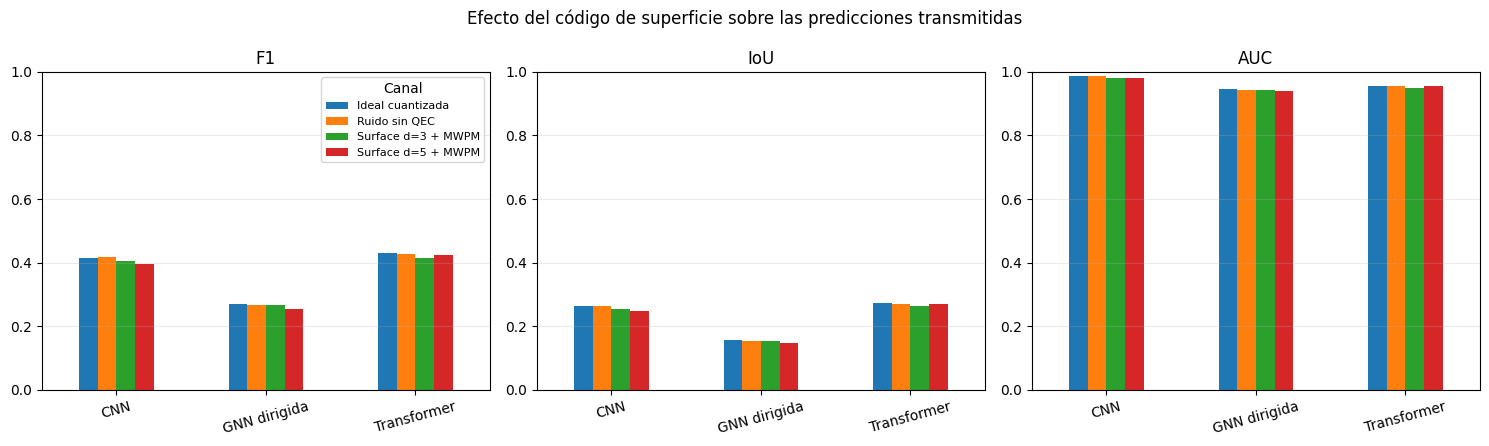

In [17]:
# 11.5 Cuantificar degradación y recuperación atribuible al código de superficie
ideal = (integrated_results[integrated_results['Canal'] == 'Ideal cuantizada']
         .set_index('Modelo'))
raw = (integrated_results[integrated_results['Canal'] == 'Ruido sin QEC']
       .set_index('Modelo'))

recovery_rows = []
for distance in DISTANCIAS_QEC:
    label = f'Surface d={distance} + MWPM'
    protected = integrated_results[integrated_results['Canal'] == label].set_index('Modelo')
    for model_name in ideal.index:
        row = {'Modelo':model_name, 'Distancia':distance}
        for metric in ['F1','IoU','AUC']:
            loss_raw = ideal.loc[model_name,metric] - raw.loc[model_name,metric]
            loss_qec = ideal.loc[model_name,metric] - protected.loc[model_name,metric]
            recovery = np.nan if abs(loss_raw) < 1e-12 else 1 - loss_qec/loss_raw
            row[f'Pérdida_{metric}_sin_QEC'] = loss_raw
            row[f'Pérdida_{metric}_con_QEC'] = loss_qec
            row[f'Recuperación_{metric}'] = recovery
        recovery_rows.append(row)

recovery_results = pd.DataFrame(recovery_rows)
display(recovery_results.style.format({
    c: ('{:.1%}' if c.startswith('Recuperación') else '{:+.4f}')
    for c in recovery_results.columns if c not in ['Modelo','Distancia']
}))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, metric in zip(axes, ['F1','IoU','AUC']):
    pivot = integrated_results.pivot(index='Modelo', columns='Canal', values=metric)
    pivot = pivot.reindex(columns=channel_order)
    pivot.plot(kind='bar', ax=ax, ylim=(0,1), rot=15)
    ax.set_title(metric); ax.set_xlabel(''); ax.grid(axis='y', alpha=.25)
    if ax is not axes[0]: ax.get_legend().remove()
axes[0].legend(title='Canal', fontsize=8)
fig.suptitle('Efecto del código de superficie sobre las predicciones transmitidas')
plt.tight_layout(); plt.show()


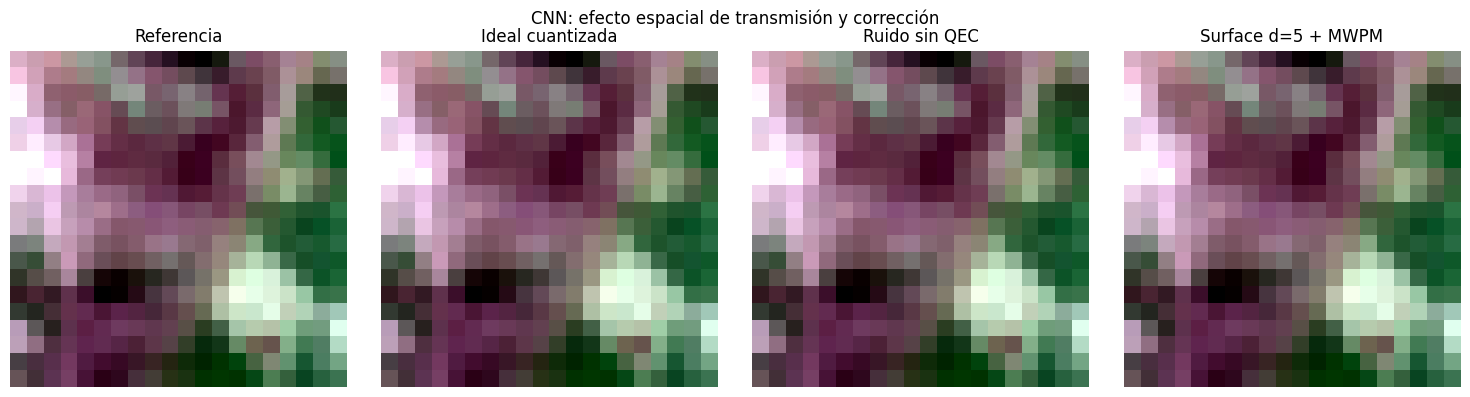

In [18]:
# 11.6 Inspección espacial integrada: ideal, ruido y QEC
from matplotlib.colors import ListedColormap

MODEL_VIS = "CNN"
SAMPLE_VIS = -1
DIST_VIS = max(DISTANCIAS_QEC)

threshold = model_thresholds[MODEL_VIS]

views = [
    ("Referencia", Yte[SAMPLE_VIS]),
    (
        "Ideal cuantizada",
        reconstructed[
            (MODEL_VIS, "Ideal cuantizada")
        ][SAMPLE_VIS] >= threshold,
    ),
    (
        "Ruido sin QEC",
        reconstructed[
            (MODEL_VIS, "Ruido sin QEC")
        ][SAMPLE_VIS] >= threshold,
    ),
    (
        f"Surface d={DIST_VIS} + MWPM",
        reconstructed[
            (MODEL_VIS, f"Surface d={DIST_VIS} + MWPM")
        ][SAMPLE_VIS] >= threshold,
    ),
]

fig, axes = plt.subplots(
    1,
    len(views),
    figsize=(15, 4),
)

for ax, (title, img) in zip(axes, views):
    ax.imshow(rgb)

    mask = np.ma.masked_where(
        ~img.astype(bool),
        img,
    )

    ax.imshow(
        mask,
        cmap=ListedColormap(["#ff2d20"]),
        alpha=0.6,
        vmin=0,
        vmax=1,
    )

    ax.set_title(title)
    ax.axis("off")

fig.suptitle(
    f"{MODEL_VIS}: efecto espacial de transmisión y corrección"
)

plt.tight_layout()
plt.show()

,p_físico,Distancia,LER_MWPM,Fallos,Shots
0,0.100%,3,0.100%,5,5000
1,0.100%,5,0.000%,0,5000
2,0.300%,3,0.860%,43,5000
3,0.300%,5,0.380%,19,5000
4,0.600%,3,2.720%,136,5000
5,0.600%,5,2.780%,139,5000
6,1.000%,3,7.120%,356,5000
7,1.000%,5,9.720%,486,5000


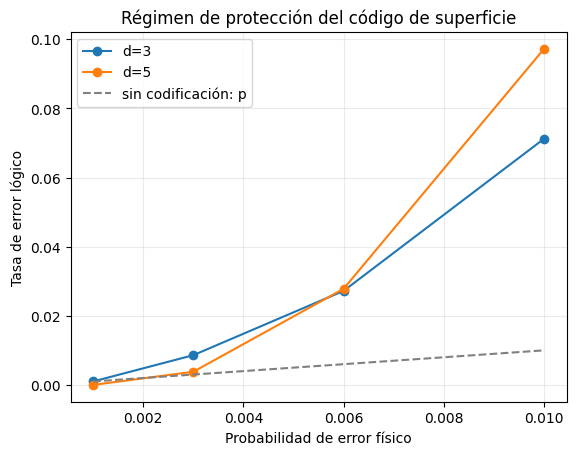

In [19]:
# 11.7 Sensibilidad: barrido de ruido físico y distancia
P_GRID = [0.001, 0.003, 0.006, 0.010]
SHOTS_SWEEP = 5_000
sweep_rows = []
for p in P_GRID:
    for distance in DISTANCIAS_QEC:
        failures, _ = surface_code_failure_stream(
            distance, p, SHOTS_SWEEP,
            SEED_INTEGRACION + int(p*1_000_000) + distance
        )
        sweep_rows.append({'p_físico':p,'Distancia':distance,'LER_MWPM':failures.mean(),'Fallos':failures.sum(),'Shots':len(failures)})

qec_sensitivity = pd.DataFrame(sweep_rows)
display(qec_sensitivity.style.format({'p_físico':'{:.3%}','LER_MWPM':'{:.3%}'}))
for distance, group in qec_sensitivity.groupby('Distancia'):
    plt.plot(group['p_físico'],group['LER_MWPM'],marker='o',label=f'd={distance}')
plt.plot(P_GRID,P_GRID,'--',color='gray',label='sin codificación: p')
plt.xlabel('Probabilidad de error físico');plt.ylabel('Tasa de error lógico')
plt.title('Régimen de protección del código de superficie');plt.grid(alpha=.25);plt.legend();plt.show()


In [20]:
# 11.8 Exportar la evidencia de la integración
integrated_results.to_csv('resultados_incendio_qec_integrado.csv', index=False)
recovery_results.to_csv('recuperacion_metricas_por_qec.csv', index=False)
qec_bridge_summary.to_csv('qec_bridge_resumen.csv', index=False)
qec_sensitivity.to_csv('qec_sensibilidad.csv', index=False)

np.savez_compressed(
    'predicciones_transmitidas_qec.npz',
    Yte=Yte,
    **{f"{m.replace(' ','_')}_{c.replace(' ','_').replace('=','')}":p
       for (m,c),p in reconstructed.items()}
)
print('Integración exportada: resultados, recuperación, sensibilidad y predicciones reconstruidas.')


Integración exportada: resultados, recuperación, sensibilidad y predicciones reconstruidas.


### Interpretación científica de la integración

- Existe aporte del código de superficie si, para el mismo `P_FISICO`, la tasa `LER_MWPM` es menor que la tasa de error de bits sin QEC y las métricas protegidas quedan más cerca de la condición ideal.
- Una recuperación positiva de F1, IoU o AUC indica que QEC recupera parte de la degradación causada por el canal.
- Si una distancia mayor no reduce la LER, no debe afirmarse escalamiento protector para ese nivel de ruido y número de shots.
- La integración representa protección de la información de salida. No convierte a CNN, GNN o Transformer en modelos cuánticos y no mejora su exactitud ideal.
- Para inferencia estadística, repita el experimento con varias semillas y GeoTIFF independientes y reporte intervalos de confianza por imagen completa.


Fases temporales utilizadas:
1. Inicial: pasos 0–3
2. Expansión: pasos 4–7
3. Avanzada: pasos 8–11
4. Final: pasos 12–15

AUC medio por fase:


,Modelo,Fase,AUC_medio,Desviación_estándar,N_válidos,Error_estándar,IC95_inferior,IC95_superior
0,CNN,1. Inicial,0.980,0.011,21,0.002,0.975,0.985
1,GNN,1. Inicial,0.940,0.058,21,0.013,0.916,0.965
2,Transformer,1. Inicial,0.943,0.085,21,0.018,0.907,0.979
3,CNN,2. Expansión,0.985,0.010,16,0.003,0.980,0.990
4,GNN,2. Expansión,0.947,0.033,16,0.008,0.931,0.963
5,Transformer,2. Expansión,0.974,0.027,16,0.007,0.961,0.988
6,CNN,3. Avanzada,0.983,0.014,16,0.003,0.976,0.990
7,GNN,3. Avanzada,0.942,0.123,16,0.031,0.881,1.000
8,Transformer,3. Avanzada,0.969,0.055,16,0.014,0.942,0.996
9,CNN,4. Final,0.974,0.030,9,0.010,0.954,0.994



Comparación compacta:


Modelo,CNN,GNN,Transformer
Fase,,,
1. Inicial,0.980,0.940,0.943
2. Expansión,0.985,0.947,0.974
3. Avanzada,0.983,0.942,0.969
4. Final,0.974,0.913,0.949


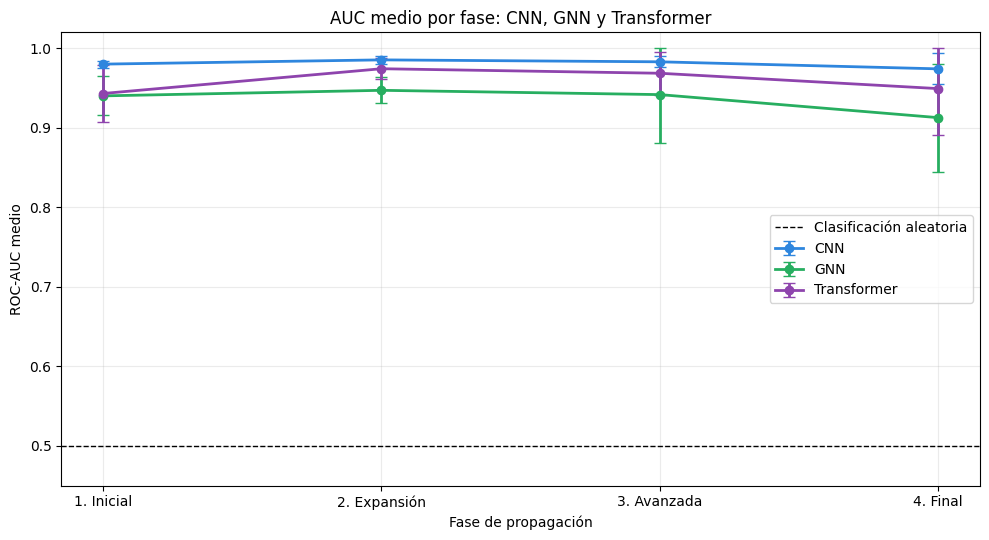


AUC global medio:


,Modelo,AUC_global_medio,Desviación_estándar,Evaluaciones_válidas,Evaluaciones_sin_dos_clases
0,CNN,0.981,0.016,62,34
2,Transformer,0.959,0.067,62,34
1,GNN,0.938,0.081,62,34



Archivos creados:
- auc_por_corrida_paso_y_fase.csv
- auc_medio_por_fase.csv


In [21]:
# ============================================================
# AUC MEDIO POR FASE DE PROPAGACIÓN
# CNN vs GNN dirigida vs Transformer
# ============================================================

from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Modelos que serán comparados
MODELOS_AUC = {
    "CNN": models["CNN"],
    "GNN": models["GNN dirigida"],
    "Transformer": models["Transformer"],
}

n_test_runs = cfg.n_runs - cfg.train_runs
n_steps = cfg.steps

# Comprobar que el orden de Xte/Yte corresponde a:
# corrida 1: t0...tN, corrida 2: t0...tN, etc.
esperados = n_test_runs * n_steps

if len(Xte) != esperados:
    raise ValueError(
        f"Se esperaban {esperados} observaciones de prueba "
        f"({n_test_runs} corridas × {n_steps} pasos), "
        f"pero Xte contiene {len(Xte)}."
    )

# ------------------------------------------------------------
# Definición temporal de las fases
# ------------------------------------------------------------

indices_temporales = np.arange(n_steps)
bloques = np.array_split(indices_temporales, 4)

FASES = {
    "1. Inicial": bloques[0],
    "2. Expansión": bloques[1],
    "3. Avanzada": bloques[2],
    "4. Final": bloques[3],
}

print("Fases temporales utilizadas:")

for fase, pasos in FASES.items():
    print(f"{fase}: pasos {pasos[0]}–{pasos[-1]}")

# Reorganizar las etiquetas:
# [corrida, tiempo, fila, columna]
Yte_fases = Yte.reshape(
    n_test_runs,
    n_steps,
    cfg.grid,
    cfg.grid,
)

resultados_auc = []
auc_temporal = []

# ------------------------------------------------------------
# Inferencia y AUC por corrida y paso
# ------------------------------------------------------------

for nombre_modelo, modelo in MODELOS_AUC.items():

    probabilidades, tiempo_inferencia = probabilities(
        modelo,
        Xte,
        batch=16,
    )

    probabilidades = probabilidades.reshape(
        n_test_runs,
        n_steps,
        cfg.grid,
        cfg.grid,
    )

    for corrida in range(n_test_runs):

        for paso in range(n_steps):

            y_true = Yte_fases[corrida, paso].ravel()
            y_score = probabilidades[corrida, paso].ravel()

            # ROC-AUC requiere presencia de ambas clases
            if np.unique(y_true).size < 2:
                auc = np.nan
            else:
                auc = roc_auc_score(y_true, y_score)

            fase_actual = next(
                fase
                for fase, pasos in FASES.items()
                if paso in pasos
            )

            auc_temporal.append({
                "Modelo": nombre_modelo,
                "Corrida_test": corrida + 1,
                "Paso": paso,
                "Fase": fase_actual,
                "AUC": auc,
            })

auc_temporal = pd.DataFrame(auc_temporal)

# ------------------------------------------------------------
# Resumen estadístico por modelo y fase
# ------------------------------------------------------------

resumen_auc = (
    auc_temporal
    .groupby(["Modelo", "Fase"], as_index=False)
    .agg(
        AUC_medio=("AUC", "mean"),
        Desviación_estándar=("AUC", "std"),
        N_válidos=("AUC", "count"),
    )
)

resumen_auc["Error_estándar"] = (
    resumen_auc["Desviación_estándar"]
    / np.sqrt(resumen_auc["N_válidos"].clip(lower=1))
)

resumen_auc["IC95_inferior"] = (
    resumen_auc["AUC_medio"]
    - 1.96 * resumen_auc["Error_estándar"]
).clip(0, 1)

resumen_auc["IC95_superior"] = (
    resumen_auc["AUC_medio"]
    + 1.96 * resumen_auc["Error_estándar"]
).clip(0, 1)

orden_fases = list(FASES.keys())

resumen_auc["Fase"] = pd.Categorical(
    resumen_auc["Fase"],
    categories=orden_fases,
    ordered=True,
)

resumen_auc = resumen_auc.sort_values(
    ["Fase", "Modelo"]
).reset_index(drop=True)

print("\nAUC medio por fase:")

display(
    resumen_auc.style.format({
        "AUC_medio": "{:.3f}",
        "Desviación_estándar": "{:.3f}",
        "Error_estándar": "{:.3f}",
        "IC95_inferior": "{:.3f}",
        "IC95_superior": "{:.3f}",
    })
)

# ------------------------------------------------------------
# Tabla comparativa compacta
# ------------------------------------------------------------

tabla_auc = resumen_auc.pivot(
    index="Fase",
    columns="Modelo",
    values="AUC_medio",
)

print("\nComparación compacta:")

display(
    tabla_auc.style
    .format("{:.3f}")
    .background_gradient(
        cmap="RdYlGn",
        vmin=0.5,
        vmax=1.0,
    )
)

# ------------------------------------------------------------
# Gráfico del AUC medio por fase con IC del 95 %
# ------------------------------------------------------------

colores = {
    "CNN": "#2E86DE",
    "GNN": "#27AE60",
    "Transformer": "#8E44AD",
}

plt.figure(figsize=(10, 5.5))

x = np.arange(len(orden_fases))

for nombre_modelo in MODELOS_AUC:

    datos = (
        resumen_auc[
            resumen_auc["Modelo"] == nombre_modelo
        ]
        .set_index("Fase")
        .reindex(orden_fases)
    )

    media = datos["AUC_medio"].to_numpy(dtype=float)
    inferior = datos["IC95_inferior"].to_numpy(dtype=float)
    superior = datos["IC95_superior"].to_numpy(dtype=float)

    error = np.vstack([
        media - inferior,
        superior - media,
    ])

    plt.errorbar(
        x,
        media,
        yerr=error,
        marker="o",
        linewidth=2,
        capsize=4,
        label=nombre_modelo,
        color=colores[nombre_modelo],
    )

plt.axhline(
    0.5,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Clasificación aleatoria",
)

plt.xticks(x, orden_fases)
plt.ylim(0.45, 1.02)
plt.xlabel("Fase de propagación")
plt.ylabel("ROC-AUC medio")
plt.title("AUC medio por fase: CNN, GNN y Transformer")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# AUC global de cada modelo
# ------------------------------------------------------------

auc_global = (
    auc_temporal
    .groupby("Modelo", as_index=False)
    .agg(
        AUC_global_medio=("AUC", "mean"),
        Desviación_estándar=("AUC", "std"),
        Evaluaciones_válidas=("AUC", "count"),
        Evaluaciones_sin_dos_clases=(
            "AUC",
            lambda x: int(x.isna().sum()),
        ),
    )
    .sort_values(
        "AUC_global_medio",
        ascending=False,
    )
)

print("\nAUC global medio:")

display(
    auc_global.style.format({
        "AUC_global_medio": "{:.3f}",
        "Desviación_estándar": "{:.3f}",
    })
)

# Exportar resultados
auc_temporal.to_csv(
    "auc_por_corrida_paso_y_fase.csv",
    index=False,
)

resumen_auc.to_csv(
    "auc_medio_por_fase.csv",
    index=False,
)

print(
    "\nArchivos creados:\n"
    "- auc_por_corrida_paso_y_fase.csv\n"
    "- auc_medio_por_fase.csv"
)

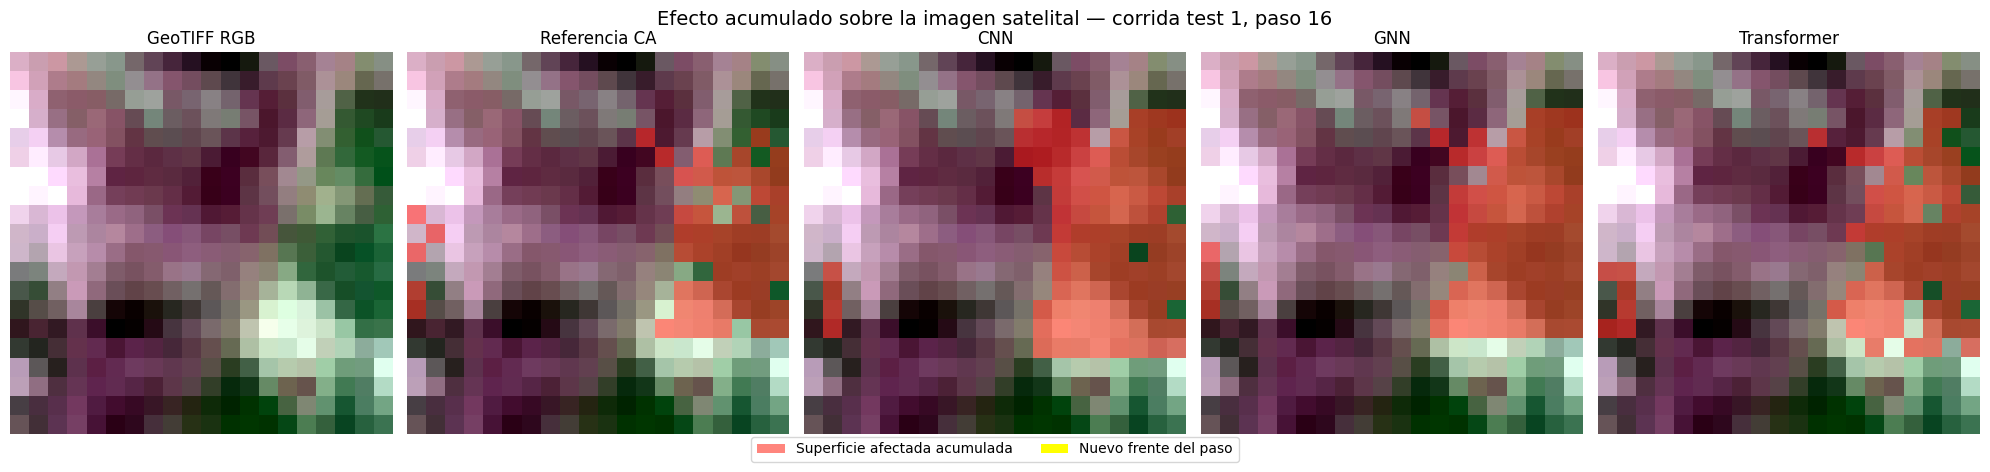

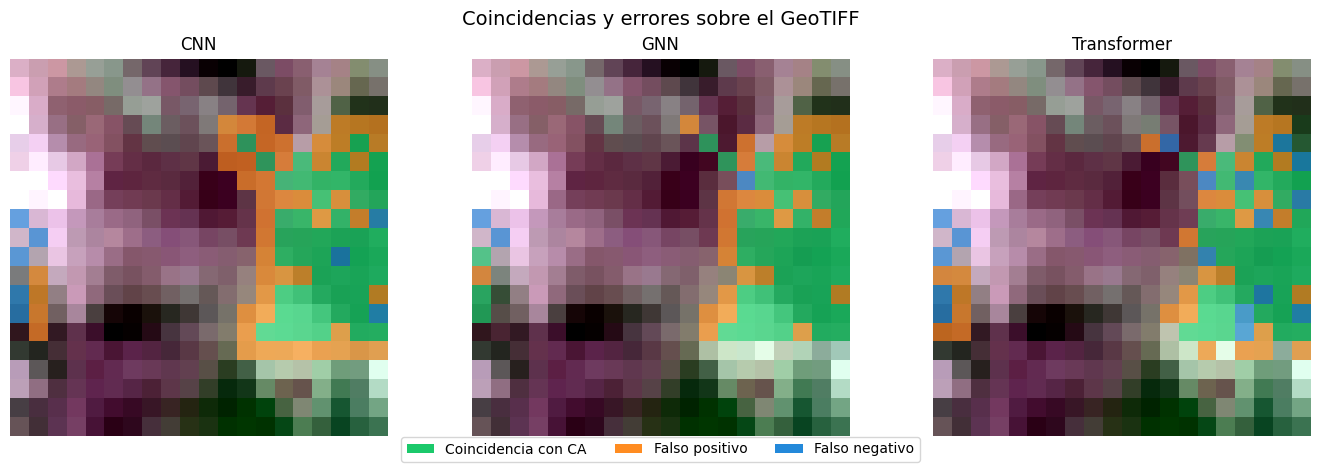

,Modelo,Verdaderos_positivos,Falsos_positivos,Falsos_negativos,IoU_acumulado,Fracción_predicha,Fracción_referencia
1,GNN,54,29,3,0.628,20.8%,14.2%
0,CNN,49,49,8,0.462,24.5%,14.2%
2,Transformer,40,30,17,0.460,17.5%,14.2%


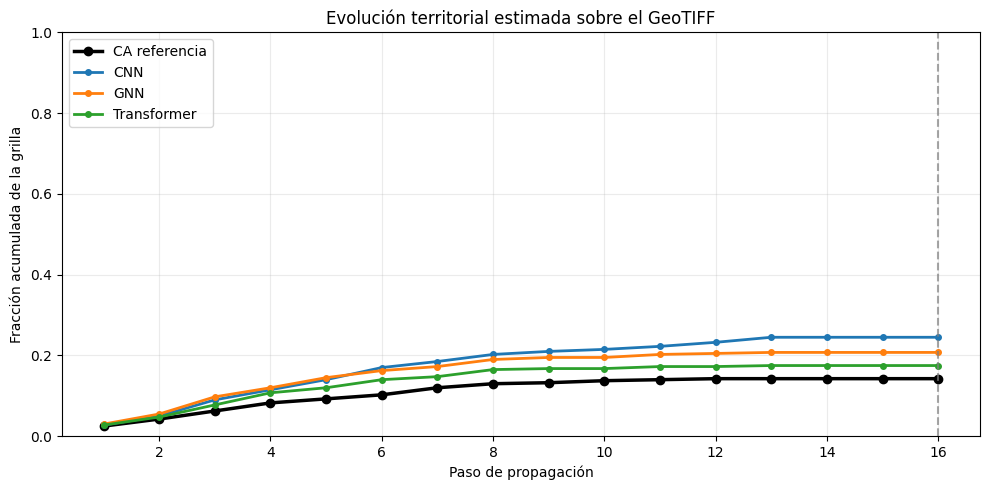

Archivo creado: efecto_modelos_sobre_geotiff.csv


In [22]:
# ============================================================
# EFECTO DE CNN, GNN Y TRANSFORMER SOBRE LA IMAGEN SATELITAL
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# ------------------------------------------------------------
# Configuración editable
# ------------------------------------------------------------

CORRIDA_TEST = 1       # Valores desde 1 hasta n_test_runs
PASO_VISUALIZADO = cfg.steps   # 1 hasta cfg.steps
ALPHA_INCENDIO = 0.58

MODELOS_VISUALES = {
    "CNN": "CNN",
    "GNN": "GNN dirigida",
    "Transformer": "Transformer",
}

n_test_runs = cfg.n_runs - cfg.train_runs

if not 1 <= CORRIDA_TEST <= n_test_runs:
    raise ValueError(
        f"CORRIDA_TEST debe estar entre 1 y {n_test_runs}."
    )

if not 1 <= PASO_VISUALIZADO <= cfg.steps:
    raise ValueError(
        f"PASO_VISUALIZADO debe estar entre 1 y {cfg.steps}."
    )

# Índices internos
run_idx = CORRIDA_TEST - 1
step_idx = PASO_VISUALIZADO - 1

# ------------------------------------------------------------
# Reorganizar resultados por corrida y tiempo
# ------------------------------------------------------------

Cte_runs = Cte.reshape(
    n_test_runs,
    cfg.steps,
    cfg.grid,
    cfg.grid,
)

Yte_runs = Yte.reshape(
    n_test_runs,
    cfg.steps,
    cfg.grid,
    cfg.grid,
)

pred_runs = {}

for nombre_visible, clave_modelo in MODELOS_VISUALES.items():

    if clave_modelo not in preds:
        raise KeyError(
            f"No se encontró '{clave_modelo}' en preds. "
            f"Claves disponibles: {list(preds.keys())}"
        )

    pred_runs[nombre_visible] = preds[clave_modelo].reshape(
        n_test_runs,
        cfg.steps,
        cfg.grid,
        cfg.grid,
    )

# ------------------------------------------------------------
# Máscara acumulada de referencia
# ------------------------------------------------------------

referencia_acumulada = Cte_runs[
    run_idx,
    step_idx,
].astype(bool)

frente_real_actual = Yte_runs[
    run_idx,
    step_idx,
].astype(bool)

# Estado inicial de la corrida:
# canal 3 = ardiendo; canal 4 = quemado
inicio_corrida = run_idx * cfg.steps

estado_inicial = (
    (Xte[inicio_corrida, 3] > 0.5)
    | (Xte[inicio_corrida, 4] > 0.5)
)

# ------------------------------------------------------------
# Acumular los frentes predichos hasta el paso seleccionado
# ------------------------------------------------------------

predicciones_acumuladas = {}

for nombre, pred_modelo in pred_runs.items():

    frentes_hasta_paso = pred_modelo[
        run_idx,
        :PASO_VISUALIZADO,
    ].astype(bool)

    predicciones_acumuladas[nombre] = (
        estado_inicial
        | np.any(frentes_hasta_paso, axis=0)
    )

# ------------------------------------------------------------
# Función para superponer incendios sobre el RGB
# ------------------------------------------------------------

def mostrar_overlay(
    ax,
    imagen_rgb,
    mascara,
    titulo,
    frente=None,
):
    ax.imshow(imagen_rgb)

    overlay = np.ma.masked_where(
        ~mascara,
        mascara.astype(float),
    )

    ax.imshow(
        overlay,
        cmap=ListedColormap(["#ff2d20"]),
        alpha=ALPHA_INCENDIO,
        vmin=0,
        vmax=1,
        interpolation="nearest",
    )

    # Contorno del nuevo frente del paso seleccionado
    if frente is not None and np.any(frente):
        ax.contour(
            frente.astype(float),
            levels=[0.5],
            colors=["#ffff00"],
            linewidths=1.7,
        )

    ax.set_title(titulo)
    ax.axis("off")

# ------------------------------------------------------------
# Figura 1: efecto territorial sobre la imagen satelital
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    5,
    figsize=(20, 4.5),
)

axes[0].imshow(rgb)
axes[0].set_title("GeoTIFF RGB")
axes[0].axis("off")

mostrar_overlay(
    axes[1],
    rgb,
    referencia_acumulada,
    "Referencia CA",
    frente=frente_real_actual,
)

for ax, nombre in zip(
    axes[2:],
    ["CNN", "GNN", "Transformer"],
):
    frente_modelo = pred_runs[nombre][
        run_idx,
        step_idx,
    ].astype(bool)

    mostrar_overlay(
        ax,
        rgb,
        predicciones_acumuladas[nombre],
        nombre,
        frente=frente_modelo,
    )

fig.suptitle(
    f"Efecto acumulado sobre la imagen satelital — "
    f"corrida test {CORRIDA_TEST}, paso {PASO_VISUALIZADO}",
    fontsize=14,
)

leyenda = [
    Patch(
        facecolor="#ff2d20",
        alpha=ALPHA_INCENDIO,
        label="Superficie afectada acumulada",
    ),
    Patch(
        facecolor="#ffff00",
        label="Nuevo frente del paso",
    ),
]

fig.legend(
    handles=leyenda,
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.5, -0.04),
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Figura 2: errores territoriales de cada modelo
# ------------------------------------------------------------

# Colores:
# 0 = coincidencia negativa/transparente
# 1 = verdadero positivo (verde)
# 2 = falso positivo (naranjo)
# 3 = falso negativo (azul)

error_cmap = ListedColormap([
    "#00000000",
    "#1bc96b",
    "#ff8c21",
    "#2389da",
])

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 4.5),
)

resumen_espacial = []

for ax, nombre in zip(
    axes,
    ["CNN", "GNN", "Transformer"],
):
    estimada = predicciones_acumuladas[nombre]

    tp = estimada & referencia_acumulada
    fp = estimada & ~referencia_acumulada
    fn = ~estimada & referencia_acumulada

    mapa_error = np.zeros(
        referencia_acumulada.shape,
        dtype=np.uint8,
    )

    mapa_error[tp] = 1
    mapa_error[fp] = 2
    mapa_error[fn] = 3

    ax.imshow(rgb)

    overlay = np.ma.masked_where(
        mapa_error == 0,
        mapa_error,
    )

    ax.imshow(
        overlay,
        cmap=error_cmap,
        vmin=0,
        vmax=3,
        alpha=0.68,
        interpolation="nearest",
    )

    ax.set_title(nombre)
    ax.axis("off")

    union = np.sum(
        estimada | referencia_acumulada
    )

    interseccion = np.sum(
        estimada & referencia_acumulada
    )

    iou_espacial = (
        interseccion / union
        if union > 0
        else np.nan
    )

    resumen_espacial.append({
        "Modelo": nombre,
        "Verdaderos_positivos": int(tp.sum()),
        "Falsos_positivos": int(fp.sum()),
        "Falsos_negativos": int(fn.sum()),
        "IoU_acumulado": iou_espacial,
        "Fracción_predicha": float(estimada.mean()),
        "Fracción_referencia": float(
            referencia_acumulada.mean()
        ),
    })

fig.suptitle(
    "Coincidencias y errores sobre el GeoTIFF",
    fontsize=14,
)

leyenda_error = [
    Patch(
        facecolor="#1bc96b",
        label="Coincidencia con CA",
    ),
    Patch(
        facecolor="#ff8c21",
        label="Falso positivo",
    ),
    Patch(
        facecolor="#2389da",
        label="Falso negativo",
    ),
]

fig.legend(
    handles=leyenda_error,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.04),
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Tabla de impacto territorial
# ------------------------------------------------------------

resumen_espacial = pd.DataFrame(
    resumen_espacial
).sort_values(
    "IoU_acumulado",
    ascending=False,
)

display(
    resumen_espacial.style.format({
        "IoU_acumulado": "{:.3f}",
        "Fracción_predicha": "{:.1%}",
        "Fracción_referencia": "{:.1%}",
    })
)

# ------------------------------------------------------------
# Figura 3: evolución de superficie afectada
# ------------------------------------------------------------

pasos = np.arange(1, cfg.steps + 1)

referencia_por_tiempo = Cte_runs[
    run_idx
].mean(axis=(1, 2))

plt.figure(figsize=(10, 5))

plt.plot(
    pasos,
    referencia_por_tiempo,
    color="black",
    linewidth=2.5,
    marker="o",
    label="CA referencia",
)

for nombre in ["CNN", "GNN", "Transformer"]:

    pred_modelo = pred_runs[nombre][
        run_idx
    ].astype(bool)

    acumulado = estado_inicial.copy()
    fraccion = []

    for t in range(cfg.steps):
        acumulado = acumulado | pred_modelo[t]
        fraccion.append(acumulado.mean())

    plt.plot(
        pasos,
        fraccion,
        linewidth=2,
        marker="o",
        markersize=4,
        label=nombre,
    )

plt.axvline(
    PASO_VISUALIZADO,
    color="gray",
    linestyle="--",
    alpha=0.7,
)

plt.xlabel("Paso de propagación")
plt.ylabel("Fracción acumulada de la grilla")
plt.title(
    "Evolución territorial estimada sobre el GeoTIFF"
)
plt.ylim(0, 1)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# Exportación
resumen_espacial.to_csv(
    "efecto_modelos_sobre_geotiff.csv",
    index=False,
)

print(
    "Archivo creado: "
    "efecto_modelos_sobre_geotiff.csv"
)

## 11. Exportación

In [23]:
# 11. Guardar resultados y GeoTIFF final
model_results.to_csv('metricas_modelos_nuevo_frente.csv',index=False)
corr_results.to_csv('metricas_correccion_clasica.csv',index=False)
qec_results.to_csv('metricas_codigo_superficie_mwpm.csv',index=False)
last_seq=runs[-1][0];final_burn=np.isin(last_seq[-1],[1,2]).astype('uint8')
profile={'driver':'GTiff','height':cfg.grid,'width':cfg.grid,'count':1,'dtype':'uint8','crs':crs,'transform':transform_grid,'nodata':255,'compress':'deflate'}
with rasterio.open('propagacion_final_CA_georreferenciada.tif','w',**profile) as dst:
    dst.write(np.where(valid,final_burn,255).astype('uint8'),1);dst.set_band_description(1,'CA_final_0_no_1_si_255_nodata')
np.savez_compressed('artefactos_experimento_v2.npz',fuel=fuel,ndvi=ndvi,ndmi=ndmi,nbr=nbr,Yte=Yte,Cte=Cte,**{n.replace(' ','_'):p for n,p in preds.items()})
print('Creados: métricas de modelos, corrección clásica, QEC-MWPM, NPZ y GeoTIFF final.')

Creados: métricas de modelos, corrección clásica, QEC-MWPM, NPZ y GeoTIFF final.


## Criterios de interpretación

1. Compare CNN, Transformer y GNN solamente en `metricas_modelos_nuevo_frente.csv`.
2. Use balanced accuracy, precisión, recall, F1 e IoU; no use accuracy simple con frentes escasos.
3. Compare ruido y corrección solamente en `metricas_correccion_clasica.csv`.
4. El aporte del código de superficie se evalúa con `LER_MWPM`, no con la similitud de imágenes.
5. Hay evidencia de protección cuántica cuando, para el mismo ruido físico, una mayor distancia reduce significativamente la LER.
6. Las corridas siguen compartiendo una imagen. La generalización territorial exige repetir el estudio con múltiples GeoTIFF y separar imágenes completas entre entrenamiento y prueba.

## 12. Extensión independiente: comparación equitativa del código de superficie

Esta sección **no modifica ni reemplaza el experimento anterior**. Añade una evaluación complementaria donde el mismo circuito de memoria de código de superficie se analiza:

- sin utilizar los síndromes para corregir;
- con decodificación MWPM;
- para distancias 3, 5 y 7;
- con cuantización de 8 bits;
- con varias semillas y un barrido ampliado de ruido.

La comparación central es `LER_sin_decodificar` frente a `LER_MWPM`. Existe aporte corrector cuando MWPM reduce la tasa de error lógico dentro del mismo circuito. Existe evidencia de escalamiento protector cuando aumentar la distancia reduce sistemáticamente la LER.


In [24]:
# 12.1 Configuración independiente (no altera CFG, Q_BITS ni P_GRID anteriores)
from dataclasses import dataclass
from statistics import NormalDist

@dataclass
class QECEXTConfig:
    mode: str = 'PUBLICACION'  # 20.000 shots y 5 semillas
    q_bits: int = 8
    distances: tuple = (3, 5, 7)
    p_grid: tuple = (0.0005, 0.0010, 0.0020, 0.0030, 0.0040, 0.0060, 0.0080, 0.0100)
    p_application: tuple = (0.0010, 0.0060)  # régimen favorable y régimen exigente
    rounds_factor: int = 1
    seed: int = 42026

QEC_EXT = QECEXTConfig()

if QEC_EXT.mode.upper() == 'PUBLICACION':
    SHOTS_EXT = 20_000
    SEEDS_EXT = [QEC_EXT.seed + i for i in range(5)]
else:
    SHOTS_EXT = 5_000
    SEEDS_EXT = [QEC_EXT.seed + i for i in range(2)]

print('Modo:', QEC_EXT.mode)
print('Cuantización:', QEC_EXT.q_bits, 'bits')
print('Distancias:', QEC_EXT.distances)
print('Shots por combinación y semilla:', f'{SHOTS_EXT:,}')
print('Semillas:', len(SEEDS_EXT))


Modo: PUBLICACION
Cuantización: 8 bits
Distancias: (3, 5, 7)
Shots por combinación y semilla: 20,000
Semillas: 5


In [25]:
# 12.2 Utilidades: cuantización de 8 bits e intervalos de Wilson
def quantize_ext(probabilities, bits=QEC_EXT.q_bits):
    levels = 2**bits - 1
    integers = np.rint(np.clip(probabilities, 0, 1) * levels).astype(np.uint16)
    shifts = np.arange(bits - 1, -1, -1, dtype=np.uint16)
    return ((integers[..., None] >> shifts) & 1).astype(np.uint8)

def dequantize_ext(bits_array):
    bits = bits_array.shape[-1]
    weights = (2 ** np.arange(bits - 1, -1, -1)).astype(np.uint16)
    integers = np.sum(bits_array.astype(np.uint16) * weights, axis=-1)
    return integers.astype(np.float32) / float(2**bits - 1)

def wilson_interval(errors, shots, confidence=0.95):
    if shots <= 0:
        return np.nan, np.nan
    z = NormalDist().inv_cdf(0.5 + confidence/2)
    phat = errors/shots
    den = 1 + z*z/shots
    center = (phat + z*z/(2*shots))/den
    half = z*np.sqrt(phat*(1-phat)/shots + z*z/(4*shots*shots))/den
    return max(0, center-half), min(1, center+half)

def repeat_stream_ext(values, length, seed):
    rng = np.random.default_rng(seed)
    values = np.asarray(values, dtype=np.uint8)
    if values.size == 0:
        return np.zeros(length, dtype=np.uint8)
    output = np.resize(rng.permutation(values), length)
    rng.shuffle(output)
    return output

print('Paso de cuantización:', 1/(2**QEC_EXT.q_bits-1))


Paso de cuantización: 0.00392156862745098


In [26]:
# 12.3 Mismo circuito: sin decodificación versus MWPM
def surface_trial_paired_ext(distance, p, shots, seed, return_streams=False):
    circuit = stim.Circuit.generated(
        'surface_code:rotated_memory_x',
        distance=distance,
        rounds=distance * QEC_EXT.rounds_factor,
        after_clifford_depolarization=p,
        before_round_data_depolarization=p,
        before_measure_flip_probability=p,
        after_reset_flip_probability=p,
    )

    dem = circuit.detector_error_model(decompose_errors=True)
    matching = pymatching.Matching.from_detector_error_model(dem)
    sampler = circuit.compile_detector_sampler(seed=seed)
    detectors, observables = sampler.sample(shots=shots, separate_observables=True)

    # Sin decodificación: se ignoran los síndromes y se predice observable lógico 0.
    no_decoder_prediction = np.zeros_like(observables, dtype=np.uint8)
    failures_no_decoder = np.any(no_decoder_prediction != observables, axis=1).astype(np.uint8)

    # Con MWPM: los síndromes se utilizan para estimar la corrección lógica.
    mwpm_prediction = matching.decode_batch(detectors)
    failures_mwpm = np.any(mwpm_prediction != observables, axis=1).astype(np.uint8)

    result = {
        'distance': distance,
        'p_físico': p,
        'seed': seed,
        'shots': shots,
        'fallos_sin_decodificar': int(failures_no_decoder.sum()),
        'fallos_MWPM': int(failures_mwpm.sum()),
        'LER_sin_decodificar': float(failures_no_decoder.mean()),
        'LER_MWPM': float(failures_mwpm.mean()),
        'qubits': circuit.num_qubits,
        'detectores': circuit.num_detectors,
    }
    if return_streams:
        result['stream_sin_decodificar'] = failures_no_decoder
        result['stream_MWPM'] = failures_mwpm
    return result

# Prueba mínima para validar formas antes del barrido completo
_test_ext = surface_trial_paired_ext(3, 0.001, 32, QEC_EXT.seed, return_streams=True)
assert len(_test_ext['stream_sin_decodificar']) == 32
assert len(_test_ext['stream_MWPM']) == 32
print('Prueba del circuito comparativo: OK')


Prueba del circuito comparativo: OK


In [27]:
# 12.4 Barrido ampliado por ruido, distancia y semilla
qec_ext_rows = []

for p in QEC_EXT.p_grid:
    for distance in QEC_EXT.distances:
        for seed in SEEDS_EXT:
            qec_ext_rows.append(surface_trial_paired_ext(
                distance=distance, p=p, shots=SHOTS_EXT, seed=seed
            ))

qec_ext_runs = pd.DataFrame(qec_ext_rows)

qec_ext_summary = (
    qec_ext_runs.groupby(['distance','p_físico'], as_index=False)
    .agg(
        shots=('shots','sum'),
        fallos_sin_decodificar=('fallos_sin_decodificar','sum'),
        fallos_MWPM=('fallos_MWPM','sum'),
        semillas=('seed','nunique'),
        qubits=('qubits','first'),
        detectores=('detectores','first'),
    )
)
qec_ext_summary['LER_sin_decodificar'] = (
    qec_ext_summary['fallos_sin_decodificar']/qec_ext_summary['shots']
)
qec_ext_summary['LER_MWPM'] = qec_ext_summary['fallos_MWPM']/qec_ext_summary['shots']
qec_ext_summary['reducción_absoluta'] = (
    qec_ext_summary['LER_sin_decodificar']-qec_ext_summary['LER_MWPM']
)
qec_ext_summary['reducción_relativa'] = np.where(
    qec_ext_summary['LER_sin_decodificar'] > 0,
    1-qec_ext_summary['LER_MWPM']/qec_ext_summary['LER_sin_decodificar'],
    np.nan,
)
qec_ext_summary['MWPM_aporta'] = qec_ext_summary['reducción_absoluta'] > 0

intervals_no = [wilson_interval(e,n) for e,n in zip(
    qec_ext_summary['fallos_sin_decodificar'], qec_ext_summary['shots'])]
intervals_mwpm = [wilson_interval(e,n) for e,n in zip(
    qec_ext_summary['fallos_MWPM'], qec_ext_summary['shots'])]
qec_ext_summary[['IC95_no_inf','IC95_no_sup']] = intervals_no
qec_ext_summary[['IC95_MWPM_inf','IC95_MWPM_sup']] = intervals_mwpm

display(qec_ext_summary.style.format({
    'p_físico':'{:.3%}', 'LER_sin_decodificar':'{:.3%}', 'LER_MWPM':'{:.3%}',
    'reducción_absoluta':'{:+.3%}', 'reducción_relativa':'{:+.1%}',
    'IC95_no_inf':'{:.3%}', 'IC95_no_sup':'{:.3%}',
    'IC95_MWPM_inf':'{:.3%}', 'IC95_MWPM_sup':'{:.3%}',
}))


,distance,p_físico,shots,fallos_sin_decodificar,fallos_MWPM,semillas,qubits,detectores,LER_sin_decodificar,LER_MWPM,reducción_absoluta,reducción_relativa,MWPM_aporta,IC95_no_inf,IC95_no_sup,IC95_MWPM_inf,IC95_MWPM_sup
0,3,0.050%,100000,1129,22,5,26,24,1.129%,0.022%,+1.107%,+98.1%,True,1.065%,1.196%,0.015%,0.033%
1,3,0.100%,100000,2235,84,5,26,24,2.235%,0.084%,+2.151%,+96.2%,True,2.145%,2.328%,0.068%,0.104%
2,3,0.200%,100000,4424,339,5,26,24,4.424%,0.339%,+4.085%,+92.3%,True,4.298%,4.553%,0.305%,0.377%
3,3,0.300%,100000,6539,703,5,26,24,6.539%,0.703%,+5.836%,+89.2%,True,6.387%,6.694%,0.653%,0.757%
4,3,0.400%,100000,8520,1262,5,26,24,8.520%,1.262%,+7.258%,+85.2%,True,8.349%,8.695%,1.195%,1.333%
5,3,0.600%,100000,12036,2733,5,26,24,12.036%,2.733%,+9.303%,+77.3%,True,11.836%,12.239%,2.634%,2.836%
6,3,0.800%,100000,15697,4490,5,26,24,15.697%,4.490%,+11.207%,+71.4%,True,15.473%,15.924%,4.363%,4.620%
7,3,1.000%,100000,18437,6538,5,26,24,18.437%,6.538%,+11.899%,+64.5%,True,18.198%,18.679%,6.386%,6.693%
8,5,0.050%,100000,3022,1,5,64,120,3.022%,0.001%,+3.021%,+100.0%,True,2.918%,3.130%,0.000%,0.006%
9,5,0.100%,100000,5792,10,5,64,120,5.792%,0.010%,+5.782%,+99.8%,True,5.649%,5.938%,0.005%,0.018%


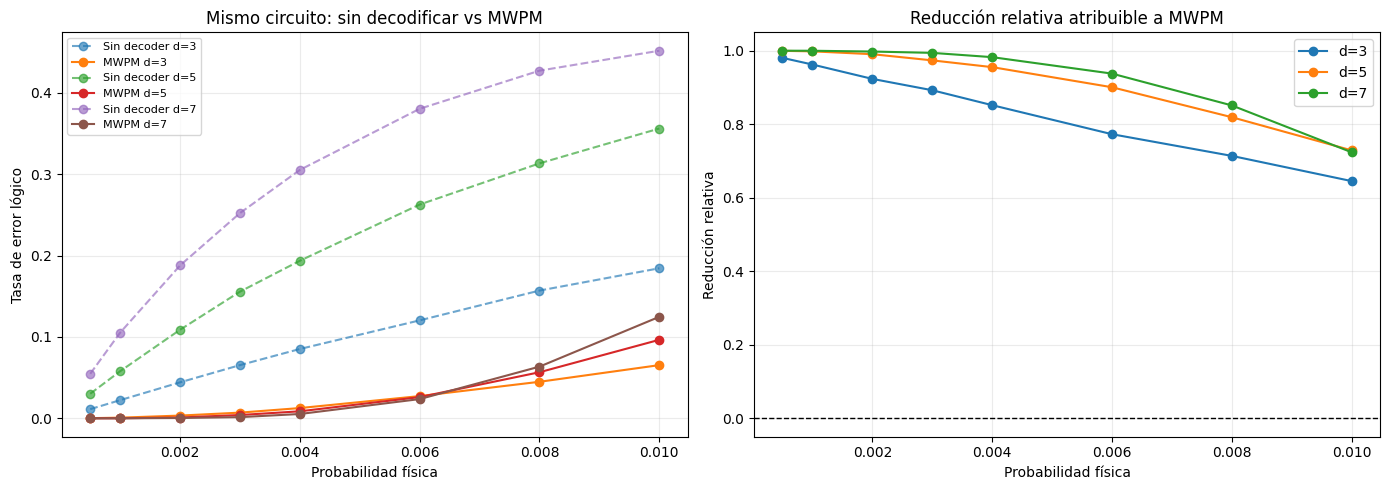

Configuraciones donde MWPM aporta: 24 de 24


In [28]:
# 12.5 Gráficos: aporte del decodificador y escalamiento con distancia
fig, axes = plt.subplots(1, 2, figsize=(14,5))

for distance in QEC_EXT.distances:
    data = qec_ext_summary[qec_ext_summary['distance']==distance].sort_values('p_físico')
    axes[0].plot(data['p_físico'], data['LER_sin_decodificar'], '--', marker='o',
                 alpha=.65, label=f'Sin decoder d={distance}')
    axes[0].plot(data['p_físico'], data['LER_MWPM'], '-', marker='o',
                 label=f'MWPM d={distance}')
    axes[1].plot(data['p_físico'], data['reducción_relativa'], marker='o', label=f'd={distance}')

axes[0].set_title('Mismo circuito: sin decodificar vs MWPM')
axes[0].set_xlabel('Probabilidad física'); axes[0].set_ylabel('Tasa de error lógico')
axes[0].grid(alpha=.25); axes[0].legend(fontsize=8)
axes[1].axhline(0,color='black',linestyle='--',linewidth=1)
axes[1].set_title('Reducción relativa atribuible a MWPM')
axes[1].set_xlabel('Probabilidad física'); axes[1].set_ylabel('Reducción relativa')
axes[1].grid(alpha=.25); axes[1].legend()
plt.tight_layout(); plt.show()

print('Configuraciones donde MWPM aporta:', int(qec_ext_summary['MWPM_aporta'].sum()),
      'de', len(qec_ext_summary))


### Criterio de lectura

- `MWPM_aporta=True`: el uso de los síndromes reduce la LER dentro del mismo circuito.
- `reducción_relativa > 0`: proporción del error lógico eliminada por MWPM.
- Para afirmar escalamiento protector, la LER con MWPM debe disminuir al pasar de (d=3) a (d=5) y (d=7), considerando los intervalos de confianza.
- Esta comparación demuestra el aporte del **decodificador y del esquema de corrección**, pero no constituye por sí sola una ventaja cuántica computacional.


In [29]:
# 12.6 Preparar probabilidades con 8 bits y recalibrar umbrales sin usar prueba
prob_train_ext = {}
prob_test_ext = {}
thresholds_8bit_ext = {}

for model_name, model in models.items():
    p_train, _ = probabilities(model, Xtr)
    p_test, _ = probabilities(model, Xte)
    p_train_q = dequantize_ext(quantize_ext(p_train))
    p_test_q = dequantize_ext(quantize_ext(p_test))
    prob_train_ext[model_name] = p_train_q
    prob_test_ext[model_name] = p_test_q
    thresholds_8bit_ext[model_name] = best_threshold(Ytr, p_train_q)

quantization_control_ext = []
for model_name in prob_test_ext:
    threshold = thresholds_8bit_ext[model_name]
    p = prob_test_ext[model_name]
    quantization_control_ext.append({
        'Modelo': model_name,
        'Umbral_8bit': threshold,
        **evaluate_probability_map(Yte, p, threshold),
    })

quantization_control_ext = pd.DataFrame(quantization_control_ext)
display(quantization_control_ext.style.format({
    'Umbral_8bit':'{:.3f}','F1':'{:.3f}','IoU':'{:.3f}','AUC':'{:.3f}',
    'Balanced_accuracy':'{:.3f}','Precision':'{:.3f}','Recall':'{:.3f}',
}))


,Modelo,Umbral_8bit,F1,IoU,Balanced_accuracy,Precision,Recall,AUC
0,CNN,0.875,0.412,0.259,0.920,0.271,0.859,0.988
1,Transformer,0.900,0.429,0.273,0.851,0.307,0.715,0.962
2,GNN dirigida,0.800,0.301,0.177,0.785,0.202,0.589,0.952


In [30]:
# 12.7 Aplicar el mismo circuito sin decoder y con MWPM a las salidas de los modelos
application_ext_rows = []

for p in QEC_EXT.p_application:
    for distance in QEC_EXT.distances:
        for seed in SEEDS_EXT:
            trial = surface_trial_paired_ext(
                distance, p, SHOTS_EXT, seed, return_streams=True
            )
            for model_name, p_ideal in prob_test_ext.items():
                threshold = thresholds_8bit_ext[model_name]
                bits = quantize_ext(p_ideal)
                flat = bits.reshape(-1)

                raw_flips = repeat_stream_ext(
                    trial['stream_sin_decodificar'], flat.size,
                    seed + distance*100 + int(p*1_000_000)
                )
                mwpm_flips = repeat_stream_ext(
                    trial['stream_MWPM'], flat.size,
                    seed + distance*100 + int(p*1_000_000)
                )

                p_no = dequantize_ext((flat ^ raw_flips).reshape(bits.shape))
                p_mwpm = dequantize_ext((flat ^ mwpm_flips).reshape(bits.shape))

                ideal_metrics = evaluate_probability_map(Yte, p_ideal, threshold)
                no_metrics = evaluate_probability_map(Yte, p_no, threshold)
                mwpm_metrics = evaluate_probability_map(Yte, p_mwpm, threshold)

                for condition, bit_error, metrics in [
                    ('Ideal 8-bit', 0.0, ideal_metrics),
                    ('Mismo circuito sin decoder', float(raw_flips.mean()), no_metrics),
                    ('Mismo circuito + MWPM', float(mwpm_flips.mean()), mwpm_metrics),
                ]:
                    application_ext_rows.append({
                        'Modelo':model_name, 'p_físico':p, 'Distancia':distance,
                        'Semilla':seed, 'Condición':condition,
                        'Tasa_error_bits':bit_error, **metrics,
                    })

application_ext_runs = pd.DataFrame(application_ext_rows)
application_ext_summary = (
    application_ext_runs.groupby(['Modelo','p_físico','Distancia','Condición'], as_index=False)
    .agg(
        Tasa_error_bits=('Tasa_error_bits','mean'),
        F1=('F1','mean'), IoU=('IoU','mean'), AUC=('AUC','mean'),
        Balanced_accuracy=('Balanced_accuracy','mean'),
        Precision=('Precision','mean'), Recall=('Recall','mean'),
        F1_std=('F1','std'), IoU_std=('IoU','std'), AUC_std=('AUC','std'),
    )
)

display(application_ext_summary.style.format({
    'p_físico':'{:.3%}','Tasa_error_bits':'{:.3%}',
    'F1':'{:.3f}','IoU':'{:.3f}','AUC':'{:.3f}',
    'Balanced_accuracy':'{:.3f}','Precision':'{:.3f}','Recall':'{:.3f}',
    'F1_std':'{:.3f}','IoU_std':'{:.3f}','AUC_std':'{:.3f}',
}))


,Modelo,p_físico,Distancia,Condición,Tasa_error_bits,F1,IoU,AUC,Balanced_accuracy,Precision,Recall,F1_std,IoU_std,AUC_std
0,CNN,0.100%,3,Ideal 8-bit,0.000%,0.412,0.259,0.988,0.920,0.271,0.859,0.000,0.000,0.000
1,CNN,0.100%,3,Mismo circuito + MWPM,0.084%,0.412,0.259,0.987,0.919,0.271,0.858,0.001,0.001,0.000
2,CNN,0.100%,3,Mismo circuito sin decoder,2.237%,0.401,0.250,0.983,0.893,0.267,0.804,0.004,0.003,0.001
3,CNN,0.100%,5,Ideal 8-bit,0.000%,0.412,0.259,0.988,0.920,0.271,0.859,0.000,0.000,0.000
4,CNN,0.100%,5,Mismo circuito + MWPM,0.010%,0.412,0.259,0.988,0.919,0.271,0.858,0.001,0.000,0.000
5,CNN,0.100%,5,Mismo circuito sin decoder,5.794%,0.379,0.234,0.974,0.851,0.257,0.720,0.005,0.004,0.001
6,CNN,0.100%,7,Ideal 8-bit,0.000%,0.412,0.259,0.988,0.920,0.271,0.859,0.000,0.000,0.000
7,CNN,0.100%,7,Mismo circuito + MWPM,0.001%,0.412,0.259,0.988,0.920,0.271,0.859,0.000,0.000,0.000
8,CNN,0.100%,7,Mismo circuito sin decoder,10.531%,0.342,0.207,0.958,0.801,0.237,0.619,0.015,0.011,0.005
9,CNN,0.600%,3,Ideal 8-bit,0.000%,0.412,0.259,0.988,0.920,0.271,0.859,0.000,0.000,0.000


,Modelo,p_físico,Distancia,Aporte_F1_MWPM,Aporte_IoU_MWPM,Aporte_AUC_MWPM
0,CNN,0.100%,3,+0.0111,+0.0087,+0.0040
1,CNN,0.100%,5,+0.0325,+0.0252,+0.0138
2,CNN,0.100%,7,+0.0693,+0.0526,+0.0298
3,CNN,0.600%,3,+0.0657,+0.0496,+0.0297
4,CNN,0.600%,5,+0.2582,+0.1740,+0.1395
5,CNN,0.600%,7,+0.3465,+0.2219,+0.2923
6,GNN dirigida,0.100%,3,+0.0088,+0.0060,+0.0069
7,GNN dirigida,0.100%,5,+0.0399,+0.0270,+0.0195
8,GNN dirigida,0.100%,7,+0.0620,+0.0414,+0.0397
9,GNN dirigida,0.600%,3,+0.0667,+0.0438,+0.0409


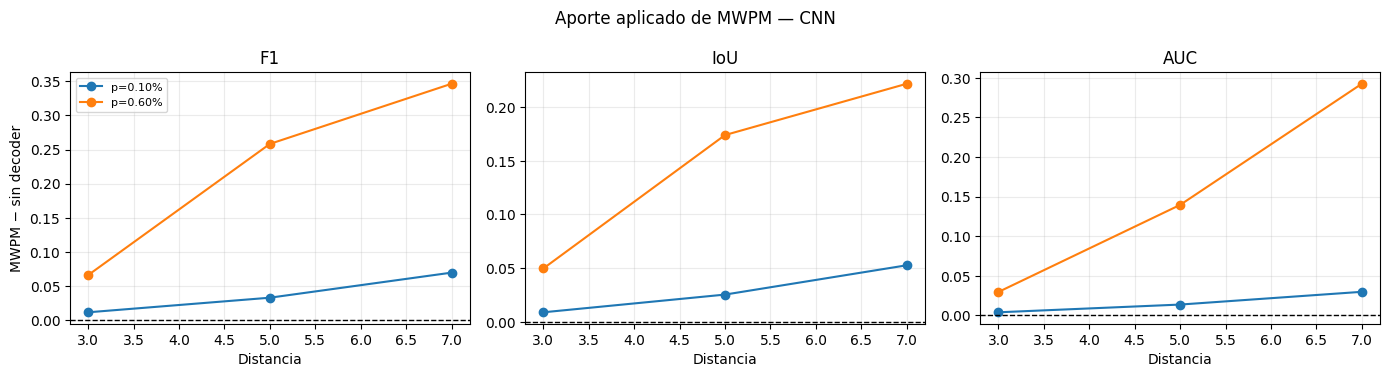

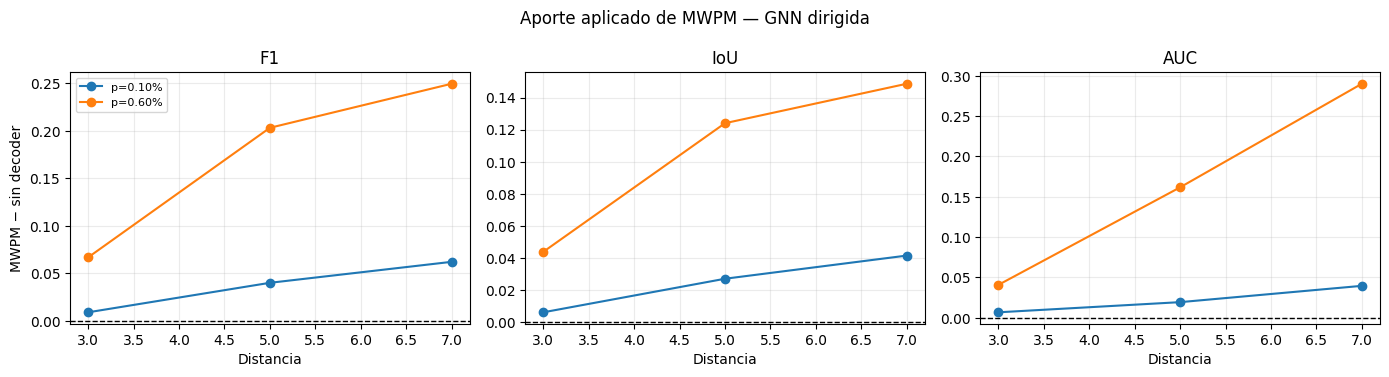

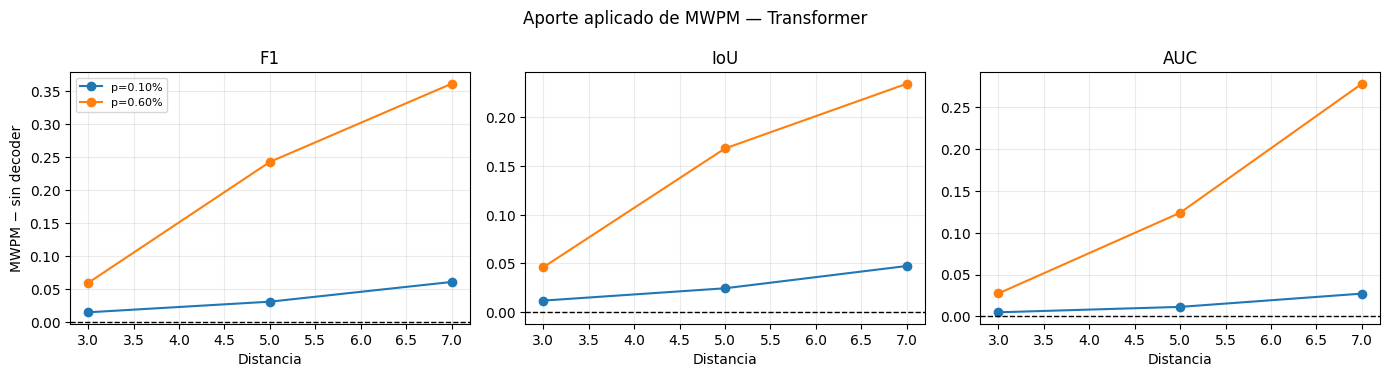

In [31]:
# 12.8 Aporte aplicado: diferencia MWPM menos el mismo circuito sin decodificar
metric_pivot_ext = application_ext_summary.pivot_table(
    index=['Modelo','p_físico','Distancia'], columns='Condición',
    values=['F1','IoU','AUC']
)

applied_contribution_ext = metric_pivot_ext.index.to_frame(index=False)
for metric in ['F1','IoU','AUC']:
    applied_contribution_ext[f'Aporte_{metric}_MWPM'] = (
        metric_pivot_ext[(metric,'Mismo circuito + MWPM')].to_numpy()
        - metric_pivot_ext[(metric,'Mismo circuito sin decoder')].to_numpy()
    )

display(applied_contribution_ext.style.format({
    'p_físico':'{:.3%}',
    'Aporte_F1_MWPM':'{:+.4f}',
    'Aporte_IoU_MWPM':'{:+.4f}',
    'Aporte_AUC_MWPM':'{:+.4f}',
}))

for model_name in applied_contribution_ext['Modelo'].unique():
    data = applied_contribution_ext[applied_contribution_ext['Modelo']==model_name]
    fig, axes = plt.subplots(1,3,figsize=(14,3.8))
    for ax, metric in zip(axes,['F1','IoU','AUC']):
        for p, group in data.groupby('p_físico'):
            ax.plot(group['Distancia'],group[f'Aporte_{metric}_MWPM'],marker='o',label=f'p={p:.2%}')
        ax.axhline(0,color='black',linestyle='--',linewidth=1)
        ax.set_title(metric);ax.set_xlabel('Distancia');ax.grid(alpha=.25)
    axes[0].set_ylabel('MWPM − sin decoder'); axes[0].legend(fontsize=8)
    fig.suptitle(f'Aporte aplicado de MWPM — {model_name}')
    plt.tight_layout();plt.show()


Configuración del análisis
--------------------------
Ruido físico: 0.600%
Distancia: 7
Número de semillas: 5
Shots por semilla: 20,000
Muestras válidas para AUC: 62
Corridas de prueba representadas: 6

Tasas de error del circuito


,Semilla,LER_sin_decodificar,LER_MWPM
0,42026,37.840%,2.315%
1,42027,37.915%,2.370%
2,42028,37.910%,2.505%
3,42029,38.050%,2.255%
4,42030,38.430%,2.390%


,Modelo,Condición,N_corridas,AUC_medio,Desviación_estándar,Error_estándar,IC95_inferior,IC95_superior
0,CA,Con errores,6,0.572,0.020,0.008,0.556,0.588
1,CNN,Con errores,6,0.678,0.012,0.005,0.668,0.687
2,GNN,Con errores,6,0.642,0.015,0.006,0.630,0.653
3,Transformer,Con errores,6,0.608,0.105,0.043,0.523,0.692
4,CA,Sin errores,6,0.971,0.006,0.002,0.967,0.976
5,CNN,Sin errores,6,0.979,0.009,0.004,0.972,0.986
6,GNN,Sin errores,6,0.947,0.034,0.014,0.920,0.974
7,Transformer,Sin errores,6,0.850,0.201,0.082,0.690,1.000


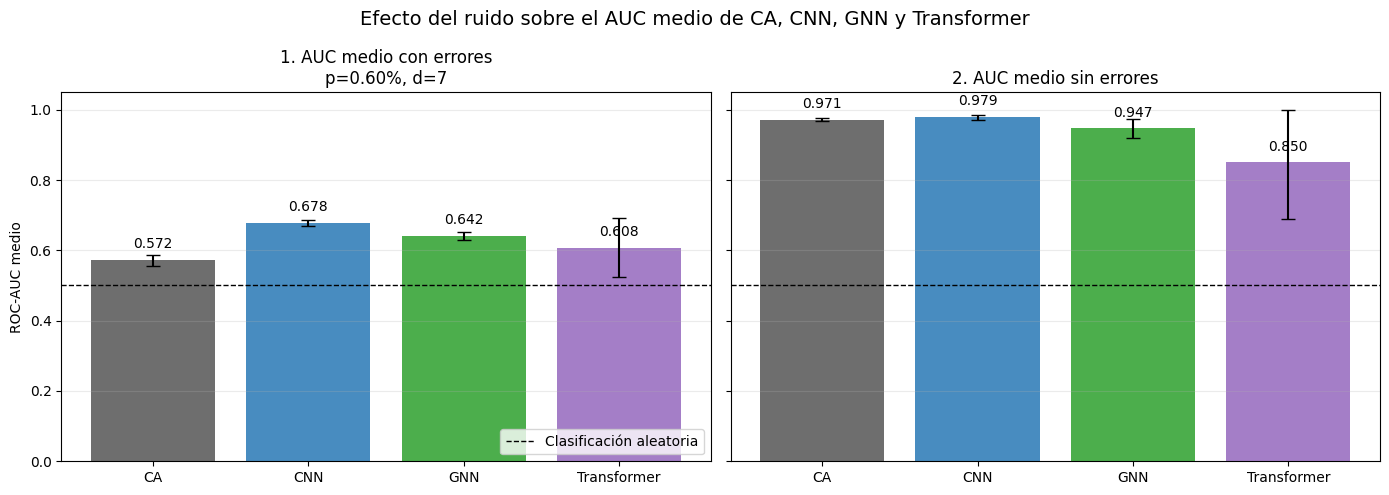

Condición,Con errores,Sin errores,Pérdida_por_error
Modelo,,,
CA,0.572,0.971,0.399
CNN,0.678,0.979,0.301
GNN,0.642,0.947,0.305
Transformer,0.608,0.850,0.242


Archivos creados:
- auc_modelos_con_y_sin_errores_por_muestra.csv
- auc_modelos_con_y_sin_errores_por_corrida.csv
- auc_modelos_con_y_sin_errores_resumen.csv


In [32]:
# ============================================================
# AUC MEDIO:
# 1. CA, CNN, GNN Y TRANSFORMER CON ERRORES
# 2. CA, CNN, GNN Y TRANSFORMER SIN ERRORES
#
# Requiere ejecutar previamente las secciones 12.1 a 12.7
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score


# ------------------------------------------------------------
# 1. Configuración editable
# ------------------------------------------------------------

P_RUIDO_AUC = 0.006       # 0,6 %
DISTANCIA_AUC = 7

# Usar todas las semillas configuradas
SEMILLAS_AUC = SEEDS_EXT

# Para una prueba rápida puede utilizar:
# SEMILLAS_AUC = SEEDS_EXT[:2]

if DISTANCIA_AUC not in QEC_EXT.distances:
    raise ValueError(
        f"DISTANCIA_AUC debe pertenecer "
        f"a {QEC_EXT.distances}."
    )

print("Configuración del análisis")
print("--------------------------")
print(
    "Ruido físico:",
    f"{P_RUIDO_AUC:.3%}",
)
print(
    "Distancia:",
    DISTANCIA_AUC,
)
print(
    "Número de semillas:",
    len(SEMILLAS_AUC),
)
print(
    "Shots por semilla:",
    f"{SHOTS_EXT:,}",
)


# ------------------------------------------------------------
# 2. Seleccionar muestras con ambas clases
# ------------------------------------------------------------

positive_counts_auc = Yte.reshape(
    len(Yte),
    -1,
).sum(axis=1)

VALID_SAMPLES_AUC = np.where(
    (positive_counts_auc > 0)
    & (
        positive_counts_auc
        < cfg.grid * cfg.grid
    )
)[0]

if len(VALID_SAMPLES_AUC) == 0:
    raise ValueError(
        "No existen muestras de prueba "
        "con ambas clases."
    )

print(
    "Muestras válidas para AUC:",
    len(VALID_SAMPLES_AUC),
)

print(
    "Corridas de prueba representadas:",
    len(
        np.unique(
            VALID_SAMPLES_AUC
            // cfg.steps
        )
    ),
)


# ------------------------------------------------------------
# 3. Probabilidades ideales de cada modelo
# ------------------------------------------------------------

# Probabilidad mecanística del autómata celular
if "pca_te" in globals():

    probability_ca_auc = pca_te.astype(
        np.float32
    )

else:

    probability_ca_auc = ca_probability(
        Xte
    ).astype(np.float32)

# Cuantización de 8 bits para todos los componentes
# De esta manera todos atraviesan la misma representación.
PROBABILIDADES_IDEALES_AUC = {
    "CA": dequantize_ext(
        quantize_ext(
            probability_ca_auc,
            bits=QEC_EXT.q_bits,
        )
    ),
    "CNN": dequantize_ext(
        quantize_ext(
            prob_test_ext["CNN"],
            bits=QEC_EXT.q_bits,
        )
    ),
    "GNN": dequantize_ext(
        quantize_ext(
            prob_test_ext["GNN dirigida"],
            bits=QEC_EXT.q_bits,
        )
    ),
    "Transformer": dequantize_ext(
        quantize_ext(
            prob_test_ext["Transformer"],
            bits=QEC_EXT.q_bits,
        )
    ),
}


# ------------------------------------------------------------
# 4. AUC sin errores
# ------------------------------------------------------------

rows_auc = []

for modelo, probability_map in (
    PROBABILIDADES_IDEALES_AUC.items()
):

    for sample_idx in VALID_SAMPLES_AUC:

        y_true = (
            Yte[sample_idx]
            .ravel()
            .astype(np.uint8)
        )

        y_score = (
            probability_map[sample_idx]
            .ravel()
        )

        auc_sample = roc_auc_score(
            y_true,
            y_score,
        )

        rows_auc.append({
            "Modelo": modelo,
            "Condición": "Sin errores",
            "Semilla": np.nan,
            "Corrida_test": (
                sample_idx // cfg.steps
            ) + 1,
            "Paso": (
                sample_idx % cfg.steps
            ) + 1,
            "Muestra": sample_idx,
            "AUC": auc_sample,
        })


# ------------------------------------------------------------
# 5. AUC con errores del mismo circuito sin decodificación
# ------------------------------------------------------------

ler_rows_auc = []

for seed in SEMILLAS_AUC:

    trial_auc = surface_trial_paired_ext(
        distance=DISTANCIA_AUC,
        p=P_RUIDO_AUC,
        shots=SHOTS_EXT,
        seed=seed,
        return_streams=True,
    )

    ler_rows_auc.append({
        "Semilla": seed,
        "LER_sin_decodificar":
            trial_auc[
                "LER_sin_decodificar"
            ],
        "LER_MWPM":
            trial_auc["LER_MWPM"],
    })

    for model_position, (
        modelo,
        probability_map,
    ) in enumerate(
        PROBABILIDADES_IDEALES_AUC.items()
    ):

        bits = quantize_ext(
            probability_map,
            bits=QEC_EXT.q_bits,
        )

        flat = bits.reshape(-1)

        error_stream = repeat_stream_ext(
            trial_auc[
                "stream_sin_decodificar"
            ],
            flat.size,
            seed
            + DISTANCIA_AUC * 100
            + int(
                P_RUIDO_AUC
                * 1_000_000
            ),
        )

        probability_with_errors = (
            dequantize_ext(
                (
                    flat
                    ^ error_stream
                ).reshape(
                    bits.shape
                )
            )
        )

        for sample_idx in VALID_SAMPLES_AUC:

            y_true = (
                Yte[sample_idx]
                .ravel()
                .astype(np.uint8)
            )

            y_score = (
                probability_with_errors[
                    sample_idx
                ]
                .ravel()
            )

            auc_sample = roc_auc_score(
                y_true,
                y_score,
            )

            rows_auc.append({
                "Modelo": modelo,
                "Condición": "Con errores",
                "Semilla": seed,
                "Corrida_test": (
                    sample_idx
                    // cfg.steps
                ) + 1,
                "Paso": (
                    sample_idx
                    % cfg.steps
                ) + 1,
                "Muestra": sample_idx,
                "AUC": auc_sample,
            })

auc_por_muestra = pd.DataFrame(
    rows_auc
)

ler_auc = pd.DataFrame(
    ler_rows_auc
)

print("\nTasas de error del circuito")

display(
    ler_auc.style.format({
        "LER_sin_decodificar": "{:.3%}",
        "LER_MWPM": "{:.3%}",
    })
)


# ------------------------------------------------------------
# 6. Promediar semillas y pasos dentro de cada corrida
# ------------------------------------------------------------

# Primero se promedian todas las semillas y pasos
# pertenecientes a la misma corrida.
auc_por_corrida = (
    auc_por_muestra
    .groupby(
        [
            "Modelo",
            "Condición",
            "Corrida_test",
        ],
        as_index=False,
    )
    .agg(
        AUC_corrida=("AUC", "mean"),
        N_evaluaciones=("AUC", "count"),
    )
)


# ------------------------------------------------------------
# 7. AUC medio e intervalo de confianza entre corridas
# ------------------------------------------------------------

summary_rows_auc = []

for (
    modelo,
    condicion,
), group in auc_por_corrida.groupby(
    [
        "Modelo",
        "Condición",
    ]
):

    values = group[
        "AUC_corrida"
    ].dropna().to_numpy(
        dtype=float
    )

    n = len(values)

    mean_auc = (
        values.mean()
        if n > 0
        else np.nan
    )

    std_auc = (
        values.std(ddof=1)
        if n > 1
        else np.nan
    )

    standard_error = (
        std_auc / np.sqrt(n)
        if n > 1
        else np.nan
    )

    lower = (
        max(
            0,
            mean_auc
            - 1.96
            * standard_error,
        )
        if np.isfinite(
            standard_error
        )
        else np.nan
    )

    upper = (
        min(
            1,
            mean_auc
            + 1.96
            * standard_error,
        )
        if np.isfinite(
            standard_error
        )
        else np.nan
    )

    summary_rows_auc.append({
        "Modelo": modelo,
        "Condición": condicion,
        "N_corridas": n,
        "AUC_medio": mean_auc,
        "Desviación_estándar": std_auc,
        "Error_estándar":
            standard_error,
        "IC95_inferior": lower,
        "IC95_superior": upper,
    })

resumen_auc_error = pd.DataFrame(
    summary_rows_auc
)

orden_modelos_auc = [
    "CA",
    "CNN",
    "GNN",
    "Transformer",
]

resumen_auc_error["Modelo"] = (
    pd.Categorical(
        resumen_auc_error["Modelo"],
        categories=orden_modelos_auc,
        ordered=True,
    )
)

resumen_auc_error = (
    resumen_auc_error
    .sort_values(
        [
            "Condición",
            "Modelo",
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    resumen_auc_error.style.format({
        "AUC_medio": "{:.3f}",
        "Desviación_estándar": "{:.3f}",
        "Error_estándar": "{:.3f}",
        "IC95_inferior": "{:.3f}",
        "IC95_superior": "{:.3f}",
    })
)


# ------------------------------------------------------------
# 8. Gráfico solicitado
# ------------------------------------------------------------

colors_auc = {
    "CA": "#555555",
    "CNN": "#2878b5",
    "GNN": "#2ca02c",
    "Transformer": "#9467bd",
}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    sharey=True,
)

conditions_auc = [
    "Con errores",
    "Sin errores",
]

titles_auc = [
    (
        "1. AUC medio con errores\n"
        f"p={P_RUIDO_AUC:.2%}, "
        f"d={DISTANCIA_AUC}"
    ),
    "2. AUC medio sin errores",
]

x = np.arange(
    len(orden_modelos_auc)
)

for ax, condition, title in zip(
    axes,
    conditions_auc,
    titles_auc,
):

    data = (
        resumen_auc_error[
            resumen_auc_error[
                "Condición"
            ] == condition
        ]
        .set_index("Modelo")
        .reindex(
            orden_modelos_auc
        )
    )

    means = data[
        "AUC_medio"
    ].to_numpy(
        dtype=float
    )

    lower = data[
        "IC95_inferior"
    ].to_numpy(
        dtype=float
    )

    upper = data[
        "IC95_superior"
    ].to_numpy(
        dtype=float
    )

    error_bars = np.vstack([
        means - lower,
        upper - means,
    ])

    bars = ax.bar(
        x,
        means,
        color=[
            colors_auc[m]
            for m in orden_modelos_auc
        ],
        alpha=0.85,
        yerr=error_bars,
        capsize=5,
    )

    ax.axhline(
        0.5,
        color="black",
        linestyle="--",
        linewidth=1,
        label="Clasificación aleatoria",
    )

    ax.set_xticks(
        x
    )

    ax.set_xticklabels(
        orden_modelos_auc
    )

    ax.set_title(
        title
    )

    ax.set_ylim(
        0,
        1.05,
    )

    ax.grid(
        axis="y",
        alpha=0.25,
    )

    for bar, value in zip(
        bars,
        means,
    ):

        if np.isfinite(value):

            ax.text(
                bar.get_x()
                + bar.get_width() / 2,
                value + 0.025,
                f"{value:.3f}",
                ha="center",
                va="bottom",
            )

axes[0].set_ylabel(
    "ROC-AUC medio"
)

axes[0].legend(
    loc="lower right"
)

fig.suptitle(
    "Efecto del ruido sobre el AUC medio de "
    "CA, CNN, GNN y Transformer",
    fontsize=14,
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 9. Tabla compacta comparativa
# ------------------------------------------------------------

tabla_auc_comparativa = (
    resumen_auc_error
    .pivot(
        index="Modelo",
        columns="Condición",
        values="AUC_medio",
    )
    .reindex(
        orden_modelos_auc
    )
)

tabla_auc_comparativa[
    "Pérdida_por_error"
] = (
    tabla_auc_comparativa[
        "Sin errores"
    ]
    - tabla_auc_comparativa[
        "Con errores"
    ]
)

display(
    tabla_auc_comparativa.style.format(
        "{:.3f}"
    )
)


# ------------------------------------------------------------
# 10. Exportar resultados
# ------------------------------------------------------------

auc_por_muestra.to_csv(
    "auc_modelos_con_y_sin_errores_por_muestra.csv",
    index=False,
)

auc_por_corrida.to_csv(
    "auc_modelos_con_y_sin_errores_por_corrida.csv",
    index=False,
)

resumen_auc_error.to_csv(
    "auc_modelos_con_y_sin_errores_resumen.csv",
    index=False,
)

print(
    "Archivos creados:"
)

print(
    "- auc_modelos_con_y_sin_errores_por_muestra.csv"
)

print(
    "- auc_modelos_con_y_sin_errores_por_corrida.csv"
)

print(
    "- auc_modelos_con_y_sin_errores_resumen.csv"
)

In [33]:
# 12.9 Exportar únicamente los resultados de la extensión
qec_ext_runs.to_csv('qec_ext_corridas_por_semilla.csv', index=False)
qec_ext_summary.to_csv('qec_ext_comparacion_equitativa.csv', index=False)
quantization_control_ext.to_csv('qec_ext_control_cuantizacion_8bit.csv', index=False)
application_ext_runs.to_csv('qec_ext_aplicacion_modelos_corridas.csv', index=False)
application_ext_summary.to_csv('qec_ext_aplicacion_modelos_resumen.csv', index=False)
applied_contribution_ext.to_csv('qec_ext_aporte_mwpm.csv', index=False)

print('Archivos de la extensión creados sin modificar las exportaciones anteriores.')


Archivos de la extensión creados sin modificar las exportaciones anteriores.


### Interpretación final de la extensión

1. Primero verifique si `MWPM_aporta` es verdadero al comparar el mismo circuito.
2. Luego examine si la distancia 7 reduce la LER frente a 5 y 3.
3. Finalmente evalúe si `Aporte_F1_MWPM`, `Aporte_IoU_MWPM` y `Aporte_AUC_MWPM` son positivos.
4. Una mejora en el circuito no garantiza automáticamente una mejora visible en las métricas del incendio, especialmente si el modelo ya es robusto a pequeñas perturbaciones.
5. Para resultados publicables, cambie `QEC_EXT.mode` a `PUBLICACION` y ejecute nuevamente desde la sección 12.1.


## 13. Evaluación multimuestra y multisemilla

Esta sección complementa las métricas globales con una evaluación sobre **todas las muestras de prueba que contienen ambas clases**. Los resultados se calculan por paso, pero los intervalos se construyen a partir de promedios por corrida y semilla, reduciendo la pseudorreplicación temporal. También se contabilizan por separado los estados sin frente activo para evaluar falsas alarmas.


In [34]:
# 13.1 Inventario de muestras de prueba
positive_counts_multi = Yte.reshape(len(Yte), -1).sum(axis=1)

ACTIVE_SAMPLES_MULTI = np.where(
    (positive_counts_multi > 0)
    & (positive_counts_multi < cfg.grid*cfg.grid)
)[0]

EXTINGUISHED_SAMPLES_MULTI = np.where(
    positive_counts_multi == 0
)[0]

sample_inventory_multi = pd.DataFrame({
    'Tipo':['Frente activo (dos clases)','Sin nuevo frente','Total'],
    'N_muestras':[len(ACTIVE_SAMPLES_MULTI),len(EXTINGUISHED_SAMPLES_MULTI),len(Yte)],
})
display(sample_inventory_multi)

if len(ACTIVE_SAMPLES_MULTI) == 0:
    raise ValueError('No existen muestras activas con ambas clases; ajuste la propagación CA.')

print('Corridas test representadas en muestras activas:',
      len(np.unique(ACTIVE_SAMPLES_MULTI//cfg.steps)))


,Tipo,N_muestras
0,Frente activo (dos clases),62
1,Sin nuevo frente,34
2,Total,96


Corridas test representadas en muestras activas: 6


In [35]:
# 13.2 Evaluación de todas las muestras activas, semillas y distancias
# Se reutilizan las probabilidades 8-bit y los umbrales calibrados en entrenamiento.
multi_rows = []
extinguished_rows = []

model_payload_multi = {}
for model_name, p_ideal in prob_test_ext.items():
    bits = quantize_ext(p_ideal)
    model_payload_multi[model_name] = {
        'bits':bits,
        'flat':bits.reshape(-1),
        'threshold':thresholds_8bit_ext[model_name],
        'ideal':p_ideal,
    }

for p in QEC_EXT.p_application:
    for distance in QEC_EXT.distances:
        for seed in SEEDS_EXT:
            trial = surface_trial_paired_ext(
                distance=distance, p=p, shots=SHOTS_EXT,
                seed=seed, return_streams=True,
            )

            for model_name, payload in model_payload_multi.items():
                bits = payload['bits']; flat = payload['flat']
                threshold = payload['threshold']
                stream_seed = seed + distance*100 + int(p*1_000_000)

                flips_no = repeat_stream_ext(
                    trial['stream_sin_decodificar'], flat.size, stream_seed)
                flips_mwpm = repeat_stream_ext(
                    trial['stream_MWPM'], flat.size, stream_seed)

                probability_maps = {
                    'Sin decodificación': dequantize_ext(
                        (flat^flips_no).reshape(bits.shape)),
                    'Código de superficie + MWPM': dequantize_ext(
                        (flat^flips_mwpm).reshape(bits.shape)),
                }

                for condition, probability_map in probability_maps.items():
                    for sample_idx in ACTIVE_SAMPLES_MULTI:
                        y_true = Yte[sample_idx].ravel().astype(np.uint8)
                        y_score = probability_map[sample_idx].ravel()
                        y_pred = (y_score>=threshold).astype(np.uint8)
                        metrics_sample = met(y_true,y_pred)
                        multi_rows.append({
                            'Modelo':model_name,'p_físico':p,'Distancia':distance,
                            'Semilla':seed,'Condición':condition,
                            'Corrida_test':int(sample_idx//cfg.steps)+1,
                            'Paso':int(sample_idx%cfg.steps)+1,
                            'Muestra':int(sample_idx),
                            'Positivos_CA':int(y_true.sum()),
                            **metrics_sample,
                            'AUC':roc_auc_score(y_true,y_score),
                            'TP':int(np.sum((y_true==1)&(y_pred==1))),
                            'FP':int(np.sum((y_true==0)&(y_pred==1))),
                            'FN':int(np.sum((y_true==1)&(y_pred==0))),
                        })

                    # Estados extinguidos: la métrica relevante es falsa alarma.
                    for sample_idx in EXTINGUISHED_SAMPLES_MULTI:
                        y_pred = (probability_map[sample_idx].ravel()>=threshold)
                        extinguished_rows.append({
                            'Modelo':model_name,'p_físico':p,'Distancia':distance,
                            'Semilla':seed,'Condición':condition,
                            'Corrida_test':int(sample_idx//cfg.steps)+1,
                            'Paso':int(sample_idx%cfg.steps)+1,
                            'Falsos_positivos':int(y_pred.sum()),
                            'Alerta_falsa':bool(y_pred.any()),
                        })

metrics_multisample_runs = pd.DataFrame(multi_rows)
false_alarm_runs = pd.DataFrame(extinguished_rows)

print('Filas de evaluación activa:',len(metrics_multisample_runs))
print('Filas de evaluación sin frente:',len(false_alarm_runs))
display(metrics_multisample_runs.head())


Filas de evaluación activa: 11160
Filas de evaluación sin frente: 6120


,Modelo,p_físico,Distancia,Semilla,Condición,Corrida_test,Paso,Muestra,Positivos_CA,F1,IoU,Balanced_accuracy,Precision,Recall,AUC,TP,FP,FN
0,CNN,0.001,3,42026,Sin decodificación,1,1,0,6,0.181818,0.100000,0.578257,0.200000,0.166667,0.943739,1,4,5
1,CNN,0.001,3,42026,Sin decodificación,1,2,1,7,0.500000,0.333333,0.846965,0.384615,0.714286,0.973101,5,8,2
2,CNN,0.001,3,42026,Sin decodificación,1,3,2,8,0.428571,0.272727,0.857143,0.300000,0.750000,0.972258,6,14,2
3,CNN,0.001,3,42026,Sin decodificación,1,4,3,8,0.518519,0.350000,0.922194,0.368421,0.875000,0.957111,7,12,1
4,CNN,0.001,3,42026,Sin decodificación,1,5,4,4,0.333333,0.200000,0.979798,0.200000,1.000000,0.985795,4,16,0


In [36]:
# 13.3 Resumen robusto: primero promediar pasos dentro de corrida y semilla
metric_names_multi = ['F1','IoU','Balanced_accuracy','Precision','Recall','AUC']

cluster_metrics_multi = (
    metrics_multisample_runs
    .groupby(['Modelo','p_físico','Distancia','Condición','Semilla','Corrida_test'],as_index=False)
    [metric_names_multi].mean()
)

summary_rows_multi = []
group_cols_multi = ['Modelo','p_físico','Distancia','Condición']
for keys, group in cluster_metrics_multi.groupby(group_cols_multi):
    row = dict(zip(group_cols_multi,keys))
    row['N_clusters'] = len(group)
    row['N_semillas'] = group['Semilla'].nunique()
    row['N_corridas'] = group['Corrida_test'].nunique()
    for metric in metric_names_multi:
        values = group[metric].dropna().to_numpy(float)
        mean = values.mean() if len(values) else np.nan
        std = values.std(ddof=1) if len(values)>1 else np.nan
        se = std/np.sqrt(len(values)) if len(values)>1 else np.nan
        row[f'{metric}_medio'] = mean
        row[f'{metric}_std'] = std
        row[f'{metric}_IC95_inf'] = max(0,mean-1.96*se) if np.isfinite(se) else np.nan
        row[f'{metric}_IC95_sup'] = min(1,mean+1.96*se) if np.isfinite(se) else np.nan
    summary_rows_multi.append(row)

summary_multisample = pd.DataFrame(summary_rows_multi)
display(summary_multisample.style.format({
    'p_físico':'{:.3%}',
    **{c:'{:.3f}' for c in summary_multisample.columns
       if any(c.startswith(m+'_') for m in metric_names_multi)}
}))


,Modelo,p_físico,Distancia,Condición,N_clusters,N_semillas,N_corridas,F1_medio,F1_std,F1_IC95_inf,F1_IC95_sup,IoU_medio,IoU_std,IoU_IC95_inf,IoU_IC95_sup,Balanced_accuracy_medio,Balanced_accuracy_std,Balanced_accuracy_IC95_inf,Balanced_accuracy_IC95_sup,Precision_medio,Precision_std,Precision_IC95_inf,Precision_IC95_sup,Recall_medio,Recall_std,Recall_IC95_inf,Recall_IC95_sup,AUC_medio,AUC_std,AUC_IC95_inf,AUC_IC95_sup
0,CNN,0.100%,3,Código de superficie + MWPM,30,5,6,0.333,0.156,0.277,0.388,0.217,0.103,0.180,0.253,0.840,0.162,0.782,0.898,0.231,0.109,0.191,0.270,0.706,0.326,0.590,0.823,0.979,0.008,0.976,0.982
1,CNN,0.100%,3,Sin decodificación,30,5,6,0.323,0.152,0.269,0.378,0.210,0.100,0.174,0.245,0.820,0.153,0.765,0.875,0.227,0.109,0.188,0.266,0.665,0.309,0.554,0.775,0.974,0.011,0.970,0.978
2,CNN,0.100%,5,Código de superficie + MWPM,30,5,6,0.332,0.156,0.276,0.388,0.216,0.103,0.179,0.253,0.840,0.162,0.782,0.898,0.230,0.110,0.191,0.269,0.707,0.327,0.590,0.824,0.979,0.008,0.976,0.982
3,CNN,0.100%,5,Sin decodificación,30,5,6,0.307,0.148,0.255,0.360,0.198,0.096,0.164,0.233,0.786,0.144,0.735,0.837,0.221,0.107,0.182,0.259,0.595,0.290,0.491,0.699,0.968,0.013,0.963,0.972
4,CNN,0.100%,7,Código de superficie + MWPM,30,5,6,0.333,0.156,0.277,0.389,0.217,0.103,0.180,0.253,0.841,0.162,0.783,0.899,0.231,0.109,0.191,0.270,0.707,0.327,0.591,0.824,0.979,0.008,0.976,0.982
5,CNN,0.100%,7,Sin decodificación,30,5,6,0.282,0.137,0.233,0.331,0.182,0.093,0.149,0.215,0.751,0.128,0.705,0.797,0.209,0.105,0.172,0.247,0.525,0.257,0.433,0.617,0.954,0.021,0.946,0.962
6,CNN,0.600%,3,Código de superficie + MWPM,30,5,6,0.327,0.154,0.272,0.382,0.212,0.102,0.176,0.249,0.822,0.154,0.766,0.877,0.230,0.111,0.191,0.270,0.668,0.311,0.557,0.779,0.975,0.009,0.971,0.978
7,CNN,0.600%,3,Sin decodificación,30,5,6,0.279,0.116,0.237,0.320,0.175,0.076,0.147,0.202,0.765,0.121,0.721,0.808,0.204,0.091,0.172,0.237,0.551,0.242,0.465,0.638,0.946,0.027,0.937,0.956
8,CNN,0.600%,5,Código de superficie + MWPM,30,5,6,0.318,0.154,0.263,0.374,0.206,0.101,0.170,0.243,0.813,0.153,0.758,0.867,0.224,0.109,0.184,0.263,0.650,0.309,0.539,0.760,0.974,0.009,0.971,0.978
9,CNN,0.600%,5,Sin decodificación,30,5,6,0.134,0.070,0.109,0.159,0.076,0.041,0.062,0.091,0.647,0.096,0.613,0.681,0.092,0.051,0.074,0.110,0.326,0.191,0.258,0.395,0.834,0.074,0.807,0.860


In [37]:
# 13.4 Aporte medio de MWPM frente al mismo circuito sin decodificar
aporte_rows_multi = []
for (model_name,p,distance), group in summary_multisample.groupby(
    ['Modelo','p_físico','Distancia']):
    indexed = group.set_index('Condición')
    no_label = 'Sin decodificación'
    mwpm_label = 'Código de superficie + MWPM'
    if no_label not in indexed.index or mwpm_label not in indexed.index:
        continue
    row = {'Modelo':model_name,'p_físico':p,'Distancia':distance}
    for metric in metric_names_multi:
        row[f'Aporte_{metric}'] = (
            indexed.loc[mwpm_label,f'{metric}_medio']
            - indexed.loc[no_label,f'{metric}_medio'])
    aporte_rows_multi.append(row)

aporte_multisample = pd.DataFrame(aporte_rows_multi)
display(aporte_multisample.style.format({
    'p_físico':'{:.3%}',
    **{c:'{:+.3f}' for c in aporte_multisample.columns if c.startswith('Aporte_')}
}))


,Modelo,p_físico,Distancia,Aporte_F1,Aporte_IoU,Aporte_Balanced_accuracy,Aporte_Precision,Aporte_Recall,Aporte_AUC
0,CNN,0.100%,3,+0.009,+0.007,+0.020,+0.003,+0.042,+0.005
1,CNN,0.100%,5,+0.024,+0.018,+0.054,+0.009,+0.112,+0.011
2,CNN,0.100%,7,+0.051,+0.035,+0.089,+0.021,+0.183,+0.025
3,CNN,0.600%,3,+0.049,+0.038,+0.057,+0.026,+0.117,+0.028
4,CNN,0.600%,5,+0.185,+0.130,+0.166,+0.132,+0.323,+0.141
5,CNN,0.600%,7,+0.267,+0.179,+0.258,+0.193,+0.478,+0.297
6,GNN dirigida,0.100%,3,+0.011,+0.009,+0.026,+0.008,+0.053,+0.006
7,GNN dirigida,0.100%,5,+0.030,+0.023,+0.035,+0.023,+0.070,+0.015
8,GNN dirigida,0.100%,7,+0.038,+0.030,+0.036,+0.030,+0.071,+0.032
9,GNN dirigida,0.600%,3,+0.045,+0.034,+0.042,+0.036,+0.081,+0.039


In [38]:
# 13.5 Falsas alarmas en estados sin nuevo frente
if len(false_alarm_runs):
    false_alarm_summary = (
        false_alarm_runs
        .groupby(['Modelo','p_físico','Distancia','Condición'],as_index=False)
        .agg(
            N_estados=('Alerta_falsa','count'),
            Tasa_estados_con_alerta_falsa=('Alerta_falsa','mean'),
            FP_medio_por_estado=('Falsos_positivos','mean'),
            FP_total=('Falsos_positivos','sum'),
        )
    )
    display(false_alarm_summary.style.format({
        'p_físico':'{:.3%}',
        'Tasa_estados_con_alerta_falsa':'{:.1%}',
        'FP_medio_por_estado':'{:.2f}',
    }))
else:
    false_alarm_summary = pd.DataFrame()
    print('No existen estados extinguidos en esta ejecución.')


,Modelo,p_físico,Distancia,Condición,N_estados,Tasa_estados_con_alerta_falsa,FP_medio_por_estado,FP_total
0,CNN,0.100%,3,Código de superficie + MWPM,170,11.8%,0.61,104
1,CNN,0.100%,3,Sin decodificación,170,17.1%,0.64,108
2,CNN,0.100%,5,Código de superficie + MWPM,170,11.8%,0.61,104
3,CNN,0.100%,5,Sin decodificación,170,32.9%,0.79,134
4,CNN,0.100%,7,Código de superficie + MWPM,170,11.8%,0.62,105
5,CNN,0.100%,7,Sin decodificación,170,58.8%,1.22,207
6,CNN,0.600%,3,Código de superficie + MWPM,170,19.4%,0.64,109
7,CNN,0.600%,3,Sin decodificación,170,71.2%,1.51,257
8,CNN,0.600%,5,Código de superficie + MWPM,170,18.2%,0.64,109
9,CNN,0.600%,5,Sin decodificación,170,100.0%,8.56,1455


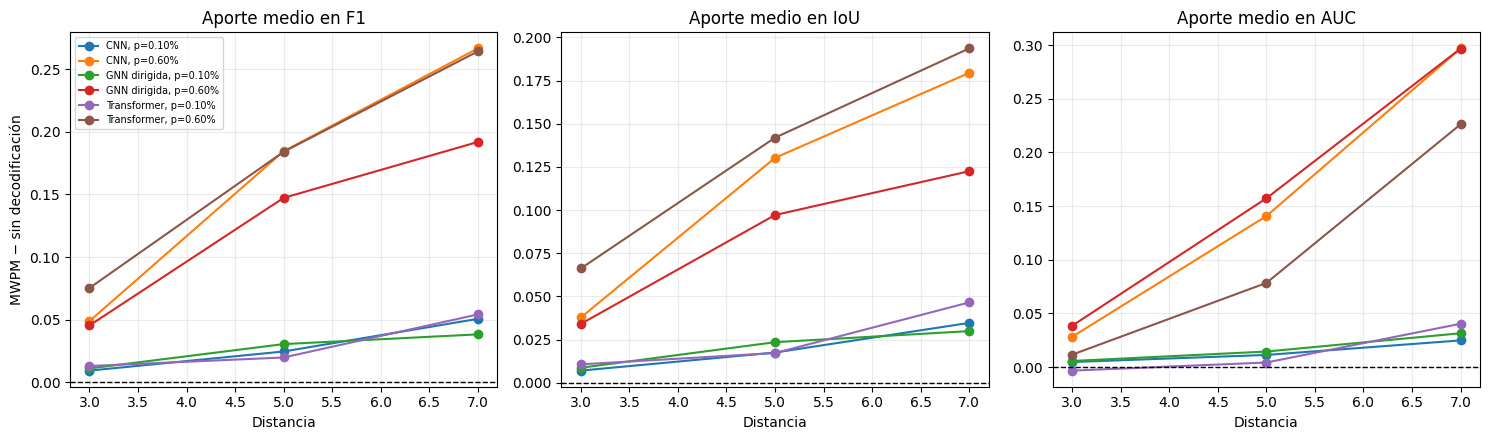

In [39]:
# 13.6 Visualización del aporte agregado
fig,axes=plt.subplots(1,3,figsize=(15,4.5))
for ax,metric in zip(axes,['F1','IoU','AUC']):
    for (model_name,p),group in aporte_multisample.groupby(['Modelo','p_físico']):
        group=group.sort_values('Distancia')
        ax.plot(group['Distancia'],group[f'Aporte_{metric}'],marker='o',
                label=f'{model_name}, p={p:.2%}')
    ax.axhline(0,color='black',linestyle='--',linewidth=1)
    ax.set_title(f'Aporte medio en {metric}')
    ax.set_xlabel('Distancia');ax.grid(alpha=.25)
axes[0].set_ylabel('MWPM − sin decodificación')
axes[0].legend(fontsize=7)
plt.tight_layout();plt.show()


In [40]:
# 13.7 Exportación separada de la ampliación multimuestra
sample_inventory_multi.to_csv('multimuestra_inventario.csv',index=False)
metrics_multisample_runs.to_csv('multimuestra_metricas_por_paso.csv',index=False)
cluster_metrics_multi.to_csv('multimuestra_metricas_por_corrida_semilla.csv',index=False)
summary_multisample.to_csv('multimuestra_resumen_robusto.csv',index=False)
aporte_multisample.to_csv('multimuestra_aporte_mwpm.csv',index=False)
false_alarm_runs.to_csv('multimuestra_falsas_alarmas_detalle.csv',index=False)
false_alarm_summary.to_csv('multimuestra_falsas_alarmas_resumen.csv',index=False)

print('Resultados multimuestra exportados sin sobrescribir los archivos anteriores.')


Resultados multimuestra exportados sin sobrescribir los archivos anteriores.


### Criterios de interpretación de la versión robusta

- Una mejora se considera consistente cuando el aporte medio es positivo en varias semillas, corridas y distancias.
- Los intervalos se calculan sobre combinaciones corrida–semilla, no sobre cada paso como si fuera independiente.
- Los estados activos evalúan detección mediante F1, IoU y AUC; los estados extinguidos evalúan falsas alarmas.
- La configuración de esta copia utiliza 20 corridas CA, 20.000 shots y cinco semillas. La ejecución completa será considerablemente más lenta que la versión rápida.


# 14. Nueva orientación: aporte predictivo sobre CA y protección de índices espectrales

Esta extensión conserva íntegramente los experimentos anteriores y añade dos análisis independientes:

1. **Aporte de CNN, GNN y Transformer respecto de la regla CA**, medido sobre las mismas corridas de prueba mediante diferencias absolutas y relativas de F1, IoU, balanced accuracy, precisión, recall, AUC y AUC-PR.
2. **Aporte del código de superficie sobre los productos espectrales**, comparando índices ideales, degradados por el mismo circuito sin decodificación y recuperados mediante síndromes + MWPM.

La cadena causal evaluada es:

\[
\text{GeoTIFF}\rightarrow\text{NDVI/NDMI/NBR/combustible}
\rightarrow\text{canal cuántico simulado}\rightarrow\text{MWPM}
\rightarrow\text{CA y modelos}\rightarrow\text{predicción del frente}.
\]

**Alcance:** el código de superficie no extrae ni mejora matemáticamente los índices. Su aporte consiste en preservar su representación digital frente al ruido. En la arquitectura ya entrenada, NDVI normalizado, sequedad derivada de NDMI y combustible son entradas de los modelos. NBR se evalúa en el nivel espectral, pero no se atribuye a NBR una mejora predictiva porque todavía no es un canal de entrada.


## 14.1 Aporte de CNN, GNN y Transformer respecto de CA

El CA se utiliza como línea base mecanística. Las diferencias se calculan sobre el mismo conjunto de prueba. Una diferencia positiva indica mejora respecto del CA; para `Inferencia_s`, un valor positivo indica mayor costo computacional.


In [41]:
from sklearn.metrics import average_precision_score

def safe_auc_local(y, score):
    y = np.asarray(y).ravel().astype(np.uint8)
    score = np.asarray(score).ravel().astype(float)
    return roc_auc_score(y, score) if np.unique(y).size == 2 else np.nan

def safe_ap_local(y, score):
    y = np.asarray(y).ravel().astype(np.uint8)
    score = np.asarray(score).ravel().astype(float)
    return average_precision_score(y, score) if y.sum() > 0 else np.nan

# Probabilidades continuas sobre el mismo test.
comparison_probabilities = {'CA': pca_te}
comparison_predictions = {'CA': pred_ca}
comparison_thresholds = {'CA': tca}

for model_name, model in models.items():
    label = 'GNN' if model_name == 'GNN dirigida' else model_name
    p_train, _ = probabilities(model, Xtr)
    p_test, _ = probabilities(model, Xte)
    threshold = best_threshold(Ytr, p_train)
    comparison_probabilities[label] = p_test
    comparison_predictions[label] = (p_test >= threshold).astype(np.uint8)
    comparison_thresholds[label] = threshold

comparison_rows = []
for model_name in ['CA', 'CNN', 'GNN', 'Transformer']:
    p = comparison_probabilities[model_name]
    pred = comparison_predictions[model_name]
    comparison_rows.append({
        'Modelo': model_name,
        'Umbral': comparison_thresholds[model_name],
        **met(Yte, pred),
        'AUC': safe_auc_local(Yte, p),
        'AUC_PR': safe_ap_local(Yte, p),
    })

comparison_ca = pd.DataFrame(comparison_rows)
baseline_ca = comparison_ca.set_index('Modelo').loc['CA']
metricas_aporte = ['F1','IoU','Balanced_accuracy','Precision','Recall','AUC','AUC_PR']

aporte_rows = []
for _, row in comparison_ca[comparison_ca['Modelo'] != 'CA'].iterrows():
    result = {'Modelo': row['Modelo']}
    for metric in metricas_aporte:
        result[f'Delta_{metric}'] = row[metric] - baseline_ca[metric]
        result[f'Mejora_relativa_{metric}'] = (
            (row[metric] - baseline_ca[metric]) / baseline_ca[metric]
            if np.isfinite(baseline_ca[metric]) and abs(baseline_ca[metric]) > 1e-12
            else np.nan
        )
    aporte_rows.append(result)

aporte_sobre_ca = pd.DataFrame(aporte_rows)

print('Desempeño comparable sobre el mismo conjunto de prueba')
display(comparison_ca.style.format({
    'Umbral':'{:.3f}','F1':'{:.3f}','IoU':'{:.3f}',
    'Balanced_accuracy':'{:.3f}','Precision':'{:.3f}','Recall':'{:.3f}',
    'AUC':'{:.3f}','AUC_PR':'{:.3f}',
}))

print('Aporte absoluto y relativo respecto de CA')
display(aporte_sobre_ca.style.format({
    **{c:'{:+.3f}' for c in aporte_sobre_ca.columns if c.startswith('Delta_')},
    **{c:'{:+.1%}' for c in aporte_sobre_ca.columns if c.startswith('Mejora_relativa_')},
}))


Desempeño comparable sobre el mismo conjunto de prueba


,Modelo,Umbral,F1,IoU,Balanced_accuracy,Precision,Recall,AUC,AUC_PR
0,CA,0.225,0.302,0.178,0.851,0.191,0.727,0.983,0.216
1,CNN,0.875,0.411,0.259,0.920,0.270,0.859,0.988,0.382
2,GNN,0.800,0.304,0.179,0.785,0.205,0.589,0.953,0.209
3,Transformer,0.900,0.429,0.273,0.851,0.307,0.715,0.971,0.355


Aporte absoluto y relativo respecto de CA


,Modelo,Delta_F1,Mejora_relativa_F1,Delta_IoU,Mejora_relativa_IoU,Delta_Balanced_accuracy,Mejora_relativa_Balanced_accuracy,Delta_Precision,Mejora_relativa_Precision,Delta_Recall,Mejora_relativa_Recall,Delta_AUC,Mejora_relativa_AUC,Delta_AUC_PR,Mejora_relativa_AUC_PR
0,CNN,+0.109,+36.2%,+0.081,+45.6%,+0.069,+8.1%,+0.080,+41.9%,+0.132,+18.1%,+0.005,+0.5%,+0.166,+76.8%
1,GNN,+0.002,+0.6%,+0.001,+0.7%,-0.066,-7.7%,+0.014,+7.4%,-0.138,-19.0%,-0.030,-3.0%,-0.007,-3.1%
2,Transformer,+0.127,+42.1%,+0.095,+53.7%,-0.000,-0.0%,+0.116,+61.0%,-0.013,-1.7%,-0.011,-1.2%,+0.140,+64.7%


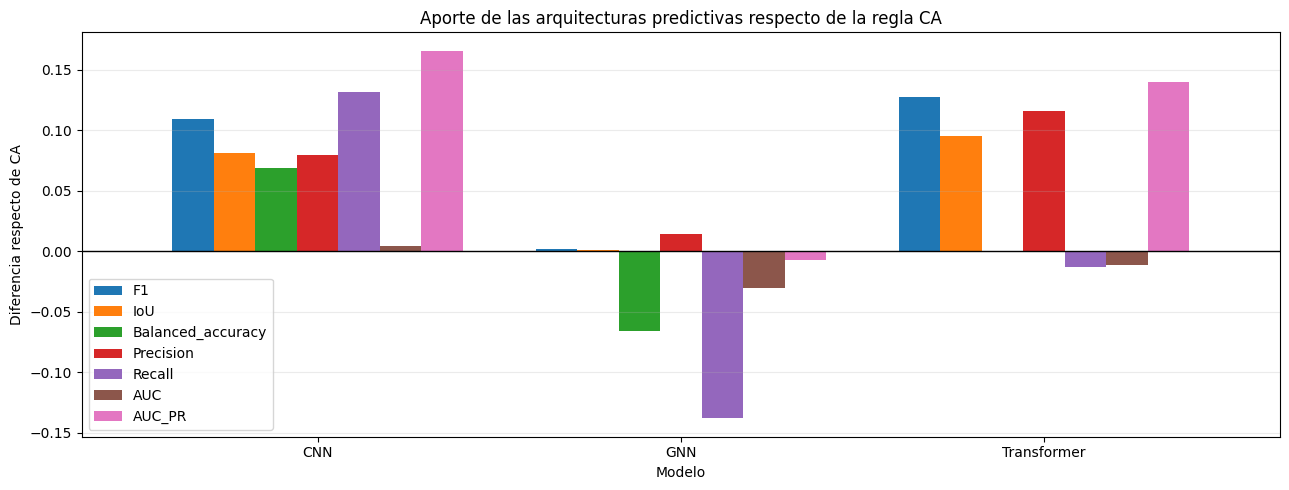

Archivos creados: comparacion_modelos_vs_CA.csv y aporte_modelos_sobre_CA.csv


In [42]:
# Resumen visual compacto del aporte absoluto sobre CA.
delta_plot = aporte_sobre_ca.set_index('Modelo')[
    [f'Delta_{m}' for m in ['F1','IoU','Balanced_accuracy','Precision','Recall','AUC','AUC_PR']]
].copy()
delta_plot.columns = [c.replace('Delta_','') for c in delta_plot.columns]

ax = delta_plot.plot(kind='bar', figsize=(13,5), width=.8)
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('Diferencia respecto de CA')
ax.set_title('Aporte de las arquitecturas predictivas respecto de la regla CA')
ax.grid(axis='y', alpha=.25)
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

comparison_ca.to_csv('comparacion_modelos_vs_CA.csv', index=False)
aporte_sobre_ca.to_csv('aporte_modelos_sobre_CA.csv', index=False)
print('Archivos creados: comparacion_modelos_vs_CA.csv y aporte_modelos_sobre_CA.csv')


## 14.2 Protección QEC de NDVI, NDMI, NBR y combustible

Los cuatro productos se normalizan a \([0,1]\), se cuantizan en 8 bits y se transmiten bajo tres condiciones:

- **Ideal cuantizada:** control sin errores.
- **Mismo circuito sin decodificación:** se ignoran los síndromes.
- **Código de superficie + MWPM:** se utilizan los síndromes para estimar la corrección lógica.

El diseño reutiliza las distancias, niveles de ruido, semillas y número de shots de la extensión robusta. Para mantener un tiempo manejable puede activarse `MODO_ESPECTRAL='RAPIDO'`.


In [43]:
# 14.2.1 Configuración y productos espectrales normalizados
MODO_ESPECTRAL = 'PUBLICACION'  # 'RAPIDO' para una comprobación breve

if MODO_ESPECTRAL.upper() == 'PUBLICACION':
    P_ESPECTRAL = tuple(QEC_EXT.p_application)
    DISTANCIAS_ESPECTRAL = tuple(QEC_EXT.distances)
    SEMILLAS_ESPECTRAL = tuple(SEEDS_EXT)
    SHOTS_ESPECTRAL = SHOTS_EXT
else:
    P_ESPECTRAL = (0.001, 0.006)
    DISTANCIAS_ESPECTRAL = (3, 7)
    SEMILLAS_ESPECTRAL = (QEC_EXT.seed, QEC_EXT.seed + 1)
    SHOTS_ESPECTRAL = 5_000

def normalize_fixed(a, mask):
    a = np.asarray(a, dtype=np.float32)
    values = a[mask & np.isfinite(a)]
    lo, hi = np.percentile(values, [2,98])
    normalized = np.clip((a-lo)/(hi-lo+1e-8), 0, 1).astype(np.float32)
    normalized[~mask] = 0
    return normalized, float(lo), float(hi)

ndvi_norm, ndvi_lo, ndvi_hi = normalize_fixed(ndvi, valid)
ndmi_norm, ndmi_lo, ndmi_hi = normalize_fixed(ndmi, valid)
nbr_norm, nbr_lo, nbr_hi = normalize_fixed(nbr, valid)

spectral_products = {
    'NDVI': ndvi_norm,
    'NDMI': ndmi_norm,
    'NBR': nbr_norm,
    'Combustible': fuel.astype(np.float32),
}

spectral_control = pd.DataFrame([
    {'Índice':name,'Mínimo':float(z[valid].min()),'Media':float(z[valid].mean()),
     'Máximo':float(z[valid].max()),'Bits':QEC_EXT.q_bits}
    for name,z in spectral_products.items()
])

print('Configuración espectral')
print('Modo:', MODO_ESPECTRAL)
print('Ruido físico:', P_ESPECTRAL)
print('Distancias:', DISTANCIAS_ESPECTRAL)
print('Semillas:', len(SEMILLAS_ESPECTRAL), '| shots:', f'{SHOTS_ESPECTRAL:,}')
display(spectral_control.style.format({'Mínimo':'{:.3f}','Media':'{:.3f}','Máximo':'{:.3f}'}))


Configuración espectral
Modo: PUBLICACION
Ruido físico: (0.001, 0.006)
Distancias: (3, 5, 7)
Semillas: 5 | shots: 20,000


,Índice,Mínimo,Media,Máximo,Bits
0,NDVI,0.000,0.478,1.000,8
1,NDMI,0.000,0.452,1.000,8
2,NBR,0.000,0.500,1.000,8
3,Combustible,0.000,0.604,0.997,8


In [44]:
# 14.2.2 Transmisión pareada y reconstrucción de productos espectrales
from sklearn.metrics import mean_absolute_error, mean_squared_error
from skimage.metrics import structural_similarity, peak_signal_noise_ratio

def spectral_quality(reference, reconstructed, mask):
    ref = np.asarray(reference, dtype=np.float32)
    rec = np.asarray(reconstructed, dtype=np.float32)
    rv, xv = ref[mask], rec[mask]
    corr = np.corrcoef(rv, xv)[0,1] if np.std(rv)>0 and np.std(xv)>0 else np.nan
    return {
        'MAE': mean_absolute_error(rv, xv),
        'RMSE': np.sqrt(mean_squared_error(rv, xv)),
        'Correlación': corr,
        'SSIM': structural_similarity(ref, rec, data_range=1.0),
        'PSNR_dB': peak_signal_noise_ratio(ref, rec, data_range=1.0),
    }

spectral_quality_rows = []
spectral_reconstructions = {}

for p_noise in P_ESPECTRAL:
    for distance in DISTANCIAS_ESPECTRAL:
        for seed in SEMILLAS_ESPECTRAL:
            trial = surface_trial_paired_ext(
                distance=distance, p=p_noise, shots=SHOTS_ESPECTRAL,
                seed=seed, return_streams=True,
            )
            condition_streams = {
                'Mismo circuito sin decodificación': trial['stream_sin_decodificar'],
                'Código de superficie + MWPM': trial['stream_MWPM'],
            }

            for product_id, (product_name, original) in enumerate(spectral_products.items()):
                ideal_bits = quantize_ext(original)
                ideal_quantized = dequantize_ext(ideal_bits)

                recon_by_condition = {'Ideal cuantizada': ideal_quantized}
                for condition, logical_stream in condition_streams.items():
                    stream_seed = seed + 1000*distance + int(p_noise*1_000_000) + 100_000*product_id
                    flips = repeat_stream_ext(logical_stream, ideal_bits.size, stream_seed)
                    reconstructed_bits = ideal_bits.reshape(-1) ^ flips
                    recon_by_condition[condition] = dequantize_ext(
                        reconstructed_bits.reshape(ideal_bits.shape))

                for condition, reconstructed in recon_by_condition.items():
                    spectral_quality_rows.append({
                        'Índice':product_name,'p_físico':p_noise,'Distancia':distance,
                        'Semilla':seed,'Condición':condition,
                        **spectral_quality(original, reconstructed, valid),
                    })
                    spectral_reconstructions[(product_name,p_noise,distance,seed,condition)] = reconstructed

spectral_quality_runs = pd.DataFrame(spectral_quality_rows)
spectral_quality_summary = (
    spectral_quality_runs
    .groupby(['Índice','p_físico','Distancia','Condición'],as_index=False)
    [['MAE','RMSE','Correlación','SSIM','PSNR_dB']].mean()
)

display(spectral_quality_summary.style.format({
    'p_físico':'{:.3%}','MAE':'{:.4f}','RMSE':'{:.4f}',
    'Correlación':'{:.4f}','SSIM':'{:.4f}','PSNR_dB':'{:.2f}',
}))


,Índice,p_físico,Distancia,Condición,MAE,RMSE,Correlación,SSIM,PSNR_dB
0,Combustible,0.100%,3,Código de superficie + MWPM,0.0017,0.0131,0.9974,0.9865,40.77
1,Combustible,0.100%,3,Ideal cuantizada,0.0010,0.0011,1.0000,0.9999,59.01
2,Combustible,0.100%,3,Mismo circuito sin decodificación,0.0244,0.0909,0.9228,0.7711,20.89
3,Combustible,0.100%,5,Código de superficie + MWPM,0.0010,0.0011,1.0000,0.9999,59.01
4,Combustible,0.100%,5,Ideal cuantizada,0.0010,0.0011,1.0000,0.9999,59.01
5,Combustible,0.100%,5,Mismo circuito sin decodificación,0.0507,0.1340,0.8393,0.6016,17.47
6,Combustible,0.100%,7,Código de superficie + MWPM,0.0010,0.0011,1.0000,0.9999,59.01
7,Combustible,0.100%,7,Ideal cuantizada,0.0010,0.0011,1.0000,0.9999,59.01
8,Combustible,0.100%,7,Mismo circuito sin decodificación,0.0917,0.1806,0.7263,0.4755,14.87
9,Combustible,0.600%,3,Código de superficie + MWPM,0.0305,0.1007,0.9046,0.7235,19.97


,Índice,p_físico,Distancia,Reducción_MAE,Reducción_RMSE,Ganancia_correlación,Ganancia_SSIM,Ganancia_PSNR_dB
0,Combustible,0.100%,3,+0.0227,+0.0779,+0.0746,+0.2154,+19.8831
1,Combustible,0.100%,5,+0.0498,+0.1329,+0.1607,+0.3983,+41.5373
2,Combustible,0.100%,7,+0.0907,+0.1795,+0.2737,+0.5244,+44.1402
3,Combustible,0.600%,3,+0.0788,+0.0995,+0.2376,+0.3587,+5.9915
4,Combustible,0.600%,5,+0.1786,+0.1991,+0.5469,+0.6116,+10.4944
5,Combustible,0.600%,7,+0.2416,+0.2478,+0.7313,+0.6727,+11.1319
6,NBR,0.100%,3,+0.0197,+0.0668,+0.0618,+0.1664,+19.6829
7,NBR,0.100%,5,+0.0553,+0.1347,+0.1664,+0.3663,+40.9654
8,NBR,0.100%,7,+0.0932,+0.1757,+0.2784,+0.5244,+39.0948
9,NBR,0.600%,3,+0.0779,+0.0992,+0.2258,+0.3776,+6.4315


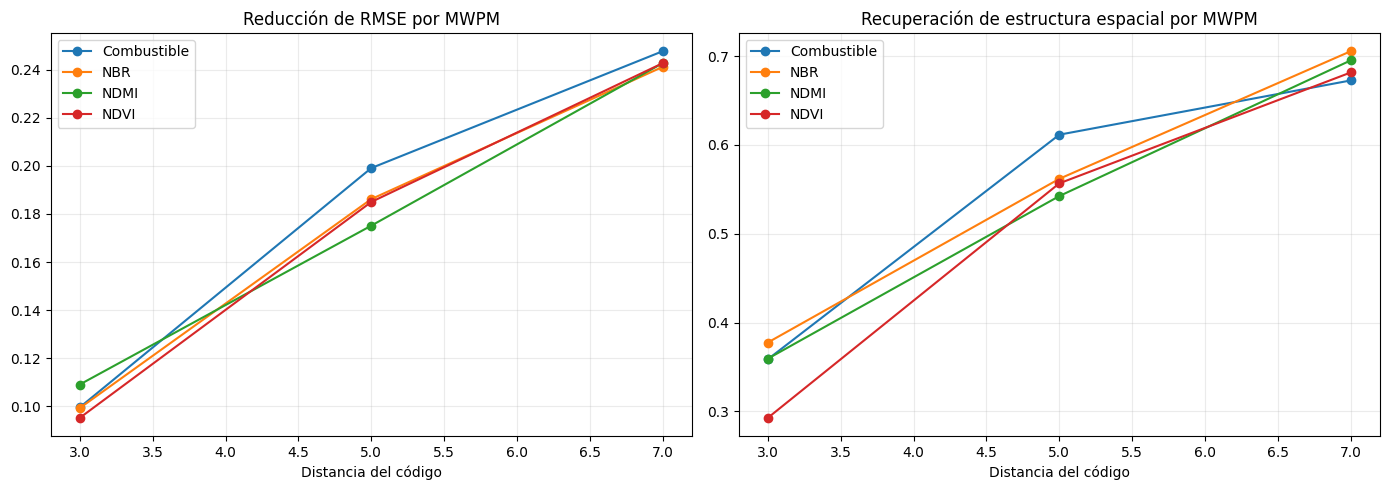

In [45]:
# 14.2.3 Recuperación espectral atribuible a MWPM
spectral_recovery_rows = []
for (index_name,p_noise,distance), group in spectral_quality_summary.groupby(
    ['Índice','p_físico','Distancia']):
    g = group.set_index('Condición')
    no_label = 'Mismo circuito sin decodificación'
    mwpm_label = 'Código de superficie + MWPM'
    if no_label not in g.index or mwpm_label not in g.index:
        continue
    spectral_recovery_rows.append({
        'Índice':index_name,'p_físico':p_noise,'Distancia':distance,
        'Reducción_MAE':g.loc[no_label,'MAE']-g.loc[mwpm_label,'MAE'],
        'Reducción_RMSE':g.loc[no_label,'RMSE']-g.loc[mwpm_label,'RMSE'],
        'Ganancia_correlación':g.loc[mwpm_label,'Correlación']-g.loc[no_label,'Correlación'],
        'Ganancia_SSIM':g.loc[mwpm_label,'SSIM']-g.loc[no_label,'SSIM'],
        'Ganancia_PSNR_dB':g.loc[mwpm_label,'PSNR_dB']-g.loc[no_label,'PSNR_dB'],
    })

spectral_recovery = pd.DataFrame(spectral_recovery_rows)
display(spectral_recovery.style.format({
    'p_físico':'{:.3%}',
    **{c:'{:+.4f}' for c in spectral_recovery.columns if c.startswith(('Reducción_','Ganancia_'))},
}))

fig, axes = plt.subplots(1,2,figsize=(14,5))
for index_name, group in spectral_recovery.groupby('Índice'):
    g = group[group['p_físico']==max(P_ESPECTRAL)].sort_values('Distancia')
    axes[0].plot(g['Distancia'],g['Reducción_RMSE'],marker='o',label=index_name)
    axes[1].plot(g['Distancia'],g['Ganancia_SSIM'],marker='o',label=index_name)
axes[0].set_title('Reducción de RMSE por MWPM')
axes[1].set_title('Recuperación de estructura espacial por MWPM')
for ax in axes:
    ax.set_xlabel('Distancia del código');ax.grid(alpha=.25);ax.legend()
plt.tight_layout();plt.show()


## 14.3 Propagación del efecto hacia CA, CNN, GNN y Transformer

Para aislar el efecto del canal, los modelos conservan sus pesos y umbrales originales. En cada condición solo se reemplazan los canales espectrales:

- canal 0: combustible reconstruido;
- canal 1: sequedad reconstruida como \(1-NDMI\);
- canal 2: vegetación reconstruida a partir de NDVI.

NBR se conserva en la evaluación radiométrica, pero no se inserta artificialmente en una arquitectura que no fue entrenada con ese canal. El CA complementario usa el combustible contenido en cada muestra reconstruida.


In [46]:
# 14.3.1 Funciones para construir entradas y evaluar CA con combustible por condición
def build_condition_inputs(base_x, ndvi_map, ndmi_map, fuel_map):
    x = np.array(base_x, copy=True)
    x[:,0] = fuel_map
    x[:,1] = 1.0 - ndmi_map
    x[:,2] = ndvi_map
    return x.astype(np.float32)

def ca_probability_from_inputs(x):
    out=[]
    th=np.deg2rad(cfg.wind_angle_deg)
    wind=np.array([np.sin(th),np.cos(th)])
    for sample in x:
        fuel_sample=sample[0]
        burning=sample[3]>0.5
        ws=float(sample[6,0,0])
        influence=np.zeros_like(fuel_sample)
        for di,dj in OFFSETS:
            src=np.roll(np.roll(burning,-di,0),-dj,1)
            d=np.array([di,dj],float);d/=np.linalg.norm(d)
            influence+=src*(1+ws*max(0,float(d@wind)))
        out.append(1-np.exp(-cfg.base_spread*fuel_sample*influence))
    return np.stack(out)

# Umbrales originales: no se recalibran con prueba degradada/corregida.
downstream_thresholds = {'CA':tca}
for model_name, model in models.items():
    label='GNN' if model_name=='GNN dirigida' else model_name
    p_train,_=probabilities(model,Xtr)
    downstream_thresholds[label]=best_threshold(Ytr,p_train)

downstream_rows=[]
for p_noise in P_ESPECTRAL:
    for distance in DISTANCIAS_ESPECTRAL:
        for seed in SEMILLAS_ESPECTRAL:
            condition_maps={}
            for condition in ['Ideal cuantizada','Mismo circuito sin decodificación','Código de superficie + MWPM']:
                condition_maps[condition]={
                    product:spectral_reconstructions[(product,p_noise,distance,seed,condition)]
                    for product in ['NDVI','NDMI','Combustible']
                }

            for condition,maps in condition_maps.items():
                x_condition=build_condition_inputs(
                    Xte,maps['NDVI'],maps['NDMI'],maps['Combustible'])

                probabilities_by_model={'CA':ca_probability_from_inputs(x_condition)}
                for model_name,model in models.items():
                    label='GNN' if model_name=='GNN dirigida' else model_name
                    probabilities_by_model[label],_=probabilities(model,x_condition)

                for model_name,prediction_scores in probabilities_by_model.items():
                    threshold=downstream_thresholds[model_name]
                    for sample_idx in ACTIVE_SAMPLES_MULTI:
                        y_true=Yte[sample_idx].ravel().astype(np.uint8)
                        y_score=prediction_scores[sample_idx].ravel()
                        y_pred=(y_score>=threshold).astype(np.uint8)
                        downstream_rows.append({
                            'Modelo':model_name,'p_físico':p_noise,'Distancia':distance,
                            'Semilla':seed,'Condición':condition,
                            'Corrida_test':int(sample_idx//cfg.steps)+1,
                            'Paso':int(sample_idx%cfg.steps)+1,
                            **met(y_true,y_pred),
                            'AUC':safe_auc_local(y_true,y_score),
                            'AUC_PR':safe_ap_local(y_true,y_score),
                        })

downstream_runs=pd.DataFrame(downstream_rows)
print('Evaluaciones activas generadas:',len(downstream_runs))
display(downstream_runs.head())


Evaluaciones activas generadas: 22320


,Modelo,p_físico,Distancia,Semilla,Condición,Corrida_test,Paso,F1,IoU,Balanced_accuracy,Precision,Recall,AUC,AUC_PR
0,CA,0.001,3,42026,Ideal cuantizada,1,1,0.476190,0.312500,0.903976,0.333333,0.833333,0.987310,0.511111
1,CA,0.001,3,42026,Ideal cuantizada,1,2,0.400000,0.250000,0.906943,0.260870,0.857143,0.966739,0.224313
2,CA,0.001,3,42026,Ideal cuantizada,1,3,0.368421,0.225806,0.908163,0.233333,0.875000,0.968750,0.434407
3,CA,0.001,3,42026,Ideal cuantizada,1,4,0.292683,0.171429,0.840561,0.181818,0.750000,0.962691,0.317067
4,CA,0.001,3,42026,Ideal cuantizada,1,5,0.187500,0.103448,0.843434,0.107143,0.750000,0.955808,0.216964


In [47]:
# 14.3.2 Resumen agrupado por corrida-semilla e intervalos de confianza
downstream_metrics=['F1','IoU','Balanced_accuracy','Precision','Recall','AUC','AUC_PR']
downstream_clusters=(
    downstream_runs
    .groupby(['Modelo','p_físico','Distancia','Condición','Semilla','Corrida_test'],as_index=False)
    [downstream_metrics].mean()
)

downstream_summary_rows=[]
for keys,group in downstream_clusters.groupby(['Modelo','p_físico','Distancia','Condición']):
    row=dict(zip(['Modelo','p_físico','Distancia','Condición'],keys))
    row['N_clusters']=len(group);row['N_semillas']=group['Semilla'].nunique();row['N_corridas']=group['Corrida_test'].nunique()
    for metric in downstream_metrics:
        values=group[metric].dropna().to_numpy(float)
        mean=values.mean() if len(values) else np.nan
        std=values.std(ddof=1) if len(values)>1 else np.nan
        se=std/np.sqrt(len(values)) if len(values)>1 else np.nan
        row[f'{metric}_medio']=mean
        row[f'{metric}_std']=std
        row[f'{metric}_IC95_inf']=max(0,mean-1.96*se) if np.isfinite(se) else np.nan
        row[f'{metric}_IC95_sup']=min(1,mean+1.96*se) if np.isfinite(se) else np.nan
    downstream_summary_rows.append(row)

downstream_summary=pd.DataFrame(downstream_summary_rows)
display(downstream_summary.style.format({
    'p_físico':'{:.3%}',
    **{c:'{:.3f}' for c in downstream_summary.columns
       if any(c.startswith(m+'_') for m in downstream_metrics)},
}))


,Modelo,p_físico,Distancia,Condición,N_clusters,N_semillas,N_corridas,F1_medio,F1_std,F1_IC95_inf,F1_IC95_sup,IoU_medio,IoU_std,IoU_IC95_inf,IoU_IC95_sup,Balanced_accuracy_medio,Balanced_accuracy_std,Balanced_accuracy_IC95_inf,Balanced_accuracy_IC95_sup,Precision_medio,Precision_std,Precision_IC95_inf,Precision_IC95_sup,Recall_medio,Recall_std,Recall_IC95_inf,Recall_IC95_sup,AUC_medio,AUC_std,AUC_IC95_inf,AUC_IC95_sup,AUC_PR_medio,AUC_PR_std,AUC_PR_IC95_inf,AUC_PR_IC95_sup
0,CA,0.100%,3,Código de superficie + MWPM,30,5,6,0.226,0.116,0.185,0.268,0.137,0.072,0.111,0.162,0.772,0.138,0.723,0.822,0.146,0.077,0.118,0.173,0.579,0.283,0.478,0.681,0.971,0.006,0.969,0.973,0.252,0.111,0.213,0.292
1,CA,0.100%,3,Ideal cuantizada,30,5,6,0.227,0.116,0.185,0.268,0.137,0.072,0.111,0.163,0.772,0.138,0.723,0.822,0.146,0.077,0.118,0.173,0.579,0.283,0.478,0.681,0.971,0.006,0.969,0.973,0.253,0.111,0.213,0.292
2,CA,0.100%,3,Mismo circuito sin decodificación,30,5,6,0.229,0.116,0.188,0.271,0.139,0.072,0.113,0.164,0.770,0.137,0.721,0.819,0.149,0.077,0.121,0.176,0.575,0.279,0.475,0.675,0.971,0.006,0.969,0.973,0.253,0.112,0.213,0.293
3,CA,0.100%,5,Código de superficie + MWPM,30,5,6,0.227,0.116,0.185,0.268,0.137,0.072,0.111,0.163,0.772,0.138,0.723,0.822,0.146,0.077,0.118,0.173,0.579,0.283,0.478,0.681,0.971,0.006,0.969,0.973,0.253,0.111,0.213,0.292
4,CA,0.100%,5,Ideal cuantizada,30,5,6,0.227,0.116,0.185,0.268,0.137,0.072,0.111,0.163,0.772,0.138,0.723,0.822,0.146,0.077,0.118,0.173,0.579,0.283,0.478,0.681,0.971,0.006,0.969,0.973,0.253,0.111,0.213,0.292
5,CA,0.100%,5,Mismo circuito sin decodificación,30,5,6,0.226,0.115,0.184,0.267,0.137,0.071,0.111,0.162,0.756,0.133,0.709,0.804,0.149,0.077,0.121,0.176,0.546,0.272,0.449,0.644,0.970,0.007,0.968,0.973,0.256,0.108,0.217,0.294
6,CA,0.100%,7,Código de superficie + MWPM,30,5,6,0.227,0.116,0.185,0.268,0.137,0.072,0.111,0.163,0.772,0.138,0.723,0.822,0.146,0.077,0.118,0.173,0.579,0.283,0.478,0.681,0.971,0.006,0.969,0.973,0.253,0.111,0.213,0.292
7,CA,0.100%,7,Ideal cuantizada,30,5,6,0.227,0.116,0.185,0.268,0.137,0.072,0.111,0.163,0.772,0.138,0.723,0.822,0.146,0.077,0.118,0.173,0.579,0.283,0.478,0.681,0.971,0.006,0.969,0.973,0.253,0.111,0.213,0.292
8,CA,0.100%,7,Mismo circuito sin decodificación,30,5,6,0.229,0.104,0.192,0.266,0.139,0.064,0.116,0.162,0.762,0.122,0.718,0.805,0.152,0.071,0.126,0.177,0.556,0.247,0.467,0.644,0.972,0.007,0.970,0.975,0.260,0.100,0.225,0.296
9,CA,0.600%,3,Código de superficie + MWPM,30,5,6,0.227,0.114,0.186,0.268,0.137,0.070,0.112,0.162,0.767,0.135,0.719,0.815,0.147,0.075,0.120,0.174,0.568,0.275,0.470,0.667,0.971,0.006,0.969,0.973,0.253,0.108,0.214,0.292


,Modelo,p_físico,Distancia,Aporte_F1,Recuperación_F1,Aporte_IoU,Recuperación_IoU,Aporte_Balanced_accuracy,Recuperación_Balanced_accuracy,Aporte_Precision,Recuperación_Precision,Aporte_Recall,Recuperación_Recall,Aporte_AUC,Recuperación_AUC,Aporte_AUC_PR,Recuperación_AUC_PR
0,CA,0.100%,3,-0.003,106.3%,-0.002,106.8%,+0.002,101.0%,-0.003,106.1%,+0.005,101.5%,-0.000,89.8%,-0.001,128.8%
1,CA,0.100%,5,+0.001,100.0%,+0.000,100.0%,+0.016,100.0%,-0.003,100.0%,+0.033,100.0%,+0.001,100.0%,-0.003,100.0%
2,CA,0.100%,7,-0.002,100.0%,-0.002,100.0%,+0.010,100.0%,-0.006,100.0%,+0.024,100.0%,-0.001,100.0%,-0.008,100.0%
3,CA,0.600%,3,+0.006,107.2%,+0.003,106.3%,+0.023,82.1%,-0.000,15.3%,+0.049,81.6%,+0.000,115.8%,+0.001,300.5%
4,CA,0.600%,5,+0.001,18.3%,-0.002,-200.1%,+0.050,80.7%,-0.011,130.8%,+0.107,81.5%,-0.000,-38.8%,-0.002,74.8%
5,CA,0.600%,7,+0.036,98.8%,+0.021,99.3%,+0.105,93.0%,+0.005,116.3%,+0.221,93.1%,+0.002,78.6%,+0.005,90.5%
6,CNN,0.100%,3,-0.000,70.8%,-0.000,74.8%,+0.002,100.1%,-0.001,87.6%,+0.004,100.0%,-0.000,85.4%,-0.006,100.6%
7,CNN,0.100%,5,+0.002,100.0%,+0.001,100.0%,+0.007,100.0%,+0.000,100.0%,+0.014,100.0%,+0.000,102.3%,-0.010,99.8%
8,CNN,0.100%,7,+0.001,100.0%,+0.001,100.0%,-0.001,100.0%,-0.002,100.0%,-0.002,100.0%,-0.001,100.0%,-0.010,100.0%
9,CNN,0.600%,3,+0.007,92.6%,+0.005,95.5%,+0.015,88.7%,+0.002,103.2%,+0.031,88.4%,+0.001,456.2%,+0.002,-44.5%


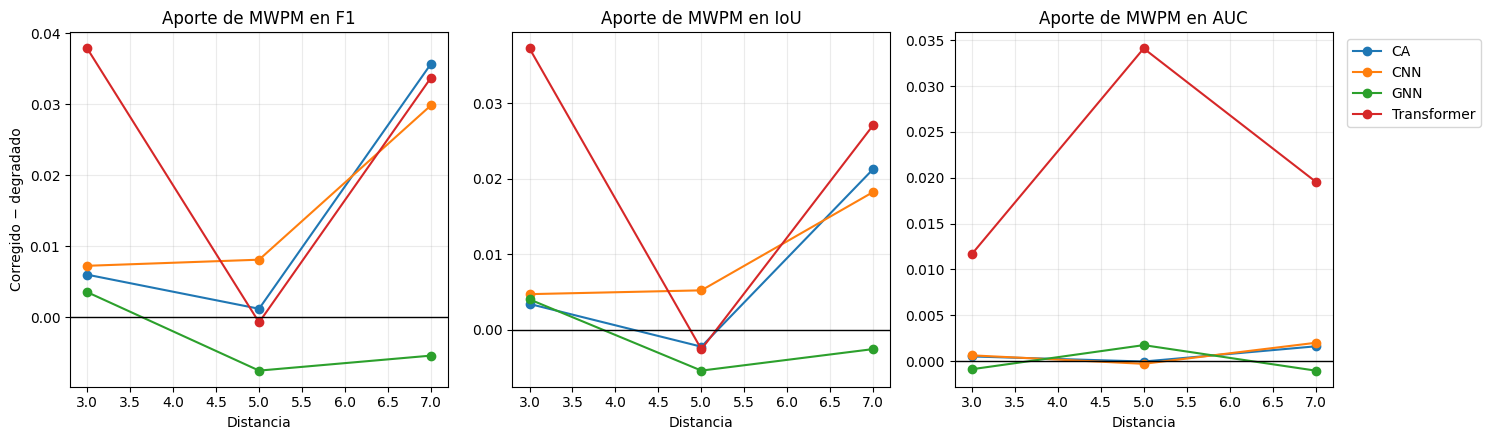

In [48]:
# 14.3.3 Aporte de MWPM en los índices y recuperación de los modelos
downstream_recovery_rows=[]
for (model_name,p_noise,distance),group in downstream_summary.groupby(['Modelo','p_físico','Distancia']):
    g=group.set_index('Condición')
    no_label='Mismo circuito sin decodificación'
    mwpm_label='Código de superficie + MWPM'
    ideal_label='Ideal cuantizada'
    if not {no_label,mwpm_label,ideal_label}.issubset(g.index):
        continue
    row={'Modelo':model_name,'p_físico':p_noise,'Distancia':distance}
    for metric in downstream_metrics:
        ideal=g.loc[ideal_label,f'{metric}_medio']
        degraded=g.loc[no_label,f'{metric}_medio']
        corrected=g.loc[mwpm_label,f'{metric}_medio']
        row[f'Aporte_{metric}']=corrected-degraded
        denominator=ideal-degraded
        row[f'Recuperación_{metric}']=(corrected-degraded)/denominator if abs(denominator)>1e-12 else np.nan
    downstream_recovery_rows.append(row)

downstream_recovery=pd.DataFrame(downstream_recovery_rows)
display(downstream_recovery.style.format({
    'p_físico':'{:.3%}',
    **{c:'{:+.3f}' for c in downstream_recovery.columns if c.startswith('Aporte_')},
    **{c:'{:.1%}' for c in downstream_recovery.columns if c.startswith('Recuperación_')},
}))

fig,axes=plt.subplots(1,3,figsize=(15,4.5))
for ax,metric in zip(axes,['F1','IoU','AUC']):
    selected=downstream_recovery[downstream_recovery['p_físico']==max(P_ESPECTRAL)]
    for model_name,group in selected.groupby('Modelo'):
        group=group.sort_values('Distancia')
        ax.plot(group['Distancia'],group[f'Aporte_{metric}'],marker='o',label=model_name)
    ax.axhline(0,color='black',linewidth=1)
    ax.set_title(f'Aporte de MWPM en {metric}')
    ax.set_xlabel('Distancia');ax.grid(alpha=.25)
axes[0].set_ylabel('Corregido − degradado')
axes[-1].legend(bbox_to_anchor=(1.02,1),loc='upper left')
plt.tight_layout();plt.show()


## 14.3.4 Bootstrap jerárquico de la diferencia pareada MWPM − sin decodificación

Las 30 combinaciones (6 corridas × 5 semillas) no se tratan como 30 incendios independientes. La **corrida de incendio es la unidad primaria de generalización** y las semillas QEC se consideran observaciones anidadas dentro de cada corrida.

Para cada modelo, nivel de ruido y distancia, este bloque: (1) construye diferencias pareadas entre `Código de superficie + MWPM` y `Mismo circuito sin decodificación`; (2) remuestrea las corridas con reemplazo; (3) dentro de cada corrida seleccionada remuestrea sus semillas con reemplazo; (4) calcula la diferencia media; y (5) obtiene IC95% por percentiles a partir de 10.000 réplicas.

> Con solo seis corridas primarias, estos intervalos reflejan mejor la estructura experimental que el IC normal basado en 30 conglomerados, pero la generalización sigue limitada a la escena y al mecanismo de simulación estudiados.


In [56]:
# Bootstrap jerárquico: corrida primaria, semillas anidadas
N_BOOT_HIER = 10_000
SEED_BOOT_HIER = 20260809
COND_NO = 'Mismo circuito sin decodificación'
COND_MWPM = 'Código de superficie + MWPM'

def hierarchical_paired_bootstrap(group, metrics, n_boot=10_000, seed=20260809):
    # Una fila por corrida-semilla y condición; el pareo se conserva antes de remuestrear.
    id_cols = ['Corrida_test', 'Semilla']
    wide = group.pivot_table(index=id_cols, columns='Condición', values=metrics, aggfunc='mean')
    rng = np.random.default_rng(seed)
    runs = wide.index.get_level_values('Corrida_test').unique().to_numpy()
    if len(runs) < 2:
        raise ValueError('Se requieren al menos dos corridas primarias para el bootstrap.')

    result = {'N_corridas_primarias': len(runs), 'N_pares_corrida_semilla': len(wide)}
    for metric in metrics:
        if (metric, COND_MWPM) not in wide.columns or (metric, COND_NO) not in wide.columns:
            continue
        delta = (wide[(metric, COND_MWPM)] - wide[(metric, COND_NO)]).dropna()
        observed = float(delta.mean()) if len(delta) else np.nan
        boot = np.empty(n_boot, dtype=float)

        for b in range(n_boot):
            sampled_runs = rng.choice(runs, size=len(runs), replace=True)
            sampled_values = []
            for run in sampled_runs:
                run_values = delta[delta.index.get_level_values('Corrida_test') == run].to_numpy(float)
                if run_values.size:
                    sampled_values.extend(rng.choice(run_values, size=run_values.size, replace=True))
            boot[b] = np.mean(sampled_values) if sampled_values else np.nan

        valid_boot = boot[np.isfinite(boot)]
        lo, hi = np.percentile(valid_boot, [2.5, 97.5]) if valid_boot.size else (np.nan, np.nan)
        result[f'{metric}_diferencia_media'] = observed
        result[f'{metric}_IC95_inf_boot'] = float(lo)
        result[f'{metric}_IC95_sup_boot'] = float(hi)
        result[f'{metric}_incluye_cero'] = bool(lo <= 0 <= hi) if np.isfinite(lo + hi) else np.nan
    return result

bootstrap_rows = []
group_keys = ['Modelo', 'p_físico', 'Distancia']
for group_number, (keys, group) in enumerate(downstream_clusters.groupby(group_keys)):
    if not {COND_NO, COND_MWPM}.issubset(set(group['Condición'])):
        continue
    row = dict(zip(group_keys, keys))
    row.update(hierarchical_paired_bootstrap(
        group, downstream_metrics, n_boot=N_BOOT_HIER,
        seed=SEED_BOOT_HIER + group_number
    ))
    bootstrap_rows.append(row)

downstream_bootstrap_hierarchical = pd.DataFrame(bootstrap_rows)
display(downstream_bootstrap_hierarchical.style.format({
    'p_físico': '{:.3%}',
    **{c: '{:+.4f}' for c in downstream_bootstrap_hierarchical.columns
       if c.endswith(('_diferencia_media', '_IC95_inf_boot', '_IC95_sup_boot'))}
}))

downstream_bootstrap_hierarchical.to_csv(
    'qec_indices_efecto_modelos_bootstrap_jerarquico.csv', index=False
)
print(f'Bootstrap jerárquico completado: {N_BOOT_HIER:,} réplicas por configuración.')
print('Unidad primaria de generalización: Corrida_test.')


,Modelo,p_físico,Distancia,N_corridas_primarias,N_pares_corrida_semilla,F1_diferencia_media,F1_IC95_inf_boot,F1_IC95_sup_boot,F1_incluye_cero,IoU_diferencia_media,IoU_IC95_inf_boot,IoU_IC95_sup_boot,IoU_incluye_cero,Balanced_accuracy_diferencia_media,Balanced_accuracy_IC95_inf_boot,Balanced_accuracy_IC95_sup_boot,Balanced_accuracy_incluye_cero,Precision_diferencia_media,Precision_IC95_inf_boot,Precision_IC95_sup_boot,Precision_incluye_cero,Recall_diferencia_media,Recall_IC95_inf_boot,Recall_IC95_sup_boot,Recall_incluye_cero,AUC_diferencia_media,AUC_IC95_inf_boot,AUC_IC95_sup_boot,AUC_incluye_cero,AUC_PR_diferencia_media,AUC_PR_IC95_inf_boot,AUC_PR_IC95_sup_boot,AUC_PR_incluye_cero
0,CA,0.100%,3,6,30,-0.0031,-0.0086,+0.0012,True,-0.0019,-0.0056,+0.0010,True,+0.0018,-0.0054,+0.0082,True,-0.0030,-0.0068,-0.0002,False,+0.0047,-0.0096,+0.0182,True,-0.0003,-0.0010,+0.0005,True,-0.0011,-0.0063,+0.0038,True
1,CA,0.100%,5,6,30,+0.0010,-0.0082,+0.0086,True,+0.0001,-0.0062,+0.0051,True,+0.0156,+0.0046,+0.0293,False,-0.0027,-0.0127,+0.0035,True,+0.0329,+0.0110,+0.0614,False,+0.0008,-0.0006,+0.0022,True,-0.0031,-0.0186,+0.0099,True
2,CA,0.100%,7,6,30,-0.0023,-0.0248,+0.0154,True,-0.0017,-0.0158,+0.0099,True,+0.0105,-0.0526,+0.0471,True,-0.0056,-0.0206,+0.0064,True,+0.0238,-0.1065,+0.0973,True,-0.0012,-0.0042,+0.0010,True,-0.0078,-0.0260,+0.0106,True
3,CA,0.600%,3,6,30,+0.0060,-0.0038,+0.0176,True,+0.0034,-0.0032,+0.0105,True,+0.0234,+0.0069,+0.0427,False,-0.0002,-0.0108,+0.0083,True,+0.0492,+0.0160,+0.0889,False,+0.0005,-0.0005,+0.0014,True,+0.0006,-0.0116,+0.0114,True
4,CA,0.600%,5,6,30,+0.0012,-0.0282,+0.0288,True,-0.0022,-0.0217,+0.0147,True,+0.0496,-0.0309,+0.1115,True,-0.0107,-0.0315,+0.0072,True,+0.1070,-0.0574,+0.2308,True,-0.0001,-0.0035,+0.0023,True,-0.0020,-0.0252,+0.0201,True
5,CA,0.600%,7,6,30,+0.0357,+0.0020,+0.0776,False,+0.0213,+0.0002,+0.0456,False,+0.1052,+0.0479,+0.1677,False,+0.0054,-0.0233,+0.0362,True,+0.2209,+0.1088,+0.3454,False,+0.0016,-0.0032,+0.0053,True,+0.0054,-0.0240,+0.0334,True
6,CNN,0.100%,3,6,30,-0.0003,-0.0024,+0.0020,True,-0.0003,-0.0021,+0.0014,True,+0.0020,+0.0001,+0.0044,False,-0.0010,-0.0028,+0.0007,True,+0.0044,+0.0006,+0.0090,False,-0.0001,-0.0007,+0.0003,True,-0.0059,-0.0141,+0.0001,True
7,CNN,0.100%,5,6,30,+0.0022,-0.0014,+0.0065,True,+0.0013,-0.0013,+0.0042,True,+0.0069,+0.0016,+0.0148,False,+0.0004,-0.0023,+0.0032,True,+0.0142,+0.0037,+0.0298,False,+0.0001,-0.0011,+0.0013,True,-0.0100,-0.0386,+0.0082,True
8,CNN,0.100%,7,6,30,+0.0009,-0.0236,+0.0224,True,+0.0011,-0.0129,+0.0150,True,-0.0015,-0.0602,+0.0286,True,-0.0015,-0.0149,+0.0134,True,-0.0024,-0.1189,+0.0583,True,-0.0007,-0.0026,+0.0008,True,-0.0102,-0.0470,+0.0148,True
9,CNN,0.600%,3,6,30,+0.0073,-0.0010,+0.0226,True,+0.0047,-0.0014,+0.0164,True,+0.0155,+0.0044,+0.0311,False,+0.0022,-0.0049,+0.0145,True,+0.0314,+0.0087,+0.0622,False,+0.0006,-0.0007,+0.0023,True,+0.0016,-0.0148,+0.0137,True


Bootstrap jerárquico completado: 10,000 réplicas por configuración.
Unidad primaria de generalización: Corrida_test.


DataFrames candidatos encontrados:


,Nombre,Filas,Modelos,Ruidos,Distancias,Columnas_aporte,Puntuación
1,downstream_recovery,24,4,2,3,7,192
0,aporte_multisample,18,3,2,3,6,126
2,selected,12,4,1,3,7,96


DataFrame completo seleccionado: downstream_recovery
Número de filas: 24
Cobertura que será visualizada:


,Modelo_normalizado,p_físico_num,N_distancias,Distancias,N_filas
0,CA,0.100%,3,"[np.int64(3), np.int64(5), np.int64(7)]",3
1,CA,0.600%,3,"[np.int64(3), np.int64(5), np.int64(7)]",3
2,CNN,0.100%,3,"[np.int64(3), np.int64(5), np.int64(7)]",3
3,CNN,0.600%,3,"[np.int64(3), np.int64(5), np.int64(7)]",3
4,GNN,0.100%,3,"[np.int64(3), np.int64(5), np.int64(7)]",3
5,GNN,0.600%,3,"[np.int64(3), np.int64(5), np.int64(7)]",3
6,Transformer,0.100%,3,"[np.int64(3), np.int64(5), np.int64(7)]",3
7,Transformer,0.600%,3,"[np.int64(3), np.int64(5), np.int64(7)]",3


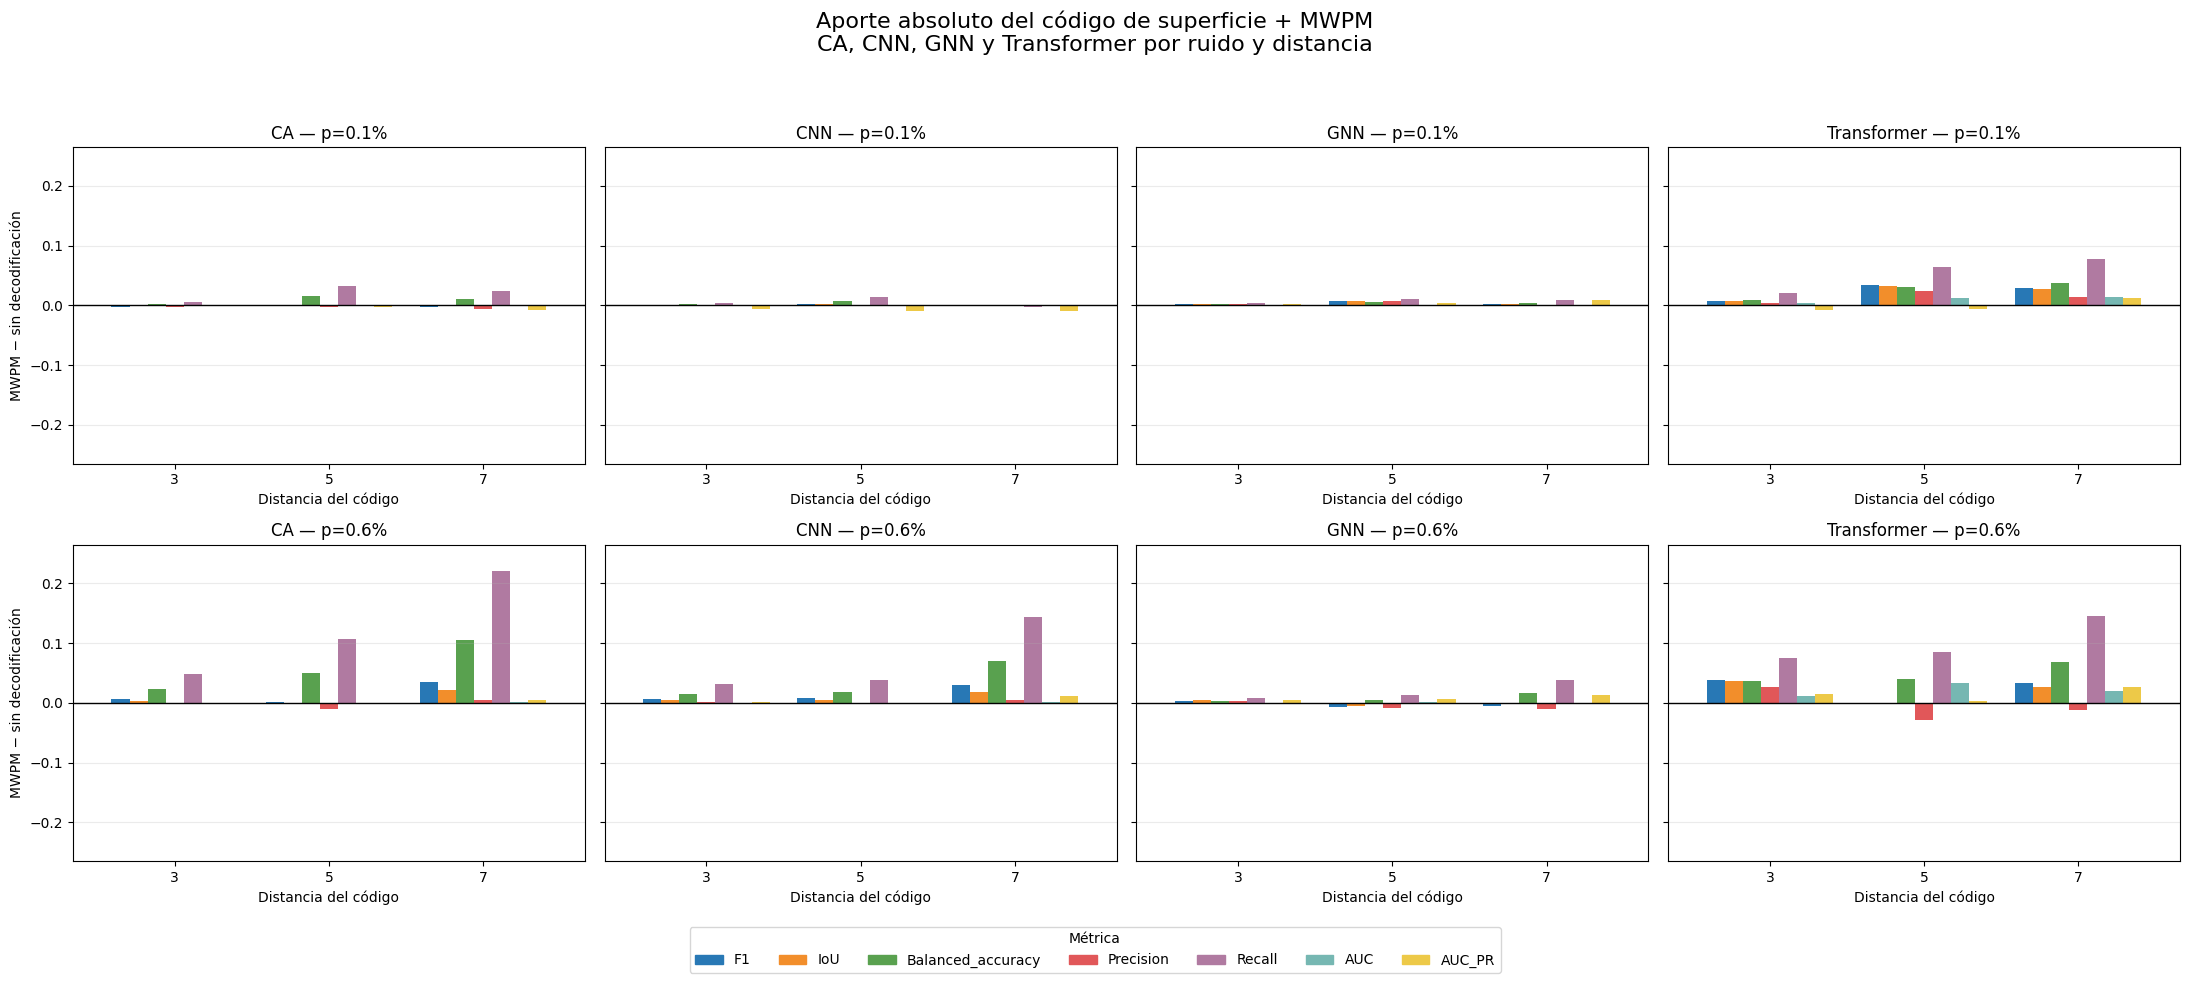

,Modelo,p_físico,Distancia,Aporte_F1,Aporte_IoU,Aporte_Balanced_accuracy,Aporte_Precision,Aporte_Recall,Aporte_AUC,Aporte_AUC_PR
0,CA,0.100%,3,-0.003,-0.002,+0.002,-0.003,+0.005,-0.000,-0.001
1,CA,0.100%,5,+0.001,+0.000,+0.016,-0.003,+0.033,+0.001,-0.003
2,CA,0.100%,7,-0.002,-0.002,+0.010,-0.006,+0.024,-0.001,-0.008
3,CNN,0.100%,3,-0.000,-0.000,+0.002,-0.001,+0.004,-0.000,-0.006
4,CNN,0.100%,5,+0.002,+0.001,+0.007,+0.000,+0.014,+0.000,-0.010
5,CNN,0.100%,7,+0.001,+0.001,-0.001,-0.002,-0.002,-0.001,-0.010
6,GNN,0.100%,3,+0.002,+0.002,+0.002,+0.002,+0.004,+0.000,+0.002
7,GNN,0.100%,5,+0.008,+0.008,+0.005,+0.007,+0.010,+0.000,+0.004
8,GNN,0.100%,7,+0.002,+0.003,+0.004,+0.001,+0.008,-0.001,+0.009
9,Transformer,0.100%,3,+0.007,+0.006,+0.009,+0.003,+0.020,+0.004,-0.008


Archivo creado: aporte_codigo_CA_CNN_GNN_Transformer_visualizacion.csv


In [52]:
# ============================================================
# VISUALIZACIÓN CORREGIDA DEL APORTE DEL CÓDIGO
# CA, CNN, GNN Y TRANSFORMER
#
# Filas: ruido 0,1 % y 0,6 %
# Columnas: CA, CNN, GNN y Transformer
# Eje X: distancias 3, 5 y 7
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Configuración
# ------------------------------------------------------------

MODELOS_VIS = [
    "CA",
    "CNN",
    "GNN",
    "Transformer",
]

RUIDOS_VIS = [
    0.001,   # 0,1 %
    0.006,   # 0,6 %
]

DISTANCIAS_VIS = [
    3,
    5,
    7,
]

METRICAS_VIS = [
    "F1",
    "IoU",
    "Balanced_accuracy",
    "Precision",
    "Recall",
    "AUC",
    "AUC_PR",
]

COLORES_METRICAS = {
    "F1": "#2878B5",
    "IoU": "#F28E2B",
    "Balanced_accuracy": "#59A14F",
    "Precision": "#E15759",
    "Recall": "#B07AA1",
    "AUC": "#76B7B2",
    "AUC_PR": "#EDC948",
}


# ------------------------------------------------------------
# 2. Buscar el DataFrame original completo
# ------------------------------------------------------------

columnas_minimas = {
    "Modelo",
    "p_físico",
    "Distancia",
    "Aporte_F1",
    "Aporte_IoU",
    "Aporte_AUC",
}

candidatos = []

for nombre_objeto, objeto in globals().copy().items():

    if not isinstance(
        objeto,
        pd.DataFrame,
    ):
        continue

    if not columnas_minimas.issubset(
        objeto.columns
    ):
        continue

    df_test = objeto.copy()

    numero_modelos = (
        df_test["Modelo"]
        .astype(str)
        .nunique()
    )

    numero_ruidos = (
        df_test["p_físico"]
        .astype(str)
        .nunique()
    )

    numero_distancias = (
        df_test["Distancia"]
        .nunique()
    )

    numero_columnas_aporte = sum(
        str(columna).startswith(
            "Aporte_"
        )
        for columna in df_test.columns
    )

    # Favorecer el DataFrame con mayor cobertura
    puntuacion = (
        numero_modelos
        * numero_ruidos
        * numero_distancias
        * max(
            numero_columnas_aporte,
            1,
        )
        + len(df_test)
    )

    candidatos.append({
        "Nombre": nombre_objeto,
        "DataFrame": objeto,
        "Filas": len(df_test),
        "Modelos": numero_modelos,
        "Ruidos": numero_ruidos,
        "Distancias": numero_distancias,
        "Columnas_aporte":
            numero_columnas_aporte,
        "Puntuación": puntuacion,
    })

if len(candidatos) == 0:

    raise NameError(
        "No se encontró ningún DataFrame "
        "con las columnas de aporte del código."
    )

tabla_candidatos = pd.DataFrame([
    {
        key: value
        for key, value
        in candidato.items()
        if key != "DataFrame"
    }
    for candidato in candidatos
]).sort_values(
    "Puntuación",
    ascending=False,
)

print(
    "DataFrames candidatos encontrados:"
)

display(
    tabla_candidatos
)

mejor_candidato = max(
    candidatos,
    key=lambda elemento:
        elemento["Puntuación"],
)

nombre_dataframe = mejor_candidato[
    "Nombre"
]

aporte_codigo_full = mejor_candidato[
    "DataFrame"
].copy()

print(
    "DataFrame completo seleccionado:",
    nombre_dataframe,
)

print(
    "Número de filas:",
    len(aporte_codigo_full),
)


# ------------------------------------------------------------
# 3. Normalizar nombres de modelos
# ------------------------------------------------------------

def normalizar_modelo(nombre):

    texto = str(
        nombre
    ).strip().lower()

    if texto in [
        "ca",
        "regla ca",
        "autómata celular",
        "automata celular",
    ]:
        return "CA"

    if "cnn" in texto:
        return "CNN"

    if "gnn" in texto:
        return "GNN"

    if "transform" in texto:
        return "Transformer"

    return str(nombre).strip()


aporte_codigo_full[
    "Modelo_normalizado"
] = aporte_codigo_full[
    "Modelo"
].apply(
    normalizar_modelo
)


# ------------------------------------------------------------
# 4. Normalizar ruido físico
# ------------------------------------------------------------

def convertir_probabilidad(valor):

    if isinstance(valor, str):

        texto = (
            valor
            .strip()
            .replace(",", ".")
        )

        if texto.endswith("%"):

            return float(
                texto[:-1]
            ) / 100

        return float(texto)

    return float(valor)


aporte_codigo_full[
    "p_físico_num"
] = aporte_codigo_full[
    "p_físico"
].apply(
    convertir_probabilidad
)

aporte_codigo_full[
    "Distancia_num"
] = aporte_codigo_full[
    "Distancia"
].astype(int)


# ------------------------------------------------------------
# 5. Verificar cobertura antes de graficar
# ------------------------------------------------------------

cobertura = (
    aporte_codigo_full
    .groupby(
        [
            "Modelo_normalizado",
            "p_físico_num",
        ],
        as_index=False,
    )
    .agg(
        N_distancias=(
            "Distancia_num",
            "nunique",
        ),
        Distancias=(
            "Distancia_num",
            lambda valores:
                sorted(
                    valores.unique()
                ),
        ),
        N_filas=(
            "Distancia_num",
            "size",
        ),
    )
)

print(
    "Cobertura que será visualizada:"
)

display(
    cobertura.style.format({
        "p_físico_num": "{:.3%}",
    })
)


# ------------------------------------------------------------
# 6. Métricas realmente disponibles
# ------------------------------------------------------------

metricas_disponibles = [
    metrica
    for metrica in METRICAS_VIS
    if f"Aporte_{metrica}"
    in aporte_codigo_full.columns
]

if len(metricas_disponibles) == 0:

    raise ValueError(
        "No se encontraron columnas "
        "Aporte_ para graficar."
    )

columnas_aporte = [
    f"Aporte_{metrica}"
    for metrica
    in metricas_disponibles
]


# ------------------------------------------------------------
# 7. Filtrar datos solicitados
# ------------------------------------------------------------

mascara_ruido = np.logical_or.reduce([
    np.isclose(
        aporte_codigo_full[
            "p_físico_num"
        ],
        p,
    )
    for p in RUIDOS_VIS
])

datos_visualizacion = aporte_codigo_full[
    aporte_codigo_full[
        "Modelo_normalizado"
    ].isin(
        MODELOS_VIS
    )
    & aporte_codigo_full[
        "Distancia_num"
    ].isin(
        DISTANCIAS_VIS
    )
    & mascara_ruido
].copy()

if datos_visualizacion.empty:

    raise ValueError(
        "El DataFrame seleccionado no contiene "
        "las configuraciones solicitadas."
    )


# ------------------------------------------------------------
# 8. Escala vertical común
# ------------------------------------------------------------

maximo_absoluto = (
    datos_visualizacion[
        columnas_aporte
    ]
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
    .abs()
    .max()
    .max()
)

limite_vertical = max(
    0.05,
    float(maximo_absoluto)
    * 1.20,
)


# ------------------------------------------------------------
# 9. Figura: 2 filas × 4 columnas
# ------------------------------------------------------------

fig, axes = plt.subplots(
    len(RUIDOS_VIS),
    len(MODELOS_VIS),
    figsize=(22, 10),
    sharey=True,
)

for fila, p_fisico in enumerate(
    RUIDOS_VIS
):

    for columna, modelo in enumerate(
        MODELOS_VIS
    ):

        ax = axes[
            fila,
            columna,
        ]

        seleccion = datos_visualizacion[
            (
                datos_visualizacion[
                    "Modelo_normalizado"
                ] == modelo
            )
            & np.isclose(
                datos_visualizacion[
                    "p_físico_num"
                ],
                p_fisico,
            )
        ].copy()

        # Si hay registros duplicados, promediarlos
        seleccion_agrupada = (
            seleccion
            .groupby(
                "Distancia_num",
                as_index=True,
            )[
                columnas_aporte
            ]
            .mean()
            .reindex(
                DISTANCIAS_VIS
            )
        )

        seleccion_agrupada.columns = [
            columna_nombre.replace(
                "Aporte_",
                "",
            )
            for columna_nombre
            in seleccion_agrupada.columns
        ]

        if (
            seleccion_agrupada
            .notna()
            .sum()
            .sum()
            == 0
        ):

            ax.text(
                0.5,
                0.5,
                "Sin datos",
                ha="center",
                va="center",
                transform=ax.transAxes,
                color="red",
            )

            ax.set_xticks(
                range(
                    len(
                        DISTANCIAS_VIS
                    )
                )
            )

            ax.set_xticklabels(
                DISTANCIAS_VIS
            )

        else:

            seleccion_agrupada.plot(
                kind="bar",
                ax=ax,
                width=0.82,
                color=[
                    COLORES_METRICAS[
                        metrica
                    ]
                    for metrica
                    in seleccion_agrupada.columns
                ],
                legend=False,
            )

        ax.axhline(
            0,
            color="black",
            linewidth=1,
        )

        ax.set_ylim(
            -limite_vertical,
            limite_vertical,
        )

        ax.set_title(
            f"{modelo} — p={p_fisico:.1%}"
        )

        ax.set_xlabel(
            "Distancia del código"
        )

        if columna == 0:

            ax.set_ylabel(
                "MWPM − sin decodificación"
            )

        else:

            ax.set_ylabel(
                ""
            )

        ax.grid(
            axis="y",
            alpha=0.25,
        )

        ax.tick_params(
            axis="x",
            rotation=0,
        )


# ------------------------------------------------------------
# 10. Leyenda común
# ------------------------------------------------------------

handles = [
    plt.Rectangle(
        (0, 0),
        1,
        1,
        color=COLORES_METRICAS[
            metrica
        ],
    )
    for metrica
    in metricas_disponibles
]

fig.legend(
    handles,
    metricas_disponibles,
    title="Métrica",
    loc="lower center",
    ncol=len(
        metricas_disponibles
    ),
    bbox_to_anchor=(
        0.5,
        0.01,
    ),
)

fig.suptitle(
    "Aporte absoluto del código de superficie + MWPM\n"
    "CA, CNN, GNN y Transformer por ruido y distancia",
    fontsize=16,
)

plt.tight_layout(
    rect=[
        0,
        0.07,
        1,
        0.94,
    ]
)

plt.show()


# ------------------------------------------------------------
# 11. Tabla utilizada en la visualización
# ------------------------------------------------------------

tabla_visualizada = datos_visualizacion[
    [
        "Modelo_normalizado",
        "p_físico_num",
        "Distancia_num",
        *columnas_aporte,
    ]
].copy()

tabla_visualizada = tabla_visualizada.rename(
    columns={
        "Modelo_normalizado":
            "Modelo",
        "p_físico_num":
            "p_físico",
        "Distancia_num":
            "Distancia",
    }
)

tabla_visualizada = (
    tabla_visualizada
    .sort_values(
        [
            "p_físico",
            "Modelo",
            "Distancia",
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    tabla_visualizada.style.format({
        "p_físico": "{:.3%}",
        **{
            columna: "{:+.3f}"
            for columna
            in columnas_aporte
        },
    })
)

tabla_visualizada.to_csv(
    "aporte_codigo_CA_CNN_GNN_Transformer_visualizacion.csv",
    index=False,
)

print(
    "Archivo creado: "
    "aporte_codigo_CA_CNN_GNN_Transformer_visualizacion.csv"
)

## 7.1 Variabilidad por semilla de entrenamiento

CNN, GNN y Transformer se reentrenan con cinco semillas, manteniendo constantes la escena, las corridas de entrenamiento y prueba, los hiperparámetros y el criterio de evaluación.

Para cada ajuste, el umbral se selecciona **exclusivamente con los 224 estados de entrenamiento** y luego se aplica una única vez al conjunto de prueba.

Se presentan:

- resultados individuales por semilla;
- media $\pm$ desviación estándar;
- intervalo de confianza bootstrap percentil del 95%;
- variabilidad del umbral seleccionado.

La semilla de entrenamiento constituye la unidad de remuestreo. Estos intervalos cuantifican la variabilidad asociada al ajuste de las redes y no sustituyen una validación externa.

[1/15] Entrenando CNN con semilla 42
    F1=0.430 | IoU=0.274 | Recall=0.828 | Umbral=0.900
[2/15] Entrenando CNN con semilla 43
    F1=0.326 | IoU=0.194 | Recall=0.900 | Umbral=0.675
[3/15] Entrenando CNN con semilla 44
    F1=0.423 | IoU=0.268 | Recall=0.749 | Umbral=0.900
[4/15] Entrenando CNN con semilla 45
    F1=0.431 | IoU=0.275 | Recall=0.806 | Umbral=0.900
[5/15] Entrenando CNN con semilla 46
    F1=0.422 | IoU=0.267 | Recall=0.668 | Umbral=0.900
[6/15] Entrenando GNN dirigida con semilla 42
    F1=0.287 | IoU=0.168 | Recall=0.586 | Umbral=0.800
[7/15] Entrenando GNN dirigida con semilla 43
    F1=0.217 | IoU=0.122 | Recall=0.821 | Umbral=0.625
[8/15] Entrenando GNN dirigida con semilla 44
    F1=0.306 | IoU=0.181 | Recall=0.536 | Umbral=0.825
[9/15] Entrenando GNN dirigida con semilla 45
    F1=0.257 | IoU=0.147 | Recall=0.614 | Umbral=0.800
[10/15] Entrenando GNN dirigida con semilla 46
    F1=0.267 | IoU=0.154 | Recall=0.655 | Umbral=0.800
[11/15] Entrenando Transformer con

,Modelo,Semilla_entrenamiento,Umbral,F1,IoU,Balanced_accuracy,Precision,Recall,Entrenamiento_s,Inferencia_s,Épocas,N_estados_train,N_estados_test,N_corridas_train,N_corridas_test
0,CNN,42,0.900,0.430,0.274,0.905,0.290,0.828,7.9,0.054,20,224,96,14,6
1,CNN,43,0.675,0.326,0.194,0.935,0.199,0.900,9.3,0.023,20,224,96,14,6
2,CNN,44,0.900,0.423,0.268,0.867,0.294,0.749,2.8,0.015,20,224,96,14,6
3,CNN,45,0.900,0.431,0.275,0.895,0.294,0.806,3.6,0.014,20,224,96,14,6
4,CNN,46,0.900,0.422,0.267,0.828,0.308,0.668,2.5,0.020,20,224,96,14,6
5,GNN dirigida,42,0.800,0.287,0.168,0.783,0.190,0.586,2.7,0.024,20,224,96,14,6
6,GNN dirigida,43,0.625,0.217,0.122,0.887,0.125,0.821,2.6,0.023,20,224,96,14,6
7,GNN dirigida,44,0.825,0.306,0.181,0.760,0.214,0.536,3.9,0.024,20,224,96,14,6
8,GNN dirigida,45,0.800,0.257,0.147,0.794,0.163,0.614,2.7,0.023,20,224,96,14,6
9,GNN dirigida,46,0.800,0.267,0.154,0.814,0.168,0.655,2.7,0.023,20,224,96,14,6



Resumen: media ± DE [IC95% bootstrap]
---------------------------------------


,Modelo,N_semillas,F1,IoU,Balanced_accuracy,Precision,Recall
0,CNN,5,"0.406 ± 0.045 [0.366, 0.429]","0.256 ± 0.034 [0.225, 0.273]","0.886 ± 0.041 [0.851, 0.915]","0.277 ± 0.044 [0.237, 0.302]","0.790 ± 0.087 [0.717, 0.855]"
1,GNN dirigida,5,"0.267 ± 0.034 [0.239, 0.291]","0.154 ± 0.022 [0.136, 0.170]","0.807 ± 0.048 [0.775, 0.850]","0.172 ± 0.033 [0.146, 0.196]","0.643 ± 0.109 [0.570, 0.739]"
2,Transformer,5,"0.438 ± 0.010 [0.431, 0.446]","0.280 ± 0.008 [0.274, 0.287]","0.867 ± 0.017 [0.854, 0.881]","0.310 ± 0.013 [0.299, 0.320]","0.749 ± 0.036 [0.720, 0.777]"


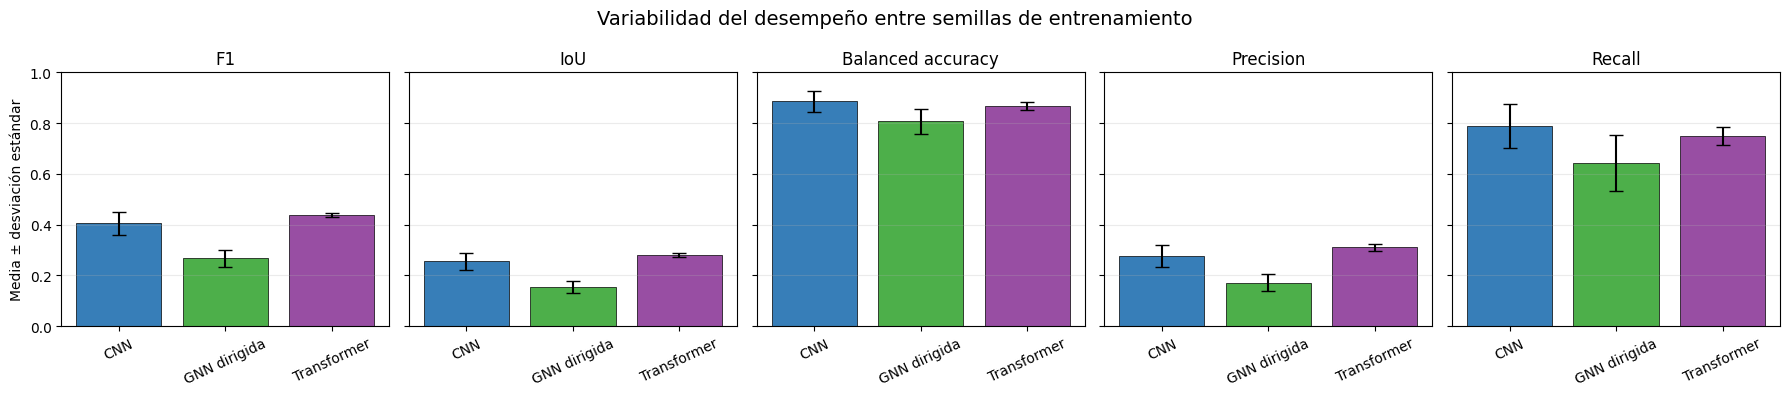

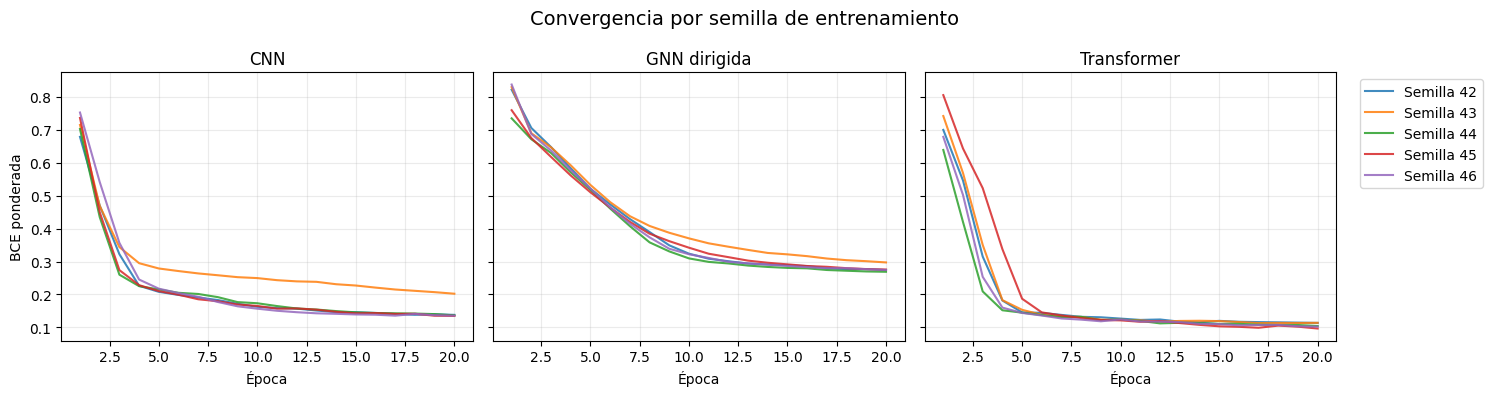


Archivos exportados:
- metricas_modelos_por_semilla_entrenamiento.csv
- metricas_modelos_multisemilla_resumen.csv
- metricas_modelos_multisemilla_tabla_manuscrito.csv


In [57]:
# ============================================================
# 7.1 VARIABILIDAD POR SEMILLA DE ENTRENAMIENTO
# CNN, GNN Y TRANSFORMER
# ============================================================

TRAIN_SEEDS = [42, 43, 44, 45, 46]
N_BOOT_TRAIN = 10_000

METRICS_TRAIN_SEEDS = [
    "F1",
    "IoU",
    "Balanced_accuracy",
    "Precision",
    "Recall",
]

MODEL_FACTORIES = {
    "CNN": FireCNN,
    "GNN dirigida": FireGNN,
    "Transformer": FireTransformer,
}


# ------------------------------------------------------------
# 1. Control reproducible de las semillas
# ------------------------------------------------------------

def set_training_seed(seed):
    """
    Controla:

    - inicialización de pesos;
    - orden de batches;
    - generadores NumPy y Python;
    - operaciones CUDA compatibles.
    """

    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ------------------------------------------------------------
# 2. Entrenamiento independiente para una semilla
# ------------------------------------------------------------

def train_with_seed(model_factory, seed):

    set_training_seed(seed)

    # Generador propio para controlar el orden de los batches
    generator = torch.Generator()
    generator.manual_seed(seed)

    loader = DataLoader(
        train_ds,
        batch_size=cfg.batch_size,
        shuffle=True,
        generator=generator,
        num_workers=0,
    )

    # Crear una instancia nueva del modelo
    model = model_factory().to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.lr,
        weight_decay=1e-4,
    )

    pos_weight = max(
        1,
        float(
            (Ytr.size - Ytr.sum())
            / (Ytr.sum() + 1e-8)
        ),
    )

    loss_fn = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor(
            [min(pos_weight, 30)],
            device=DEVICE,
        )
    )

    history = []
    start_time = time.perf_counter()

    for epoch in range(cfg.epochs):

        model.train()
        total_loss = 0.0

        for xb, yb in loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad(
                set_to_none=True
            )

            logits = model(xb)
            loss = loss_fn(logits, yb)

            loss.backward()
            optimizer.step()

            total_loss += (
                loss.item() * len(xb)
            )

        epoch_loss = (
            total_loss / len(train_ds)
        )

        history.append(epoch_loss)

    training_time = (
        time.perf_counter() - start_time
    )

    return model, history, training_time


# ------------------------------------------------------------
# 3. Reentrenar las tres arquitecturas
# ------------------------------------------------------------

multiseed_rows = []
multiseed_histories = {}

total_trainings = (
    len(MODEL_FACTORIES)
    * len(TRAIN_SEEDS)
)

training_counter = 0

for model_name, model_factory in (
    MODEL_FACTORIES.items()
):

    for seed in TRAIN_SEEDS:

        training_counter += 1

        print(
            f"[{training_counter}/{total_trainings}] "
            f"Entrenando {model_name} "
            f"con semilla {seed}"
        )

        fitted_model, history, train_sec = (
            train_with_seed(
                model_factory,
                seed,
            )
        )

        # ---------------------------------------------
        # Calibrar el umbral únicamente con entrenamiento
        # ---------------------------------------------

        probability_train, _ = probabilities(
            fitted_model,
            Xtr,
        )

        threshold = best_threshold(
            Ytr,
            probability_train,
        )

        # ---------------------------------------------
        # Evaluación única sobre prueba
        # ---------------------------------------------

        probability_test, inference_sec = (
            probabilities(
                fitted_model,
                Xte,
            )
        )

        prediction_test = (
            probability_test >= threshold
        ).astype("uint8")

        metrics_seed = met(
            Yte,
            prediction_test,
        )

        multiseed_rows.append({
            "Modelo": model_name,
            "Semilla_entrenamiento": seed,
            "Umbral": threshold,
            **metrics_seed,
            "Entrenamiento_s": train_sec,
            "Inferencia_s": inference_sec,
            "Épocas": cfg.epochs,
            "N_estados_train": len(Xtr),
            "N_estados_test": len(Xte),
            "N_corridas_train": cfg.train_runs,
            "N_corridas_test":
                cfg.n_runs - cfg.train_runs,
        })

        multiseed_histories[
            (model_name, seed)
        ] = history

        print(
            f"    F1={metrics_seed['F1']:.3f} | "
            f"IoU={metrics_seed['IoU']:.3f} | "
            f"Recall={metrics_seed['Recall']:.3f} | "
            f"Umbral={threshold:.3f}"
        )

        del fitted_model

        if torch.cuda.is_available():
            torch.cuda.empty_cache()


training_seed_results = pd.DataFrame(
    multiseed_rows
)


# ------------------------------------------------------------
# 4. IC95% bootstrap del promedio entre semillas
# ------------------------------------------------------------

def bootstrap_mean_ci(
    values,
    n_boot=N_BOOT_TRAIN,
    confidence=0.95,
    seed=2026,
):
    """
    Bootstrap percentil del promedio.

    La unidad de remuestreo es la semilla
    de entrenamiento.
    """

    values = np.asarray(
        values,
        dtype=float,
    )

    values = values[
        np.isfinite(values)
    ]

    if len(values) == 0:
        return np.nan, np.nan

    rng = np.random.default_rng(seed)

    bootstrap_samples = rng.choice(
        values,
        size=(n_boot, len(values)),
        replace=True,
    )

    bootstrap_means = (
        bootstrap_samples.mean(axis=1)
    )

    alpha = 1 - confidence

    lower, upper = np.quantile(
        bootstrap_means,
        [
            alpha / 2,
            1 - alpha / 2,
        ],
    )

    return float(lower), float(upper)


# ------------------------------------------------------------
# 5. Resumen: media, DE e IC95%
# ------------------------------------------------------------

summary_rows = []

for model_name, group in (
    training_seed_results.groupby(
        "Modelo",
        sort=False,
    )
):

    summary_row = {
        "Modelo": model_name,
        "N_semillas":
            group[
                "Semilla_entrenamiento"
            ].nunique(),
    }

    for metric in (
        ["Umbral"]
        + METRICS_TRAIN_SEEDS
    ):

        values = (
            group[metric]
            .to_numpy(dtype=float)
        )

        ci_lower, ci_upper = (
            bootstrap_mean_ci(values)
        )

        summary_row.update({
            f"{metric}_media":
                np.mean(values),
            f"{metric}_DE":
                np.std(values, ddof=1),
            f"{metric}_IC95_inf":
                ci_lower,
            f"{metric}_IC95_sup":
                ci_upper,
        })

    summary_rows.append(
        summary_row
    )


training_seed_summary = pd.DataFrame(
    summary_rows
)


# ------------------------------------------------------------
# 6. Tabla detallada por semilla
# ------------------------------------------------------------

print("\nResultados por semilla de entrenamiento")
print("-----------------------------------------")

display(
    training_seed_results.style.format({
        "Umbral": "{:.3f}",
        "F1": "{:.3f}",
        "IoU": "{:.3f}",
        "Balanced_accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "Entrenamiento_s": "{:.1f}",
        "Inferencia_s": "{:.3f}",
    })
)


# ------------------------------------------------------------
# 7. Tabla compacta para el manuscrito
# ------------------------------------------------------------

compact_summary = (
    training_seed_summary[
        [
            "Modelo",
            "N_semillas",
        ]
    ].copy()
)

for metric in METRICS_TRAIN_SEEDS:

    compact_summary[metric] = (
        training_seed_summary.apply(
            lambda row: (
                f"{row[f'{metric}_media']:.3f} "
                f"± {row[f'{metric}_DE']:.3f} "
                f"[{row[f'{metric}_IC95_inf']:.3f}, "
                f"{row[f'{metric}_IC95_sup']:.3f}]"
            ),
            axis=1,
        )
    )

print("\nResumen: media ± DE [IC95% bootstrap]")
print("---------------------------------------")

display(compact_summary)


# ------------------------------------------------------------
# 8. Visualización media ± desviación estándar
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    len(METRICS_TRAIN_SEEDS),
    figsize=(18, 4),
    sharey=True,
)

for ax, metric in zip(
    axes,
    METRICS_TRAIN_SEEDS,
):

    ax.bar(
        training_seed_summary["Modelo"],
        training_seed_summary[
            f"{metric}_media"
        ],
        yerr=training_seed_summary[
            f"{metric}_DE"
        ],
        capsize=5,
        color=[
            "#377eb8",
            "#4daf4a",
            "#984ea3",
        ],
        edgecolor="black",
        linewidth=0.5,
    )

    ax.set_title(
        metric.replace("_", " ")
    )

    ax.set_ylim(0, 1)
    ax.grid(
        axis="y",
        alpha=0.25,
    )

    ax.tick_params(
        axis="x",
        rotation=25,
    )

axes[0].set_ylabel(
    "Media ± desviación estándar"
)

fig.suptitle(
    "Variabilidad del desempeño entre "
    "semillas de entrenamiento",
    fontsize=14,
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Curvas de pérdida por semilla
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4),
    sharey=True,
)

for ax, model_name in zip(
    axes,
    MODEL_FACTORIES.keys(),
):

    for seed in TRAIN_SEEDS:

        ax.plot(
            np.arange(
                1,
                cfg.epochs + 1,
            ),
            multiseed_histories[
                (model_name, seed)
            ],
            label=f"Semilla {seed}",
            alpha=0.85,
        )

    ax.set_title(model_name)
    ax.set_xlabel("Época")
    ax.grid(alpha=0.25)

axes[0].set_ylabel(
    "BCE ponderada"
)

axes[-1].legend(
    bbox_to_anchor=(1.04, 1),
    loc="upper left",
)

fig.suptitle(
    "Convergencia por semilla de entrenamiento",
    fontsize=14,
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Exportar resultados
# ------------------------------------------------------------

training_seed_results.to_csv(
    "metricas_modelos_por_semilla_entrenamiento.csv",
    index=False,
)

training_seed_summary.to_csv(
    "metricas_modelos_multisemilla_resumen.csv",
    index=False,
)

compact_summary.to_csv(
    "metricas_modelos_multisemilla_tabla_manuscrito.csv",
    index=False,
)

print("\nArchivos exportados:")
print(
    "- metricas_modelos_por_semilla_entrenamiento.csv"
)
print(
    "- metricas_modelos_multisemilla_resumen.csv"
)
print(
    "- metricas_modelos_multisemilla_tabla_manuscrito.csv"
)

In [53]:
# 14.4 Exportar la nueva evidencia sin sobrescribir resultados anteriores
spectral_quality_runs.to_csv('qec_indices_espectrales_por_semilla.csv',index=False)
spectral_quality_summary.to_csv('qec_indices_espectrales_resumen.csv',index=False)
spectral_recovery.to_csv('qec_indices_espectrales_recuperacion.csv',index=False)
downstream_runs.to_csv('qec_indices_efecto_modelos_por_muestra.csv',index=False)
downstream_summary.to_csv('qec_indices_efecto_modelos_resumen.csv',index=False)
downstream_recovery.to_csv('qec_indices_efecto_modelos_recuperacion.csv',index=False)

np.savez_compressed(
    'qec_indices_espectrales_reconstruidos.npz',
    **{
        f"{k[0]}_p{k[1]:.4f}_d{k[2]}_s{k[3]}_{k[4]}":v
        for k,v in spectral_reconstructions.items()
    }
)

print('Nuevos archivos creados:')
print('- comparación y aporte de CNN/GNN/Transformer respecto de CA')
print('- calidad y recuperación de NDVI, NDMI, NBR y combustible')
print('- efecto de los índices protegidos sobre CA, CNN, GNN y Transformer')


Nuevos archivos creados:
- comparación y aporte de CNN/GNN/Transformer respecto de CA
- calidad y recuperación de NDVI, NDMI, NBR y combustible
- efecto de los índices protegidos sobre CA, CNN, GNN y Transformer


## 14.5 Criterios de interpretación

1. **Aporte predictivo:** CNN, GNN o Transformer aportan sobre CA cuando `Delta_métrica > 0`, idealmente de forma consistente entre corridas.
2. **Aporte espectral directo:** MWPM aporta cuando reduce MAE/RMSE y aumenta correlación, SSIM o PSNR frente al mismo circuito sin decodificación.
3. **Aporte indirecto:** los índices protegidos aportan a CA y a los modelos cuando `Aporte_métrica = corregido − degradado` es positivo.
4. **Recuperación:** valores próximos a 100% indican que MWPM recupera la pérdida entre la condición ideal y la degradada.
5. **Causalidad acotada:** la única diferencia entre las condiciones degradada y corregida es el uso de los síndromes con MWPM.
6. **NBR:** se demuestra su preservación radiométrica, pero su efecto predictivo requiere incorporarlo y reentrenar arquitecturas con un canal adicional.
7. **Alcance:** los resultados representan una prueba computacional sobre una escena y propagaciones simuladas; no constituyen todavía validación operacional.
